# AmEx Contest Dataset — EDA & Cleaning (Collaborative Notebook)

This notebook is the shared, running record of exploratory data analysis and cleaning decisions on `dataset.csv` (500,000 rows, 23 features + `id`), per the EDA & Cleaning task list (Sections A–H below). It's meant to be handed off/reviewed as-is — each section has a **Goal** cell before the code and a **Findings** cell after it summarizing what the code showed.

**Files in this folder:**
- `dataset.csv` — raw data (never modified)
- `feature_desc.csv` — feature-name → description mapping
- `dataset_clean.csv` — output of Section H: imputed + flagged, 500,000 rows × 29 cols
- `findings_summary.md` — standalone one-page version of the findings below
- `correlation_matrix.png`, `dist_histograms_boxplots.png`, `low_cardinality_barcharts.png` — charts from Sections F/G

**Cells 1–3** below are a quick warm-up done before the formal task list started: pulling the first 1,000 rows and renaming columns via `feature_desc.csv` for a quick look. The full 500K-row EDA proper begins at **Section A**.

**Open decisions still needed from a human before scoring logic is written** (see Section H for full detail):
1. f2/f3 binary-flag inconsistency (54,205 rows have a Collection call with no Cancellation call)
2. f17 vs f18 Lend Line subset violation (36.5% of overlap rows)
3. 97 cross-feature duplicate rows (excluding id)
4. How to treat the ~2.6% "at-cap" censored rows present in every continuous column


In [1]:
import pandas as pd

df = pd.read_csv('/Users/mudit_ai_computer/Desktop/AmEx/dataset.csv', nrows=1000)
print(df.shape)
df.head()

(1000, 24)


,id,f1,f2,f3,f4,f5,f6,f7,f8,f9,...,f14,f15,f16,f17,f18,f19,f20,f21,f22,f23
0,0,0.000000,0,1,98615.44,5620.938246,NaN,NaN,NaN,NaN,...,0.0,0.0,49.280210,1960.0,1900.0,2,1,0.0,2.0,NaN
1,1,0.000000,0,0,21241.06,10196.878460,13865.4026,425.04840,27.9986,0.000,...,196.0,5.0,63.759364,34300.0,34650.0,3,2,163620.0,3.0,NaN
2,2,1224.690475,0,1,NaN,16.160000,NaN,NaN,NaN,NaN,...,0.0,0.0,19.646836,NaN,NaN,1,1,NaN,9.0,NaN
3,3,0.000000,1,0,NaN,1635.316863,3231.1968,-269.15308,0.0000,0.000,...,0.0,0.0,9.143074,12348.0,12474.0,2,1,NaN,5.0,NaN
4,4,3824.366700,0,0,7140.87,5007.271790,4064.2152,16079.35060,377.9055,556.974,...,0.0,11.0,63.759364,3672.0,3528.0,3,1,68640.0,0.0,NaN


In [2]:
feature_map = pd.read_csv('/Users/mudit_ai_computer/Desktop/AmEx/feature_desc.csv')
mapping = dict(zip(feature_map['Feature Name'], feature_map['Feature Description']))
print(mapping)

df = df.rename(columns=mapping)
df.head()

{'id': 'id', 'f1': 'Average Revolve Balance in last 12m', 'f2': 'Cancellation Calls in last 12m', 'f3': 'Cancellation Calls due to Collection', 'f4': 'Rewards Points Balance', 'f5': 'Total Spend in last 12m', 'f6': 'Airlines Spend in 12m', 'f7': 'Other Spend in 12m', 'f8': 'Entertainment Spend in 12m', 'f9': 'Lodging Spend in 12m', 'f10': 'Dining Spend in 12m', 'f11': 'Average Risk Score in 12m', 'f12': 'Login Counts to website', 'f13': 'Lounge Access Count', 'f14': 'Credits used in airlines', 'f15': 'Cab benefits usage', 'f16': 'Entertainment Credit Used Amount', 'f17': 'Total Lend Line Amount', 'f18': 'Total Consumer Lend Line Amount', 'f19': 'Number of Supplementary Accounts', 'f20': 'Count of Active Charge Cards', 'f21': 'Rewards point redeemed in 12months', 'f22': 'Emails Open in Last 6 months', 'f23': 'Emails Clicked in Last 6 months'}


,id,Average Revolve Balance in last 12m,Cancellation Calls in last 12m,Cancellation Calls due to Collection,Rewards Points Balance,Total Spend in last 12m,Airlines Spend in 12m,Other Spend in 12m,Entertainment Spend in 12m,Lodging Spend in 12m,...,Credits used in airlines,Cab benefits usage,Entertainment Credit Used Amount,Total Lend Line Amount,Total Consumer Lend Line Amount,Number of Supplementary Accounts,Count of Active Charge Cards,Rewards point redeemed in 12months,Emails Open in Last 6 months,Emails Clicked in Last 6 months
0,0,0.000000,0,1,98615.44,5620.938246,NaN,NaN,NaN,NaN,...,0.0,0.0,49.280210,1960.0,1900.0,2,1,0.0,2.0,NaN
1,1,0.000000,0,0,21241.06,10196.878460,13865.4026,425.04840,27.9986,0.000,...,196.0,5.0,63.759364,34300.0,34650.0,3,2,163620.0,3.0,NaN
2,2,1224.690475,0,1,NaN,16.160000,NaN,NaN,NaN,NaN,...,0.0,0.0,19.646836,NaN,NaN,1,1,NaN,9.0,NaN
3,3,0.000000,1,0,NaN,1635.316863,3231.1968,-269.15308,0.0000,0.000,...,0.0,0.0,9.143074,12348.0,12474.0,2,1,NaN,5.0,NaN
4,4,3824.366700,0,0,7140.87,5007.271790,4064.2152,16079.35060,377.9055,556.974,...,0.0,11.0,63.759364,3672.0,3528.0,3,1,68640.0,0.0,NaN


In [3]:
df.to_csv('/Users/mudit_ai_computer/Desktop/AmEx/small_dataset.csv', index=False)
print("Saved.")

Saved.


## Section A — Structural Checks
**Goal:** load the full 500K dataset, confirm row/column counts, check dtypes (catching numeric columns accidentally read as text due to blank cells), confirm no duplicate `id`s, and confirm no fully-duplicate rows.

In [4]:
import pandas as pd
import numpy as np

pd.set_option('display.max_columns', 50)
pd.set_option('display.width', 200)

df_full = pd.read_csv('/Users/mudit_ai_computer/Desktop/AmEx/dataset.csv')
print("Shape:", df_full.shape)
print("\nColumns:", list(df_full.columns))

Shape: (500000, 24)

Columns: ['id', 'f1', 'f2', 'f3', 'f4', 'f5', 'f6', 'f7', 'f8', 'f9', 'f10', 'f11', 'f12', 'f13', 'f14', 'f15', 'f16', 'f17', 'f18', 'f19', 'f20', 'f21', 'f22', 'f23']


In [5]:
print("=== DTYPES ===")
print(df_full.dtypes)

print("\n=== Object-typed columns (potential hidden numerics) ===")
obj_cols = df_full.select_dtypes(include='object').columns.tolist()
print(obj_cols)
for c in obj_cols:
    print(f"\n-- {c} --")
    print(df_full[c].unique()[:20])

=== DTYPES ===
id       int64
f1     float64
f2       int64
f3       int64
f4     float64
f5     float64
f6     float64
f7     float64
f8     float64
f9     float64
f10    float64
f11    float64
f12    float64
f13    float64
f14    float64
f15    float64
f16    float64
f17    float64
f18    float64
f19    float64
f20    float64
f21    float64
f22    float64
f23    float64
dtype: object

=== Object-typed columns (potential hidden numerics) ===
[]


In [6]:
print("=== Duplicate ID check ===")
dup_ids = df_full['id'].duplicated().sum()
print(f"Duplicate id count: {dup_ids}")
print(f"Unique ids: {df_full['id'].nunique()} / {len(df_full)}")
print(f"id min/max: {df_full['id'].min()} / {df_full['id'].max()}")

print("\n=== Fully duplicate rows ===")
dup_rows = df_full.duplicated().sum()
print(f"Fully duplicate rows: {dup_rows}")

print("\n=== Duplicate rows ignoring id ===")
dup_rows_no_id = df_full.drop(columns=['id']).duplicated().sum()
print(f"Duplicate rows (excluding id): {dup_rows_no_id}")

=== Duplicate ID check ===
Duplicate id count: 0
Unique ids: 500000 / 500000
id min/max: 0 / 499999

=== Fully duplicate rows ===


Fully duplicate rows: 0

=== Duplicate rows ignoring id ===
Duplicate rows (excluding id): 97


### A. Findings
- 500,000 rows × 24 cols (id + 23 features) confirmed.
- All columns numeric — no dtype issues, no hidden text/blank-corrupted columns.
- No duplicate `id`s (0–499999, all unique). No fully-duplicate rows.
- **97 rows are duplicate across all 23 features when `id` is excluded** — flagged for manual review (coincidence given continuous features vs. synthetic/padded records).

## Section B — Missingness Audit
**Goal:** compute % missing per column, test whether missingness is structural (co-occurs with other columns / product not applicable) vs. genuinely random, and produce a per-column imputation recommendation.

In [7]:
missing_pct = (df_full.isna().sum() / len(df_full) * 100).sort_values(ascending=False)
missing_summary = pd.DataFrame({
    'missing_count': df_full.isna().sum(),
    'missing_pct': missing_pct
}).sort_values('missing_pct', ascending=False)
print(missing_summary)

     missing_count  missing_pct
f23         438965      87.7930
f18         309444      61.8888
f17         292254      58.4508
f21         257228      51.4456
f4          257228      51.4456
f7          115698      23.1396
f9          115698      23.1396
f10         115698      23.1396
f8          115698      23.1396
f6          115698      23.1396
f22          94654      18.9308
f12          25005       5.0010
f14          13716       2.7432
f15          13716       2.7432
f16          13716       2.7432
f13          13716       2.7432
f5            6340       1.2680
f11           2510       0.5020
f20            101       0.0202
f19             22       0.0044
f1               0       0.0000
f3               0       0.0000
f2               0       0.0000
id               0       0.0000


In [8]:
feature_map = pd.read_csv('/Users/mudit_ai_computer/Desktop/AmEx/feature_desc.csv')
name_map = dict(zip(feature_map['Feature Name'], feature_map['Feature Description']))

missing_summary_named = missing_summary.copy()
missing_summary_named['description'] = missing_summary_named.index.map(name_map)
print(missing_summary_named)

     missing_count  missing_pct                           description
f23         438965      87.7930       Emails Clicked in Last 6 months
f18         309444      61.8888       Total Consumer Lend Line Amount
f17         292254      58.4508                Total Lend Line Amount
f21         257228      51.4456    Rewards point redeemed in 12months
f4          257228      51.4456                Rewards Points Balance
f7          115698      23.1396                    Other Spend in 12m
f9          115698      23.1396                  Lodging Spend in 12m
f10         115698      23.1396                   Dining Spend in 12m
f8          115698      23.1396            Entertainment Spend in 12m
f6          115698      23.1396                 Airlines Spend in 12m
f22          94654      18.9308          Emails Open in Last 6 months
f12          25005       5.0010               Login Counts to website
f14          13716       2.7432              Credits used in airlines
f15          13716  

In [9]:
# Check if missingness co-occurs exactly for groups with identical counts
groups_to_check = {
    'spend_subcats (f6,f7,f8,f9,f10)': ['f6','f7','f8','f9','f10'],
    'rewards (f4,f21)': ['f4','f21'],
    'lend_line (f17,f18)': ['f17','f18'],
    'usage_credits (f13,f14,f15,f16)': ['f13','f14','f15','f16'],
}

for name, cols in groups_to_check.items():
    mask = df_full[cols].isna()
    print(f"\n--- {name} ---")
    # how many rows match the "all missing together" pattern vs partial
    all_na = mask.all(axis=1).sum()
    any_na = mask.any(axis=1).sum()
    print(f"All-NaN together: {all_na}, Any-NaN: {any_na}, individual counts: {mask.sum().to_dict()}")
    # pairwise agreement
    print("Row-wise NaN pattern value counts (top 5):")
    print(mask.apply(lambda r: tuple(r), axis=1).value_counts().head(5))


--- spend_subcats (f6,f7,f8,f9,f10) ---
All-NaN together: 115698, Any-NaN: 115698, individual counts: {'f6': 115698, 'f7': 115698, 'f8': 115698, 'f9': 115698, 'f10': 115698}
Row-wise NaN pattern value counts (top 5):


(False, False, False, False, False)    384302
(True, True, True, True, True)         115698
Name: count, dtype: int64

--- rewards (f4,f21) ---
All-NaN together: 257228, Any-NaN: 257228, individual counts: {'f4': 257228, 'f21': 257228}
Row-wise NaN pattern value counts (top 5):


(True, True)      257228
(False, False)    242772
Name: count, dtype: int64

--- lend_line (f17,f18) ---
All-NaN together: 292254, Any-NaN: 309444, individual counts: {'f17': 292254, 'f18': 309444}
Row-wise NaN pattern value counts (top 5):


(True, True)      292254
(False, False)    190556
(False, True)      17190
Name: count, dtype: int64

--- usage_credits (f13,f14,f15,f16) ---
All-NaN together: 13716, Any-NaN: 13716, individual counts: {'f13': 13716, 'f14': 13716, 'f15': 13716, 'f16': 13716}
Row-wise NaN pattern value counts (top 5):


(False, False, False, False)    486284
(True, True, True, True)         13716
Name: count, dtype: int64


In [10]:
# Check email cols relationship f22 (opened) vs f23 (clicked) - clicks require opens
mask_email = df_full[['f22','f23']].isna()
print("Email missingness pattern (f22=Opens, f23=Clicks):")
print(mask_email.apply(lambda r: tuple(r), axis=1).value_counts())

# Does f23 missing only when f22 missing, or independently?
print("\nWhen f22 present, f23 missing count:", df_full[df_full['f22'].notna()]['f23'].isna().sum(), "/", df_full['f22'].notna().sum())
print("When f22 missing, f23 missing count:", df_full[df_full['f22'].isna()]['f23'].isna().sum(), "/", df_full['f22'].isna().sum())

Email missingness pattern (f22=Opens, f23=Clicks):


(False, True)     344311
(True, True)       94654
(False, False)     61035
Name: count, dtype: int64

When f22 present, f23 missing count: 344311 / 405346
When f22 missing, f23 missing count: 94654 / 94654


In [11]:
# When opens present, check relationship between opens value and clicks missingness
sub = df_full[df_full['f22'].notna()]
print("Opens=0 rows -> clicks missing?:")
print(sub[sub['f22']==0]['f23'].isna().value_counts())
print("\nOpens>0 rows -> clicks missing?:")
print(sub[sub['f22']>0]['f23'].isna().value_counts())
print("\nOpens>0 & clicks present -> describe clicks:")
print(sub[(sub['f22']>0) & (sub['f23'].notna())]['f23'].describe())

Opens=0 rows -> clicks missing?:
f23
True    51966
Name: count, dtype: int64

Opens>0 rows -> clicks missing?:
f23
True     292345
False     61035
Name: count, dtype: int64

Opens>0 & clicks present -> describe clicks:
count    61035.000000
mean         1.309904
std          0.599658
min          1.000000
25%          1.000000
50%          1.000000
75%          1.000000
max          3.000000
Name: f23, dtype: float64


In [12]:
# Cross-tab: Rewards Points Balance (f4) missing vs Total Spend (f5) and Active Charge Cards (f20)
print("=== Total Spend (f5) by Rewards Balance (f4) missingness ===")
print(df_full.groupby(df_full['f4'].isna())['f5'].describe())

print("\n=== Active Charge Cards (f20) by Rewards Balance (f4) missingness ===")
print(df_full.groupby(df_full['f4'].isna())['f20'].describe())

print("\n=== Total Spend (f5) by Spend-subcat (f6-f10) missingness ===")
print(df_full.groupby(df_full['f6'].isna())['f5'].describe())

print("\n=== Active Charge Cards (f20) by Lend Line (f17) missingness ===")
print(df_full.groupby(df_full['f17'].isna())['f20'].describe())

=== Total Spend (f5) by Rewards Balance (f4) missingness ===
          count         mean          std  min         25%          50%          75%         max
f4                                                                                              
False  241316.0  3971.003682  4076.513777  0.0  737.639150  2549.422293  5885.564710  13596.2799
True   252344.0  2980.744598  3250.681003  0.0  621.357191  1890.310779  4123.161738  13596.2799

=== Active Charge Cards (f20) by Rewards Balance (f4) missingness ===
          count      mean       std  min  25%  50%  75%  max
f4                                                          
False  242772.0  1.196501  0.397353  1.0  1.0  1.0  1.0  2.0
True   257127.0  1.189249  0.391707  1.0  1.0  1.0  1.0  2.0

=== Total Spend (f5) by Spend-subcat (f6-f10) missingness ===
          count         mean          std  min         25%          50%          75%         max
f6                                                                          

In [13]:
# Check f13-f16 (benefit usage) missingness vs f20 (active cards) - premium benefit hypothesis
print("=== Active Charge Cards by Benefit-usage (f13) missingness ===")
print(df_full.groupby(df_full['f13'].isna())['f20'].describe())

print("\n=== f17 (Lend Line) presence vs f13 (benefit) missingness cross-tab ===")
print(pd.crosstab(df_full['f13'].isna(), df_full['f17'].isna()))

# f5 total spend / f11 risk score / f12 login / f19 / f20 - check if these are just small random missing
print("\n=== f12 Login Counts missing vs Total Spend ===")
print(df_full.groupby(df_full['f12'].isna())['f5'].describe())

=== Active Charge Cards by Benefit-usage (f13) missingness ===
          count      mean      std  min  25%  50%  75%  max
f13                                                        
False  486190.0  1.191612  0.39357  1.0  1.0  1.0  1.0  2.0
True    13709.0  1.233861  0.42330  1.0  1.0  1.0  1.0  2.0

=== f17 (Lend Line) presence vs f13 (benefit) missingness cross-tab ===
f17     False   True 
f13                  
False  201401  284883
True     6345    7371

=== f12 Login Counts missing vs Total Spend ===
          count         mean          std  min         25%          50%          75%         max
f12                                                                                             
False  469415.0  3451.271709  3690.813428  0.0  672.256126  2165.710117  4891.225253  13596.2799
True    24245.0  3726.996504  4069.279430  0.0  605.981461  2170.078946  5407.373535  13596.2799


In [14]:
recommendations = {
    'f4':  ('Rewards Points Balance', 51.45, 'Impute 0 + add has_rewards_program flag', 'Co-missing 100% with f21; likely product w/o rewards program, not a data gap'),
    'f21': ('Rewards point redeemed in 12m', 51.45, 'Impute 0 (uses has_rewards_program flag from f4)', 'Perfectly co-missing with f4 (257,228 rows both or neither)'),
    'f17': ('Total Lend Line Amount', 58.45, 'Impute 0 + add has_lend_line flag', 'Charge-card-only customers (pay-in-full) logically have no revolving lend line'),
    'f18': ('Total Consumer Lend Line Amount', 61.89, 'Impute 0 (uses has_lend_line flag)', 'Missing whenever f17 missing, +17,190 extra rows -> subset/stricter product flag'),
    'f6':  ('Airlines Spend in 12m', 23.14, 'Impute 0 + add spend_breakdown_available flag', 'f6-f10 co-missing exactly together (115,698 rows); Total Spend (f5) still present -> breakdown untracked, not zero total'),
    'f7':  ('Other Spend in 12m', 23.14, 'Impute 0 (same flag as f6)', 'See f6'),
    'f8':  ('Entertainment Spend in 12m', 23.14, 'Impute 0 (same flag as f6)', 'See f6'),
    'f9':  ('Lodging Spend in 12m', 23.14, 'Impute 0 (same flag as f6)', 'See f6'),
    'f10': ('Dining Spend in 12m', 23.14, 'Impute 0 (same flag as f6)', 'See f6'),
    'f22': ('Emails Open in Last 6m', 18.93, 'Impute 0 + add has_email_on_file flag', 'Likely no email/opt-out on file for this segment'),
    'f23': ('Emails Clicked in Last 6m', 87.79, 'Impute 0 (NOT a flag col)', 'Confirmed structural zero: always missing when Opens=0; when Opens>0 & present, values are always >=1 (never 0) -> NaN=0 clicks'),
    'f12': ('Login Counts to website', 5.00, 'Impute median (or 0 - check skew)', 'No structural link found to other cols; looks like genuine small random gap'),
    'f13': ('Lounge Access Count', 2.74, 'Impute 0', 'Co-missing exactly with f14,f15,f16 (13,716 rows); no link to card tier (f20) found -> treat as random small gap, 0 is safe default for a count'),
    'f14': ('Credits used in airlines', 2.74, 'Impute 0', 'Co-missing with f13/f15/f16'),
    'f15': ('Cab benefits usage', 2.74, 'Impute 0', 'Co-missing with f13/f14/f16'),
    'f16': ('Entertainment Credit Used Amount', 2.74, 'Impute 0', 'Co-missing with f13/f14/f15'),
    'f5':  ('Total Spend in last 12m', 1.27, 'Impute median', 'Small random gap, no structural pattern'),
    'f11': ('Average Risk Score in 12m', 0.50, 'Impute median (needs manual review of range first - see Section C)', 'Small random gap'),
    'f20': ('Count of Active Charge Cards', 0.02, 'Impute mode (likely 1)', 'Negligible, random'),
    'f19': ('Number of Supplementary Accounts', 0.004, 'Impute mode/0', 'Negligible, random'),
}

rec_df = pd.DataFrame.from_dict(recommendations, orient='index',
                                  columns=['description','missing_pct','recommendation','rationale'])
print(rec_df.to_string())

                          description  missing_pct                                                      recommendation                                                                                                                                        rationale
f4             Rewards Points Balance       51.450                             Impute 0 + add has_rewards_program flag                                                                     Co-missing 100% with f21; likely product w/o rewards program, not a data gap
f21     Rewards point redeemed in 12m       51.450                    Impute 0 (uses has_rewards_program flag from f4)                                                                                      Perfectly co-missing with f4 (257,228 rows both or neither)
f17            Total Lend Line Amount       58.450                                   Impute 0 + add has_lend_line flag                                                                   Charge-card-only custom

### B. Findings
Five column groups are **missing in perfect lockstep** (same rows every time) — the strongest evidence their NaNs are structural ("not applicable"), not random data gaps:

| Group | Columns | % missing | Decision |
|---|---|---|---|
| Rewards | f4 (Balance), f21 (Redeemed) | 51.4% | Impute 0 + `has_rewards_program` flag |
| Lend line | f17 (Total), f18 (Consumer) | 58.4% / 61.9% | Impute 0 + `has_lend_line`/`has_consumer_lend_line` flags (f18 has 17,190 extra NaNs beyond f17) |
| Spend subcategories | f6, f7, f8, f9, f10 | 23.1% | Impute 0 + `spend_breakdown_available` flag |
| Benefit usage | f13, f14, f15, f16 | 2.7% | Impute 0, no flag (no link found to a product-tier column, treated as genuine small gap) |
| Email | f22 (Opens), f23 (Clicks) | 18.9% / 87.8% | f22: impute 0 + `has_email_on_file` flag. f23: impute 0, **no flag needed** — confirmed structural zero (always NaN when Opens=0; when present, values are always ≥1, never 0) |

Remaining columns (f5, f11, f12, f19, f20; ≤5% missing each) showed no structural link to any other column — imputed with median (f5, f11, f12) or mode (f19, f20) as ordinary random gaps. See the recommendation table printed above for the full per-column rationale.

## Section C — Range & Sanity Checks
**Goal:** min/max/mean/median/std for every numeric column, flag illogical negatives, confirm binary/range assumptions (e.g. Risk Score bounds), and check whether Collection Calls is logically ≤ Total Cancellation Calls.

In [15]:
numeric_cols = [c for c in df_full.columns if c != 'id']
desc = df_full[numeric_cols].describe().T
desc['description'] = desc.index.map(name_map)
desc['n_negative'] = (df_full[numeric_cols] < 0).sum()
print(desc[['description','min','max','mean','50%','std','n_negative']].to_string())

                              description          min            max           mean           50%            std  n_negative
f1    Average Revolve Balance in last 12m     0.000000   17967.726330    2467.312088      0.000000    4801.261745           0
f2         Cancellation Calls in last 12m     0.000000       1.000000       0.173948      0.000000       0.379065           0
f3   Cancellation Calls due to Collection     0.000000       1.000000       0.108608      0.000000       0.311147           0
f4                 Rewards Points Balance     2.000000  697899.350000  126607.131109  50705.190000  183366.588497           0
f5                Total Spend in last 12m     0.000000   13596.279900    3464.813312   2165.850798    3710.776424           0
f6                  Airlines Spend in 12m     0.000000   52198.432000   10032.050115   4022.766000   13981.489112           0
f7                     Other Spend in 12m  -274.646000  146700.554000   30821.546800  14396.270950   39491.042972     

In [16]:
# f2/f3 look binary (0/1) not counts - verify
print("f2 (Cancellation Calls) unique:", sorted(df_full['f2'].unique()))
print("f3 (Cancellation Calls due to Collection) unique:", sorted(df_full['f3'].unique()))

# Logical consistency: Collection calls (f3) should be <= Total cancellation calls (f2)
violation = (df_full['f3'] > df_full['f2']).sum()
print(f"\nRows where Collection calls (f3) > Total Cancellation calls (f2): {violation}")
print(pd.crosstab(df_full['f2'], df_full['f3'], rownames=['f2 (total)'], colnames=['f3 (collection)']))

# f7 Other Spend negatives - check magnitude, is it refunds (small negatives) or errors (huge negatives)?
print("\nf7 negative value stats:")
print(df_full[df_full['f7']<0]['f7'].describe())

# f16 min check - never 0?
print(f"\nf16 min: {df_full['f16'].min()}, rows with f16==0: {(df_full['f16']==0).sum()}")

f2 (Cancellation Calls) unique: [np.int64(0), np.int64(1)]
f3 (Cancellation Calls due to Collection) unique: [np.int64(0), np.int64(1)]

Rows where Collection calls (f3) > Total Cancellation calls (f2): 54205
f3 (collection)       0      1
f2 (total)                    
0                358821  54205
1                 86875     99

f7 negative value stats:
count    2.245100e+04
mean    -2.492907e+02
std      6.173856e+01
min     -2.746460e+02
25%     -2.746460e+02
50%     -2.718995e+02
75%     -2.664066e+02
max     -2.750000e-14
Name: f7, dtype: float64

f16 min: 8.876771196, rows with f16==0: 0


### C. Findings
- **f2/f3 are binary flags (0/1), not counts.** 54,205 rows (10.8%) have a Collection call (f3=1) with **no** Cancellation call (f2=0) — breaks the expected "collection calls are a subset of cancellation calls" assumption. **Needs a definitional decision before use.**
- f7 (Other Spend) has 22,451 negative values, tightly bounded (-274.65 to ~0) — consistent with refunds, not errors. No other spend column has negatives.
- f11 (Risk Score) ranges 0–0.326 → treat as a 0–1 probability-type score, not 0–100.
- f16 (Entertainment Credit Used) never reaches 0 (floor of 8.88) — likely a minimum allocated credit, not an anomaly.

## Section D — Outlier Detection
**Goal:** for each continuous variable, compare 90th/95th/99th/99.9th percentiles vs. max, flag rows >10x the 99th percentile as possible data errors, and compute skew to flag log-transform candidates.

In [18]:
continuous_cols = ['f1','f4','f5','f6','f7','f8','f9','f10','f11','f12','f16','f17','f18','f21']
rows = []
for c in continuous_cols:
    s = df_full[c].dropna()
    p90,p95,p99,p999 = s.quantile([.90,.95,.99,.999]).tolist()
    mx = s.max()
    rows.append({
        'col': c, 'name': name_map[c],
        'p90': p90, 'p95': p95, 'p99': p99, 'p99.9': p999, 'max': mx,
        'max/p99_ratio': mx/p99 if p99>0 else np.nan,
        'skew': s.skew()
    })
outlier_df = pd.DataFrame(rows).set_index('col')
print(outlier_df.to_string())

                                    name            p90            p95            p99          p99.9            max  max/p99_ratio      skew
col                                                                                                                                         
f1   Average Revolve Balance in last 12m    9496.962158   17249.017280   17967.726330   17967.726330   17967.726330            1.0  2.229196
f4                Rewards Points Balance  395594.868000  669983.376000  697899.350000  697899.350000  697899.350000            1.0  1.971216
f5               Total Spend in last 12m    9336.884852   13052.428700   13596.279900   13596.279900   13596.279900            1.0  1.371610
f6                 Airlines Spend in 12m   31367.622630   50110.494720   52198.432000   52198.432000   52198.432000            1.0  1.825405
f7                    Other Spend in 12m   91944.576960  140832.531800  146700.554000  146700.554000  146700.554000            1.0  1.692012
f8           

In [19]:
# p99/p99.9/max being identical suggests a hard cap. Verify: how many rows sit AT the max value?
for c in ['f1','f4','f5','f6','f11','f17']:
    mx = df_full[c].max()
    n_at_max = (df_full[c] == mx).sum()
    n_within_1pct = (df_full[c] >= mx*0.999).sum()
    print(f"{c}: max={mx:.4f}, rows exactly at max={n_at_max}, rows within 0.1% of max={n_within_1pct}")

f1: max=17967.7263, rows exactly at max=12933, rows within 0.1% of max=12952
f4: max=697899.3500, rows exactly at max=6245, rows within 0.1% of max=6256
f5: max=13596.2799, rows exactly at max=12915, rows within 0.1% of max=12942
f6: max=52198.4320, rows exactly at max=9916, rows within 0.1% of max=9925
f11: max=0.3263, rows exactly at max=12837, rows within 0.1% of max=12849
f17: max=63800.0000, rows exactly at max=5538, rows within 0.1% of max=5560


In [20]:
# Check ALL continuous cols for capping, and confirm none exceed 10x p99 (impossible if capped)
cap_rows = []
for c in continuous_cols:
    s = df_full[c].dropna()
    mx = s.max()
    p99 = s.quantile(.99)
    pct_at_cap = (s == mx).sum() / len(s) * 100
    extreme_flag = (s > p99*10).sum()
    cap_rows.append({'col': c, 'name': name_map[c], 'pct_rows_at_max_value': round(pct_at_cap,2),
                      'skew': round(s.skew(),2), 'rows_over_10x_p99': extreme_flag})
cap_df = pd.DataFrame(cap_rows).set_index('col')
print(cap_df.to_string())

                                    name  pct_rows_at_max_value  skew  rows_over_10x_p99
col                                                                                     
f1   Average Revolve Balance in last 12m                   2.59  2.23                  0
f4                Rewards Points Balance                   2.57  1.97                  0
f5               Total Spend in last 12m                   2.62  1.37                  0
f6                 Airlines Spend in 12m                   2.58  1.83                  0
f7                    Other Spend in 12m                   2.60  1.69                  0
f8            Entertainment Spend in 12m                   2.58  2.03                  0
f9                  Lodging Spend in 12m                   2.58  2.13                  0
f10                  Dining Spend in 12m                   2.60  1.61                  0
f11            Average Risk Score in 12m                   2.58  2.76                  0
f12              Logi

### D. Findings — the data is capped, not organically tailed
Every continuous column has **~2.6% of rows sitting exactly at its max value** (f16 is capped on 35% of rows). Consequently p99 = p99.9 = max in every column, and **zero rows exceed 10x the 99th percentile** anywhere — the ceiling already absorbs what would otherwise be extreme values. This looks like the dataset was winsorized/clipped at generation time, not naturally fat-tailed.

**Implication:** treat the at-cap rows as *censored*, not naturally large — consider a `*_at_cap` indicator per column if these features drive scoring, since a plain log/standardize step will understate how extreme the true tail may actually be.

Skew: f1, f4, f6, f8, f9, f11, f21 are strongly right-skewed (1.4–2.8) → log-transform candidates. f16 is left-skewed (-1.44, driven by the cap + floor). f17/f18 are only mildly skewed (0.5–0.6) → fine as-is.

## Section E — Internal Consistency Checks
**Goal:** test whether related columns behave the way their names imply — do spend subcategories sum to Total Spend, is one Lend Line column a subset of the other, do Rewards Balance and Redeemed move independently, and are Active Charge Cards / Supplementary Accounts consistent?

In [21]:
# E1: Do Airlines+Other+Entertainment+Lodging+Dining sum to Total Spend?
subcats = ['f6','f7','f8','f9','f10']
have_all = df_full[subcats].notna().all(axis=1) & df_full['f5'].notna()
sub_sum = df_full.loc[have_all, subcats].sum(axis=1)
total = df_full.loc[have_all, 'f5']
diff = (sub_sum - total).abs()
tol = 1.0  # rounding tolerance
match = (diff <= tol).sum()
print(f"Rows with all subcats + total present: {have_all.sum()}")
print(f"Rows where subcats sum ~= Total Spend (tol=1.0): {match} ({match/have_all.sum()*100:.2f}%)")
print(f"Diff stats:\n{diff.describe()}")

Rows with all subcats + total present: 380164
Rows where subcats sum ~= Total Spend (tol=1.0): 33 (0.01%)
Diff stats:
count    380164.000000
mean      45770.609744
std       55045.368597
min           0.000000
25%        6473.234183
50%       23663.688346
75%       63276.079418
max      240798.436000
dtype: float64


In [22]:
# Subcats sum vastly exceeds Total Spend -- these are NOT components of it. Check correlation/ratio instead.
print("Correlation(sub_sum, Total Spend):", np.corrcoef(sub_sum, total)[0,1])
print("\nMean by column vs Total Spend mean (3464.81):")
for c in subcats:
    print(f"  {c} ({name_map[c]}): mean={df_full[c].mean():.2f}")
print(f"  f5 Total Spend: mean={df_full['f5'].mean():.2f}")
print("\n-> Conclusion: f6-f10 are NOT sub-components of f5; likely separate spend/limit metrics on a different scale/definition.")

Correlation(sub_sum, Total Spend): 0.09892526492744445

Mean by column vs Total Spend mean (3464.81):
  f6 (Airlines Spend in 12m): mean=10032.05
  f7 (Other Spend in 12m): mean=30821.55
  f8 (Entertainment Spend in 12m): mean=1522.99
  f9 (Lodging Spend in 12m): mean=1651.74
  f10 (Dining Spend in 12m): mean=4536.38
  f5 Total Spend: mean=3464.81

-> Conclusion: f6-f10 are NOT sub-components of f5; likely separate spend/limit metrics on a different scale/definition.


In [23]:
# E2: Lend Line (f17) vs Consumer Lend Line (f18)
both = df_full[['f17','f18']].dropna()
print("Corr(f17,f18):", both['f17'].corr(both['f18']))
print("f18 <= f17 violation count:", (both['f18'] > both['f17']).sum(), "/", len(both))
print(both.describe())

# E3: Rewards Points Balance (f4) vs Redeemed (f21)
both2 = df_full[['f4','f21']].dropna()
print("\nCorr(f4,f21):", both2['f4'].corr(both2['f21']))
print("f21 > f4 count (redeemed more than balance?):", (both2['f21'] > both2['f4']).sum(), "/", len(both2))

# E4: Active Charge Cards (f20) vs Supplementary Accounts (f19)
print("\nf19 > f20 (more supplementary accounts than active cards):", (df_full['f19'] > df_full['f20']).sum(), "/", len(df_full))
print(pd.crosstab(df_full['f20'], df_full['f19']))

Corr(f17,f18): 0.9001336453776738
f18 <= f17 violation count: 69577 / 190556
                 f17            f18
count  190556.000000  190556.000000
mean    24465.750798   21976.069885
std     17409.822353   15343.872912
min      1000.000000    1000.000000
25%      9984.000000    9310.000000
50%     22145.000000   19998.000000
75%     34845.000000   33026.000000
max     63800.000000   54800.000000

Corr(f4,f21): 0.15224937527257693
f21 > f4 count (redeemed more than balance?): 91105 / 242772

f19 > f20 (more supplementary accounts than active cards): 211178 / 500000
f19     1.0     2.0    3.0    4.0
f20                              
1.0  247301  108002  33031  15199
2.0     284   41136  25175  29771


### E. Findings — overturns an assumption
- **f6–f10 (spend subcategories) do NOT sum to f5 (Total Spend)** — correlation is only 0.099, and subcategory sums average ~13x larger than Total Spend. These are **independent features on their own scale**, not a breakdown of Total Spend.
- **f17 vs f18 (Lend Line pair): corr = 0.90 (near-duplicate)**, but 36.5% of overlapping rows have f18 > f17, violating the assumed subset relationship — needs a definitional check.
- **f4 vs f21 (Rewards Balance vs Redeemed): corr = 0.15** — confirmed independent signals, not redundant. 37.5% of rows show redeemed > balance, plausibly a different rolling-window definition.
- **f19 (Supplementary Accounts) > f20 (Active Charge Cards) in 42% of rows** — not necessarily an error (multiple supplementary cardholders can sit under one active account), flagged for confirmation.

## Section F — Distribution Visualization
**Goal:** histograms/boxplots for key continuous variables and bar charts for low-cardinality columns, saved as PNGs for review (not decisions yet).

In [24]:
import sys
print(sys.executable)
print(sys.version)

/Users/mudit_ai_computer/Desktop/AmEx/.venv/bin/python
3.11.15 (main, Mar  3 2026, 00:52:57) [Clang 17.0.0 (clang-1700.6.3.2)]


Matplotlib is building the font cache; this may take a moment.


/var/folders/f_/40yzt90j3892w_gwxcvv2dc40000gn/T/ipykernel_20782/3357216383.py:13: MatplotlibDeprecationWarning: vert: bool was deprecated in Matplotlib 3.11 and will be removed in 3.13. Use orientation: {'vertical', 'horizontal'} instead.
  axes[i,1].boxplot(s, vert=False)
/var/folders/f_/40yzt90j3892w_gwxcvv2dc40000gn/T/ipykernel_20782/3357216383.py:13: MatplotlibDeprecationWarning: vert: bool was deprecated in Matplotlib 3.11 and will be removed in 3.13. Use orientation: {'vertical', 'horizontal'} instead.
  axes[i,1].boxplot(s, vert=False)
/var/folders/f_/40yzt90j3892w_gwxcvv2dc40000gn/T/ipykernel_20782/3357216383.py:13: MatplotlibDeprecationWarning: vert: bool was deprecated in Matplotlib 3.11 and will be removed in 3.13. Use orientation: {'vertical', 'horizontal'} instead.
  axes[i,1].boxplot(s, vert=False)
/var/folders/f_/40yzt90j3892w_gwxcvv2dc40000gn/T/ipykernel_20782/3357216383.py:13: MatplotlibDeprecationWarning: vert: bool was deprecated in Matplotlib 3.11 and will be remov

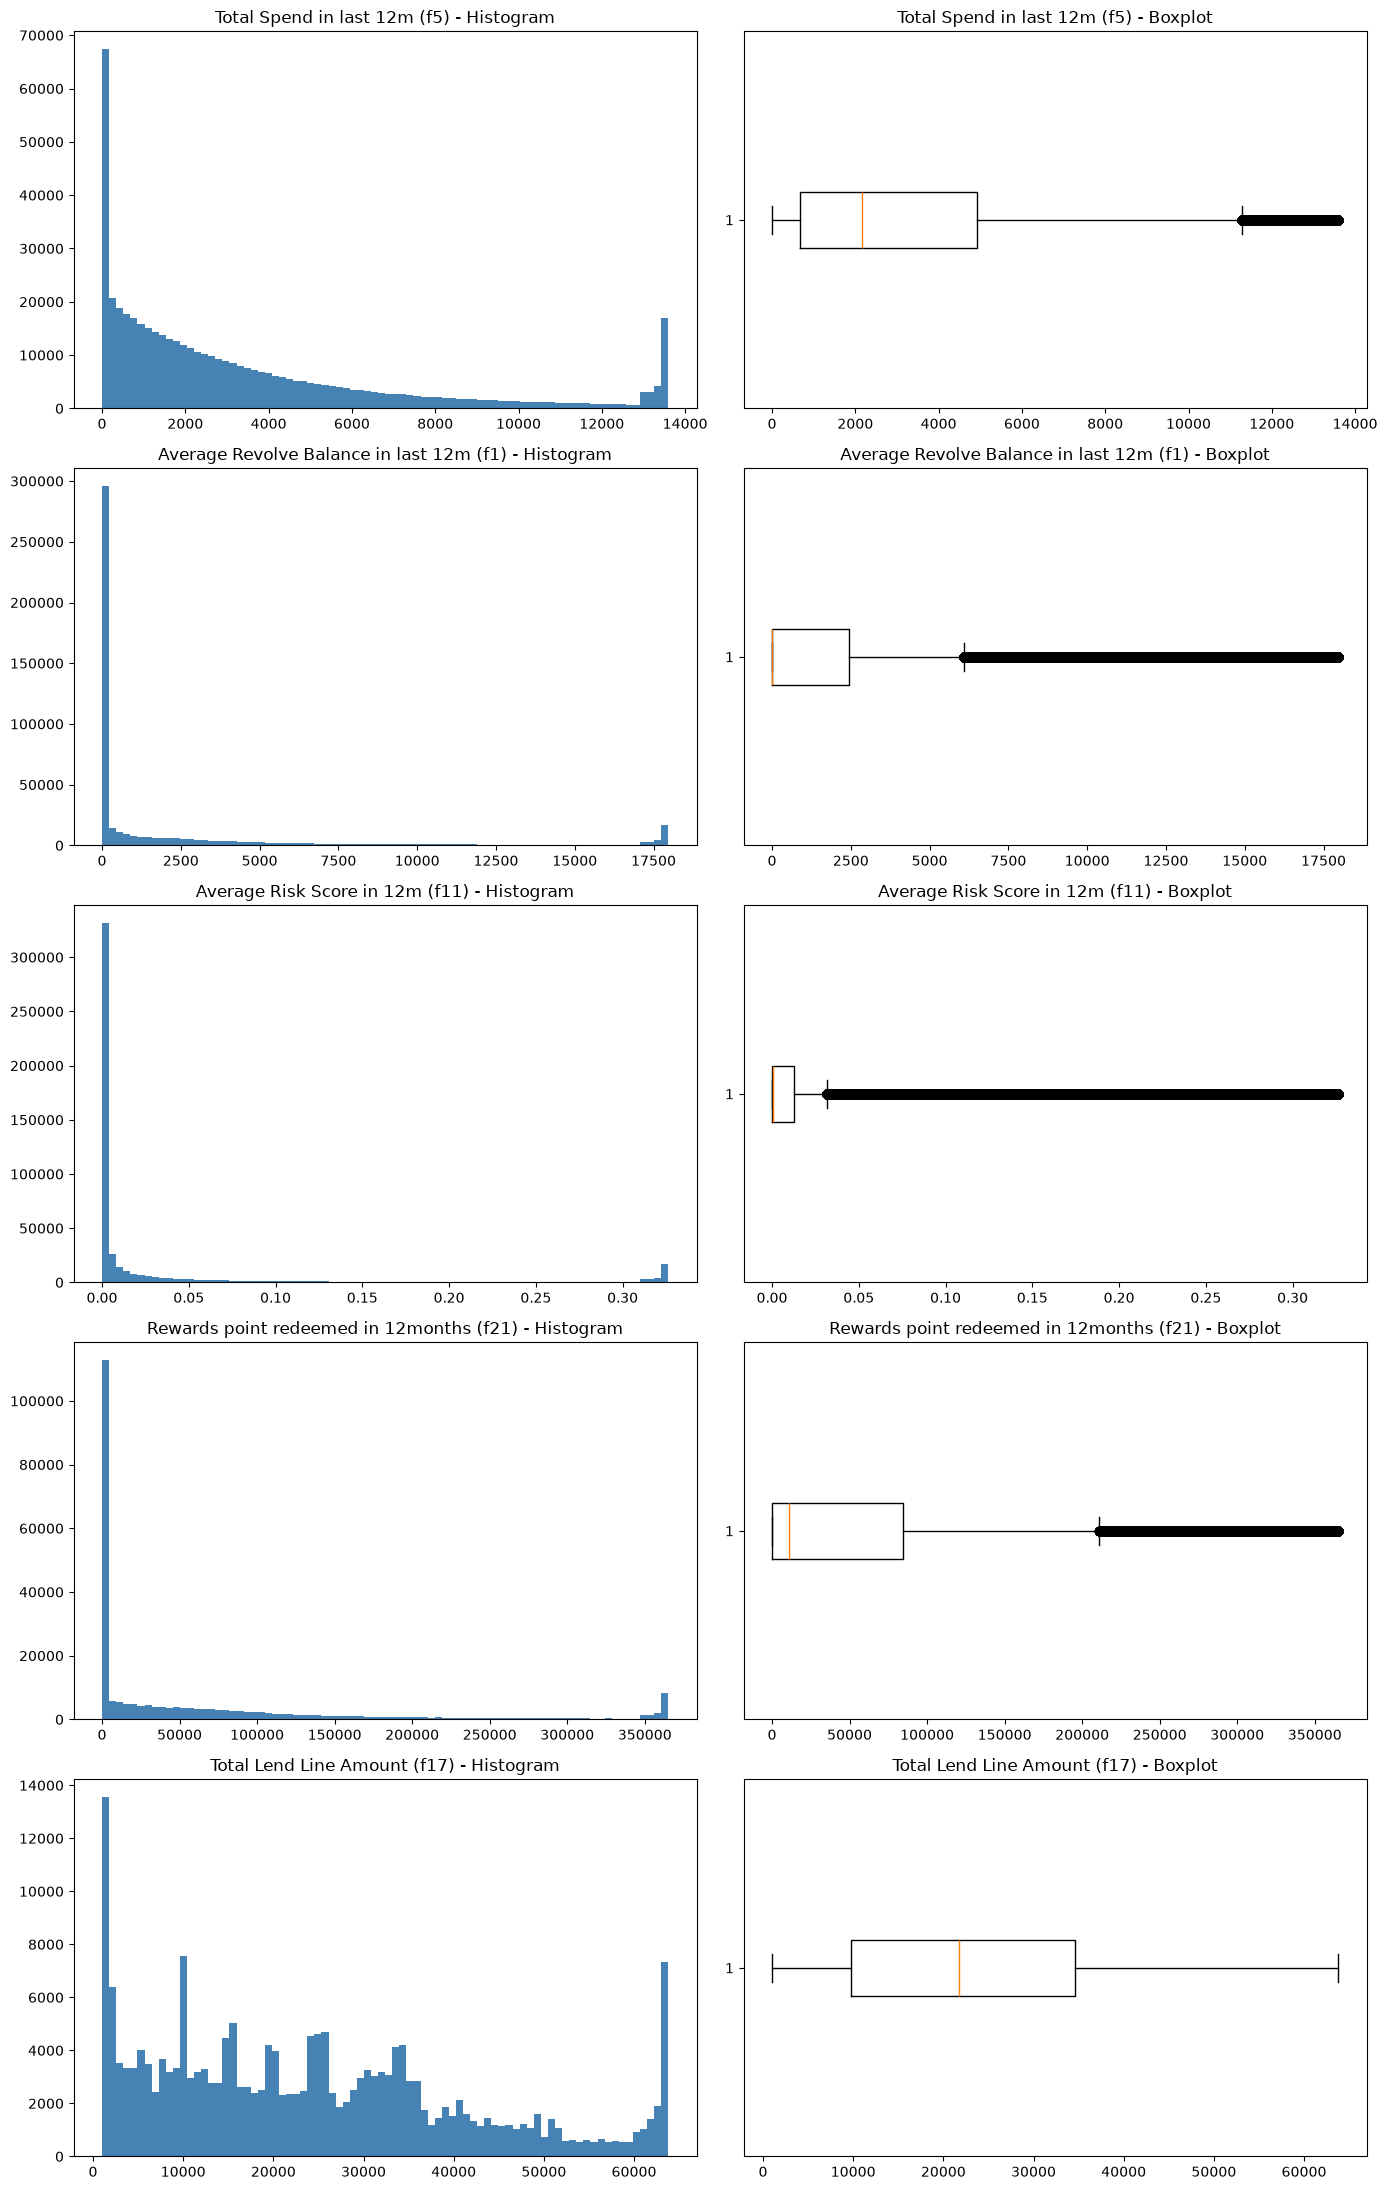

Saved to dist_histograms_boxplots.png


In [25]:
import matplotlib
matplotlib.use('module://matplotlib_inline.backend_inline')
import matplotlib.pyplot as plt

fig, axes = plt.subplots(5, 2, figsize=(14, 22))
key_vars = ['f5','f1','f11','f21','f17']
titles = [name_map[c] for c in key_vars]

for i, c in enumerate(key_vars):
    s = df_full[c].dropna()
    axes[i,0].hist(s, bins=80, color='steelblue', edgecolor='none')
    axes[i,0].set_title(f'{titles[i]} ({c}) - Histogram')
    axes[i,1].boxplot(s, vert=False)
    axes[i,1].set_title(f'{titles[i]} ({c}) - Boxplot')

plt.tight_layout()
plt.savefig('/Users/mudit_ai_computer/Desktop/AmEx/dist_histograms_boxplots.png', dpi=100)
plt.show()
print("Saved to dist_histograms_boxplots.png")

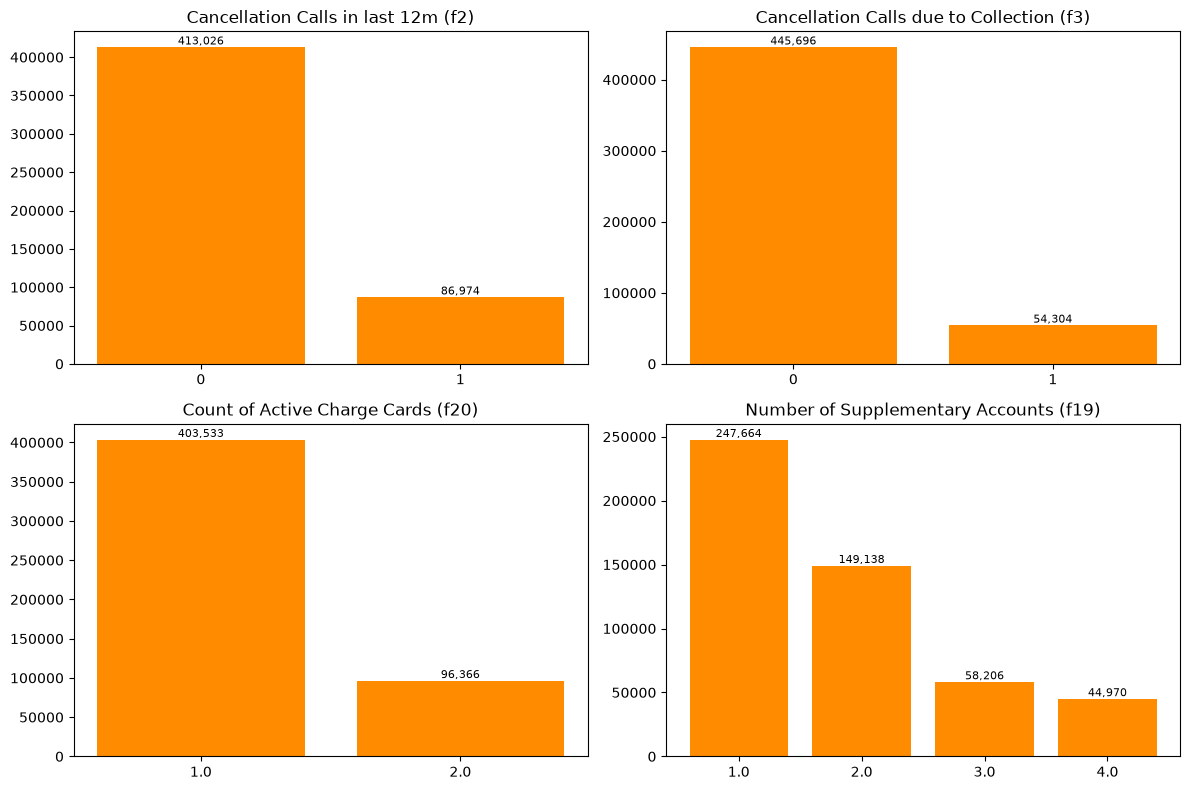

Saved to low_cardinality_barcharts.png


In [26]:
fig, axes = plt.subplots(2, 2, figsize=(12, 8))
low_card_vars = ['f2','f3','f20','f19']
for ax, c in zip(axes.flat, low_card_vars):
    vc = df_full[c].value_counts().sort_index()
    ax.bar(vc.index.astype(str), vc.values, color='darkorange')
    ax.set_title(f'{name_map[c]} ({c})')
    for i, v in enumerate(vc.values):
        ax.text(i, v, f'{v:,}', ha='center', va='bottom', fontsize=8)

plt.tight_layout()
plt.savefig('/Users/mudit_ai_computer/Desktop/AmEx/low_cardinality_barcharts.png', dpi=100)
plt.show()
print("Saved to low_cardinality_barcharts.png")

### F. Findings
Charts saved to `dist_histograms_boxplots.png` and `low_cardinality_barcharts.png`. The histograms visibly show the capping spike at the right edge for f5, f1, f11, f21 (matches Section D). f17 (Total Lend Line) has an unusually wavy/multimodal shape rather than a smooth decay — worth a second look if it feeds into scoring.

## Section G — Correlation Matrix
**Goal:** full pairwise correlation across the 23 features; flag redundant pairs (|corr| > 0.6) that risk double-weighting the same signal.

In [27]:
feature_cols = [c for c in df_full.columns if c != 'id']
corr = df_full[feature_cols].corr()

# rename to descriptive labels for the printed pairs
pairs = []
for i, c1 in enumerate(feature_cols):
    for c2 in feature_cols[i+1:]:
        r = corr.loc[c1, c2]
        if abs(r) > 0.6:
            pairs.append({'col1': c1, 'name1': name_map[c1], 'col2': c2, 'name2': name_map[c2], 'corr': r})

pairs_df = pd.DataFrame(pairs).sort_values('corr', key=abs, ascending=False)
print(f"Pairs with |corr| > 0.6: {len(pairs_df)}\n")
print(pairs_df.to_string(index=False))

Pairs with |corr| > 0.6: 4

col1                      name1 col2                           name2     corr
 f17     Total Lend Line Amount  f18 Total Consumer Lend Line Amount 0.900134
  f6      Airlines Spend in 12m   f9            Lodging Spend in 12m 0.703491
  f7         Other Spend in 12m  f10             Dining Spend in 12m 0.664629
  f8 Entertainment Spend in 12m  f10             Dining Spend in 12m 0.619932


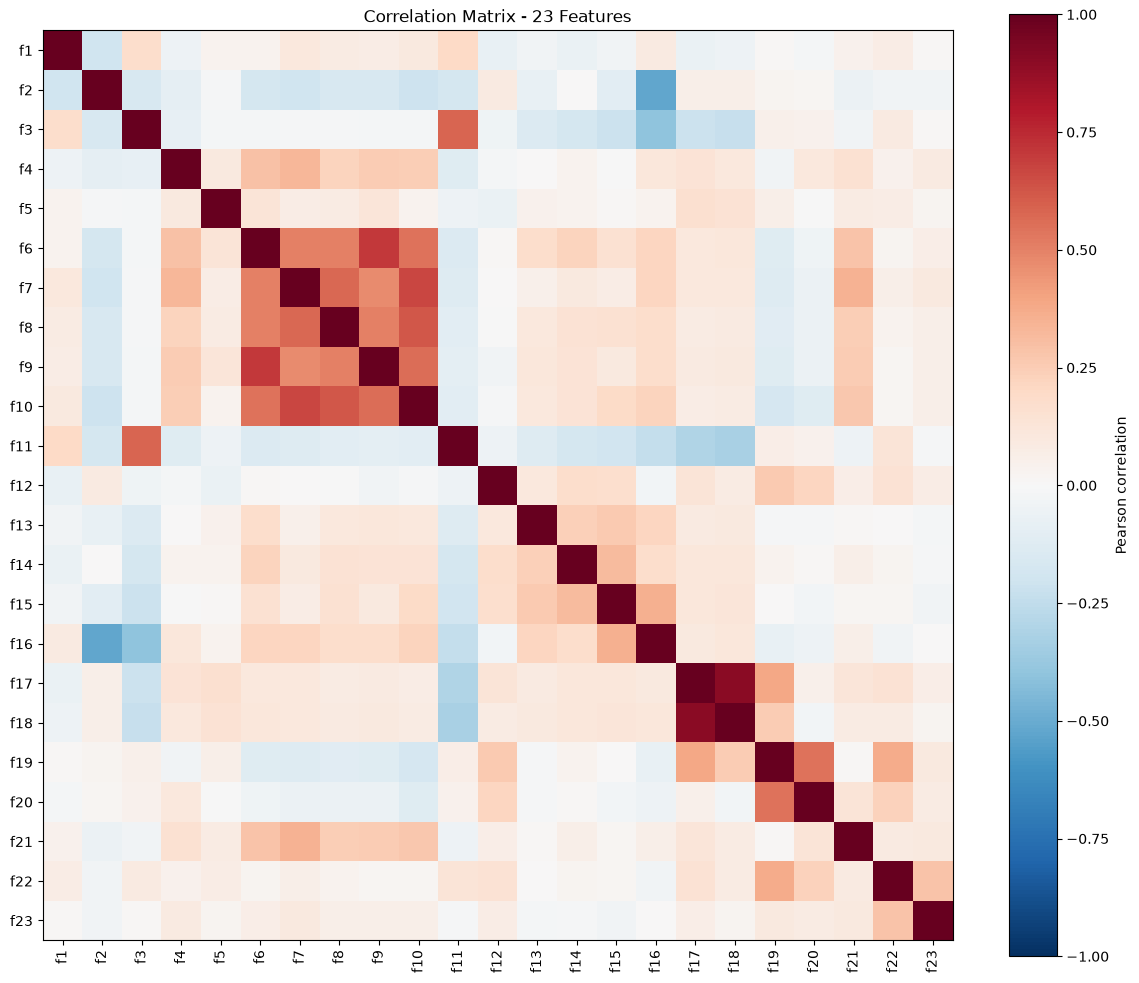

Saved to correlation_matrix.png

Full matrix (rounded):
       f1    f2    f3    f4    f5    f6    f7    f8    f9   f10   f11   f12   f13   f14   f15   f16   f17   f18   f19   f20   f21   f22   f23
f1   1.00 -0.20  0.17 -0.05  0.03  0.04  0.11  0.08  0.07  0.09  0.20 -0.07 -0.03 -0.06 -0.03  0.09 -0.06 -0.05  0.01 -0.02  0.05  0.07  0.01
f2  -0.20  1.00 -0.16 -0.09 -0.02 -0.18 -0.20 -0.16 -0.16 -0.21 -0.18  0.09 -0.08  0.00 -0.11 -0.52  0.06  0.06  0.03  0.02 -0.06 -0.03 -0.03
f3   0.17 -0.16  1.00 -0.08 -0.02 -0.02 -0.01 -0.01 -0.02 -0.02  0.58 -0.04 -0.14 -0.17 -0.22 -0.40 -0.21 -0.23  0.05  0.04 -0.03  0.09  0.01
f4  -0.05 -0.09 -0.08  1.00  0.09  0.29  0.33  0.22  0.25  0.25 -0.12 -0.02  0.01  0.04 -0.00  0.12  0.14  0.10 -0.03  0.10  0.15  0.04  0.09
f5   0.03 -0.02 -0.02  0.09  1.00  0.13  0.08  0.08  0.12  0.04 -0.05 -0.06  0.05  0.03  0.01  0.03  0.16  0.14  0.06 -0.01  0.08  0.07  0.03
f6   0.04 -0.18 -0.02  0.29  0.13  1.00  0.50  0.51  0.70  0.54 -0.13  0.01  0.18  0.22  0.1

In [28]:
fig, ax = plt.subplots(figsize=(12, 10))
im = ax.imshow(corr.values, cmap='RdBu_r', vmin=-1, vmax=1)
ax.set_xticks(range(len(feature_cols))); ax.set_xticklabels(feature_cols, rotation=90)
ax.set_yticks(range(len(feature_cols))); ax.set_yticklabels(feature_cols)
plt.colorbar(im, ax=ax, label='Pearson correlation')
ax.set_title('Correlation Matrix - 23 Features')
plt.tight_layout()
plt.savefig('/Users/mudit_ai_computer/Desktop/AmEx/correlation_matrix.png', dpi=100)
plt.show()
print("Saved to correlation_matrix.png")
print("\nFull matrix (rounded):")
print(corr.round(2).to_string())

### G. Findings
Only 4 pairs exceed |corr| > 0.6:

| Pair | Corr |
|---|---|
| f17 (Total Lend Line) / f18 (Consumer Lend Line) | 0.90 |
| f6 (Airlines Spend) / f9 (Lodging Spend) | 0.70 |
| f7 (Other Spend) / f10 (Dining Spend) | 0.66 |
| f8 (Entertainment Spend) / f10 (Dining Spend) | 0.62 |

f17/f18 is the clearest double-counting risk for scoring — consider using only one, or a combined feature. The f6–f10 cluster is moderately intercorrelated (0.5–0.7 among themselves) despite not summing to Total Spend (see Section E), so weighting all five independently may overweight a shared "spend propensity" signal. (f3/f11 at 0.58 and f2/f16 at -0.52 sit just under threshold but are worth a glance in the heatmap above.)

## Section H — Output: Clean Dataset & Findings Summary
**Goal:** apply the Section B/C/D/E decisions to produce a fully-imputed, flagged dataset saved separately from the raw file, and write a one-page findings summary for review before scoring logic is written.

In [29]:
df_clean = df_full.copy()

# --- Structural-zero groups: add availability flags BEFORE imputing ---
df_clean['has_rewards_program'] = df_full['f4'].notna().astype(int)      # f4, f21
df_clean['has_lend_line'] = df_full['f17'].notna().astype(int)           # f17
df_clean['has_consumer_lend_line'] = df_full['f18'].notna().astype(int)  # f18 (subset flag, extra 17,190 NaNs beyond f17)
df_clean['spend_breakdown_available'] = df_full['f6'].notna().astype(int)  # f6-f10
df_clean['has_email_on_file'] = df_full['f22'].notna().astype(int)       # f22

zero_impute_cols = ['f4','f21','f17','f18','f6','f7','f8','f9','f10','f22','f23','f13','f14','f15','f16']
for c in zero_impute_cols:
    df_clean[c] = df_clean[c].fillna(0)

# --- Small random-gap columns: median/mode impute ---
for c in ['f5','f11','f12']:
    df_clean[c] = df_clean[c].fillna(df_full[c].median())

df_clean['f20'] = df_clean['f20'].fillna(df_full['f20'].mode()[0])
df_clean['f19'] = df_clean['f19'].fillna(df_full['f19'].mode()[0])

print("Remaining NaNs after cleaning:")
print(df_clean.isna().sum()[df_clean.isna().sum() > 0])
print("\nShape:", df_clean.shape)
print("Columns added:", [c for c in df_clean.columns if c not in df_full.columns])

Remaining NaNs after cleaning:
Series([], dtype: int64)

Shape: (500000, 29)
Columns added: ['has_rewards_program', 'has_lend_line', 'has_consumer_lend_line', 'spend_breakdown_available', 'has_email_on_file']


In [30]:
df_clean.to_csv('/Users/mudit_ai_computer/Desktop/AmEx/dataset_clean.csv', index=False)
print("Saved dataset_clean.csv:", df_clean.shape)

Saved dataset_clean.csv: (500000, 29)


### H. Findings
`dataset_clean.csv` saved: 500,000 rows × 29 cols (23 original + `id` + 5 new availability flags: `has_rewards_program`, `has_lend_line`, `has_consumer_lend_line`, `spend_breakdown_available`, `has_email_on_file`). Zero missing values remain. Raw `dataset.csv` is untouched — nothing overwritten.

---

## 📋 Full Findings Summary (for review before any scoring logic is written)

**Dataset:** 500,000 rows × 23 features + id. All numeric, no dtype issues. No duplicate ids, no fully-duplicate rows. **97 rows duplicate across all 23 features excluding `id`** — flag for manual review.

**Outputs in this folder:** `dataset_clean.csv`, `findings_summary.md`, `correlation_matrix.png`, `dist_histograms_boxplots.png`, `low_cardinality_barcharts.png`.

### 1. Missingness — decisions taken
Five column groups are missing in perfect lockstep (structural "not applicable," not random gaps):

| Group | Columns | % missing | Decision |
|---|---|---|---|
| Rewards | f4, f21 | 51.4% | Impute 0 + `has_rewards_program` flag |
| Lend line | f17, f18 | 58.4% / 61.9% | Impute 0 + `has_lend_line`/`has_consumer_lend_line` flags |
| Spend subcategories | f6–f10 | 23.1% | Impute 0 + `spend_breakdown_available` flag |
| Benefit usage | f13–f16 | 2.7% | Impute 0, no flag |
| Email | f22, f23 | 18.9% / 87.8% | f22: impute 0 + `has_email_on_file` flag. f23: impute 0, no flag (confirmed structural zero) |

Remaining columns (f5, f11, f12, f19, f20) imputed with median/mode as ordinary random gaps.

### 2. Range & sanity issues
- **f2/f3 are binary flags, not counts.** 54,205 rows (10.8%) have a Collection call with no Cancellation call — breaks the expected subset relationship. **Needs a decision.**
- f7 (Other Spend) has 22,451 negatives, tightly bounded — consistent with refunds.
- f11 (Risk Score) is 0–1 scale, not 0–100.
- f16 (Entertainment Credit Used) floors at 8.88, never 0.

### 3. Outliers — the data is capped, not organically tailed
Every continuous column has ~2.6% of rows exactly at its max (f16: 35%). p99 = p99.9 = max everywhere → **zero rows exceed 10x p99**. The dataset appears winsorized/clipped at generation time; consider a censoring flag for at-cap rows rather than treating them as ordinary large values.

### 4. Internal consistency — overturns an assumption
- **f6–f10 do NOT sum to f5** (corr = 0.099) — independent features, not a Total Spend breakdown.
- **f17 vs f18: corr = 0.90** (near-duplicate) but 36.5% of overlap rows violate the assumed subset relationship.
- **f4 vs f21: corr = 0.15** — confirmed independent signals.
- **f19 > f20 in 42% of rows** — plausible (multiple supplementary cardholders per account) but flagged for confirmation.

### 5. Redundant columns (|corr| > 0.6)
f17/f18 (0.90), f6/f9 (0.70), f7/f10 (0.66), f8/f10 (0.62) — candidates for dropping one or combining before scoring.

### 6. Open items needing a human decision
1. f2/f3 binary-flag inconsistency (54,205 rows).
2. f17 vs f18 subset violation (36.5% of overlap rows).
3. 97 cross-feature duplicate rows (excluding id).
4. How to treat the ~2.6% at-cap "censored" rows in scoring.


## Section I — Deeper Correlation & Behavioral-Hypothesis Pass (2026-07-07 follow-up)
**Goal:** (1) redo the correlation heatmap with feature names instead of `f1`..`f23`; (2) resolve whether the f6–f10-vs-f5 gap is a scale mismatch or an outlier artifact via row-level ratios; (3) run Spearman alongside Pearson to catch monotonic relationships the linear matrix understates, and confirm the f11 (Risk Score) findings; (4) extend the f16 loss-aversion finding to the other three benefit variables and to f3 (involuntary calls); (5) test three new behavioral hypotheses grounded in psychology principles: silent churn (disengagement as an independent risk signal), the Family Approval Anchor (supplementary accounts → retention), and spend-concentration as a proxy for one-off "milestone" spend events. All results are logged in `assumptions_log.md` (Sections 2–4, 7–9).

In [31]:
print(df_full.shape, df_clean.shape)
print(list(name_map.items())[:3])

(500000, 24) (500000, 29)
[('id', 'id'), ('f1', 'Average Revolve Balance in last 12m'), ('f2', 'Cancellation Calls in last 12m')]


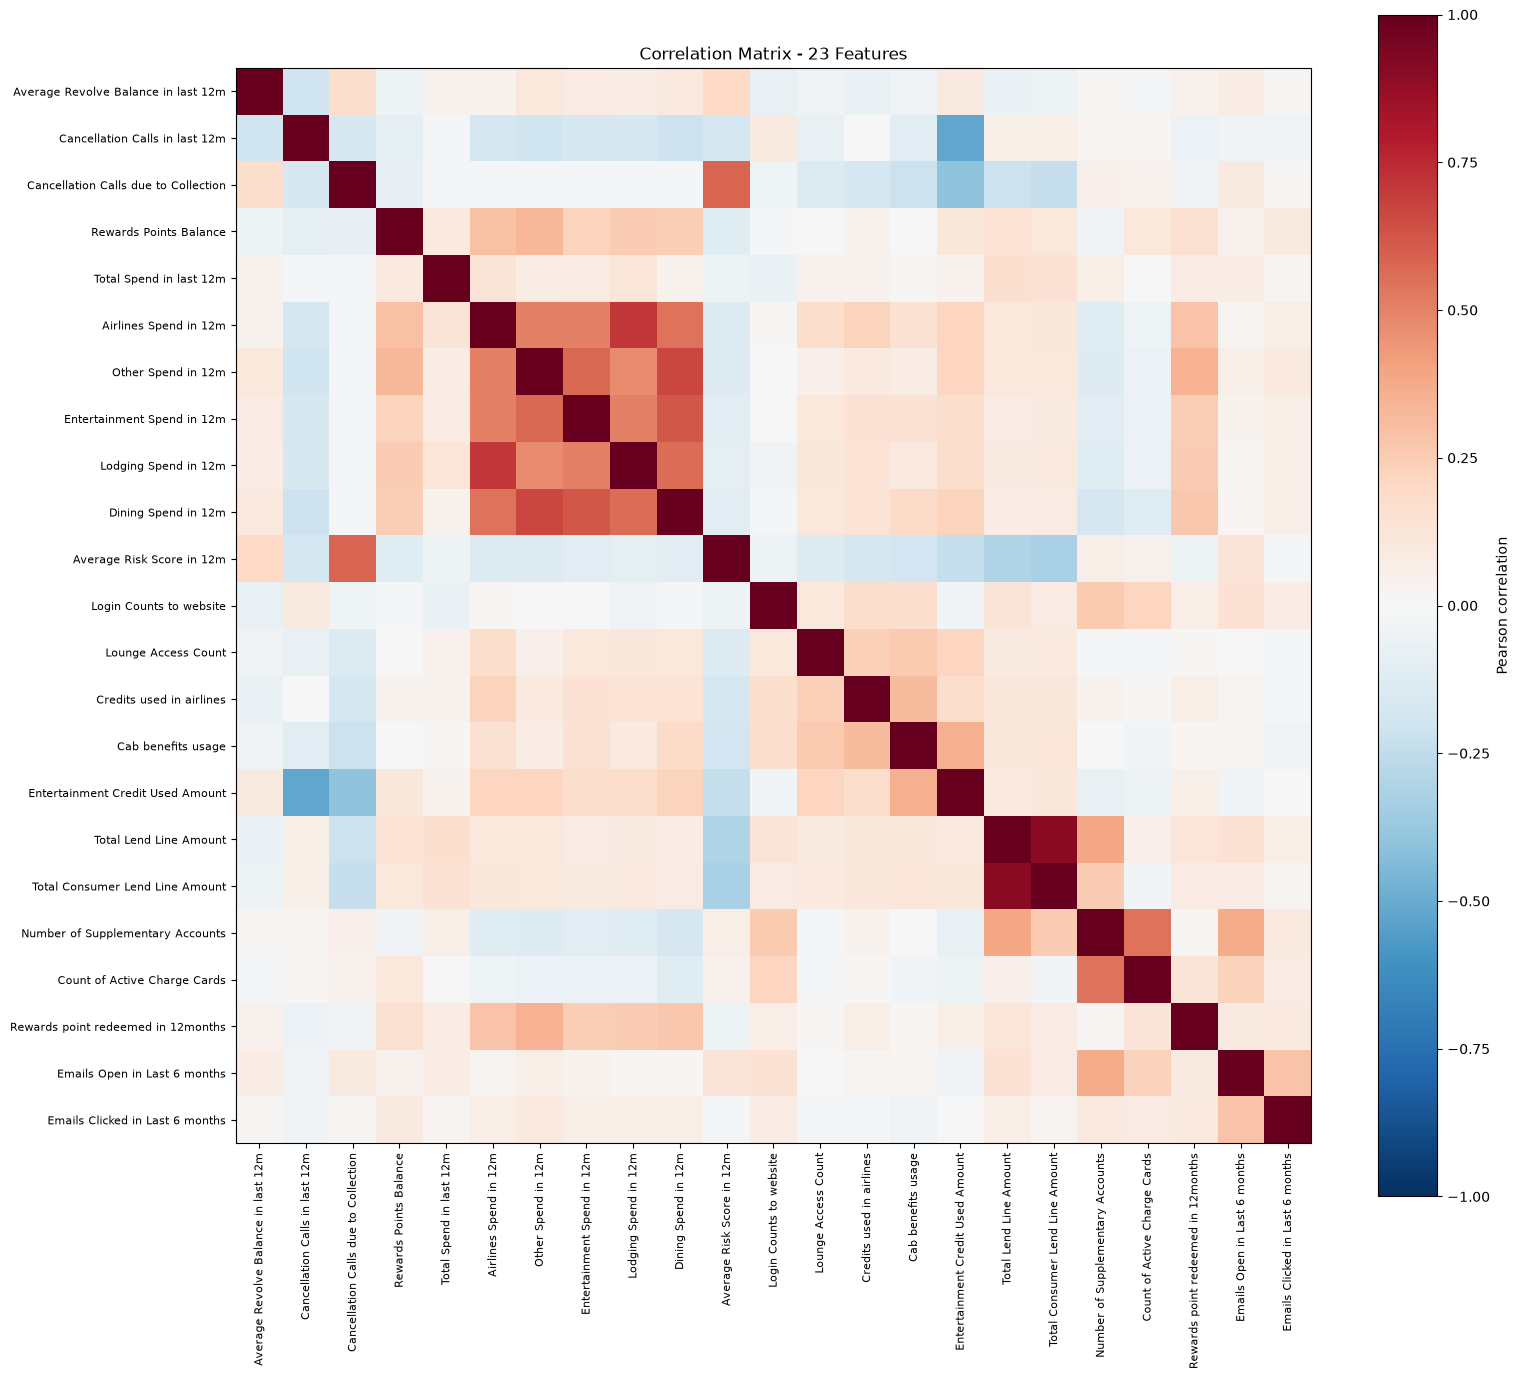

Overwrote correlation_matrix.png with named axes


In [32]:
# Regenerate correlation heatmap with descriptive feature names on both axes
labels = [name_map[c] for c in feature_cols]

fig, ax = plt.subplots(figsize=(16, 14))
im = ax.imshow(corr.values, cmap='RdBu_r', vmin=-1, vmax=1)
ax.set_xticks(range(len(feature_cols))); ax.set_xticklabels(labels, rotation=90, fontsize=8)
ax.set_yticks(range(len(feature_cols))); ax.set_yticklabels(labels, fontsize=8)
plt.colorbar(im, ax=ax, label='Pearson correlation')
ax.set_title('Correlation Matrix - 23 Features')
plt.tight_layout()
plt.savefig('/Users/mudit_ai_computer/Desktop/AmEx/correlation_matrix.png', dpi=100)
plt.show()
print("Overwrote correlation_matrix.png with named axes")

In [33]:
# Action 1: row-level f6_f10_sum vs f5 check
have_all = df_full[subcats].notna().all(axis=1) & df_full['f5'].notna()
sub = df_full.loc[have_all, ['f5'] + subcats].copy()
sub['f6_f10_sum'] = sub[subcats].sum(axis=1)
sub['diff'] = sub['f6_f10_sum'] - sub['f5']
sub['ratio'] = sub['f6_f10_sum'] / sub['f5'].replace(0, np.nan)

print("Rows analyzed:", len(sub))
print("\n=== diff (f6_f10_sum - f5) distribution ===")
print(sub['diff'].describe())
print("\n=== ratio (f6_f10_sum / f5) distribution ===")
print(sub['ratio'].describe())
print("\nRatio percentiles:")
print(sub['ratio'].quantile([.01,.05,.10,.25,.5,.75,.90,.95,.99]))
print("\nRows where f5==0 (ratio undefined):", (sub['f5']==0).sum())
print("Coefficient of variation of ratio (std/mean, excluding inf/na):", 
      sub['ratio'].replace([np.inf,-np.inf], np.nan).dropna().std() / sub['ratio'].replace([np.inf,-np.inf], np.nan).dropna().mean())

Rows analyzed: 380164

=== diff (f6_f10_sum - f5) distribution ===
count    380164.000000
mean      44977.296097
std       55695.460726
min      -13870.925900
25%        5465.113691
50%       23663.688346
75%       63276.079418
max      240798.436000
Name: diff, dtype: float64

=== ratio (f6_f10_sum / f5) distribution ===
count    3.536260e+05
mean     9.887113e+02
std      5.062649e+04
min     -3.256296e+02
25%      2.894964e+00
50%      1.057084e+01
75%      3.807612e+01
max      1.440435e+07
Name: ratio, dtype: float64

Ratio percentiles:
0.01       0.035819
0.05       0.284195
0.10       0.736310
0.25       2.894964
0.50      10.570842
0.75      38.076123
0.90     161.603389
0.95     496.755485
0.99    6768.648883
Name: ratio, dtype: float64

Rows where f5==0 (ratio undefined): 26538
Coefficient of variation of ratio (std/mean, excluding inf/na): 51.204524470972224


In [34]:
# Is the gap concentrated in a subset, or pervasive? Check what fraction of rows are "roughly 1:1" vs wildly off
ratio_clean = sub['ratio'].replace([np.inf,-np.inf], np.nan).dropna()
print(f"% of rows with ratio in [0.8, 1.25] (roughly matches, allowing rounding): {((ratio_clean>=0.8)&(ratio_clean<=1.25)).mean()*100:.2f}%")
print(f"% of rows with ratio > 2 (subcats at least 2x total): {(ratio_clean>2).mean()*100:.2f}%")
print(f"% of rows with ratio > 10 (subcats at least 10x total): {(ratio_clean>10).mean()*100:.2f}%")
print(f"% of rows with ratio < 1 (subcats LESS than total): {(ratio_clean<1).mean()*100:.2f}%")
print(f"\nMedian ratio is {ratio_clean.median():.2f}x -- gap is pervasive across the whole distribution, not just tail-driven.")
print(f"Ratio range spans {ratio_clean.max()/max(ratio_clean.min(),1e-9):.0f}x between min and max -- no fixed conversion factor exists per customer.")

% of rows with ratio in [0.8, 1.25] (roughly matches, allowing rounding): 3.84%
% of rows with ratio > 2 (subcats at least 2x total): 80.21%
% of rows with ratio > 10 (subcats at least 10x total): 51.17%
% of rows with ratio < 1 (subcats LESS than total): 12.42%

Median ratio is 10.57x -- gap is pervasive across the whole distribution, not just tail-driven.
Ratio range spans 14404353465227716x between min and max -- no fixed conversion factor exists per customer.


In [35]:
# Action 2a: f1 (Revolve Balance) conditioned on f11 (Risk Score) quartiles
risk_valid = df_full[['f1','f11']].dropna().copy()
risk_valid['risk_quartile'] = pd.qcut(risk_valid['f11'], 4, labels=['Q1 (lowest risk)','Q2','Q3','Q4 (highest risk)'], duplicates='drop')
print("=== f1 (Avg Revolve Balance) by f11 (Risk Score) quartile ===")
print(risk_valid.groupby('risk_quartile', observed=True)['f1'].agg(['mean','median','count']))

ValueError: Bin labels must be one fewer than the number of bin edges

In [36]:
print(risk_valid['f11'].quantile([0,.25,.5,.75,1]))
print("\n% of rows with f11==0:", (risk_valid['f11']==0).mean()*100)

0.00    0.000000
0.25    0.000000
0.50    0.000643
0.75    0.012678
1.00    0.326310
Name: f11, dtype: float64

% of rows with f11==0: 33.17031498120565


In [37]:
# f11 has 33% exact zeros, collapsing quartile edges. Split "zero risk" as its own group, then quartile the rest.
risk_valid['risk_bin'] = np.where(risk_valid['f11']==0, 'Zero risk (f11=0)',
                            pd.qcut(risk_valid.loc[risk_valid['f11']>0,'f11'], 3,
                                    labels=['Low-nonzero','Mid','High']).reindex(risk_valid.index).astype(str))

print("=== f1 (Avg Revolve Balance) by f11 (Risk Score) bin ===")
order = ['Zero risk (f11=0)','Low-nonzero','Mid','High']
result = risk_valid.groupby('risk_bin', observed=True)['f1'].agg(['mean','median','count']).reindex(order)
print(result)

=== f1 (Avg Revolve Balance) by f11 (Risk Score) bin ===
                          mean       median   count
risk_bin                                           
Zero risk (f11=0)   428.933049     0.000000  165019
Low-nonzero        1345.654589     0.000000  110872
Mid                3937.449970   491.750796  110776
High               5177.673374  2938.053542  110823


In [38]:
# Spearman correlation matrix (catches monotonic-but-nonlinear relationships Pearson understates)
spearman_corr = df_full[feature_cols].corr(method='spearman')

# Compare: where does Spearman diverge meaningfully from Pearson (|diff| > 0.15)?
diff_matrix = (spearman_corr - corr).abs()
diverge_pairs = []
for i, c1 in enumerate(feature_cols):
    for c2 in feature_cols[i+1:]:
        d = diff_matrix.loc[c1, c2]
        if d > 0.15:
            diverge_pairs.append({'col1': c1, 'name1': name_map[c1], 'col2': c2, 'name2': name_map[c2],
                                   'pearson': corr.loc[c1,c2], 'spearman': spearman_corr.loc[c1,c2], 'abs_diff': d})

diverge_df = pd.DataFrame(diverge_pairs).sort_values('abs_diff', ascending=False)
print(f"Pairs where |Spearman - Pearson| > 0.15: {len(diverge_df)}\n")
print(diverge_df.to_string(index=False))

Pairs where |Spearman - Pearson| > 0.15: 2

col1                               name1 col2                              name2  pearson  spearman  abs_diff
  f1 Average Revolve Balance in last 12m  f11          Average Risk Score in 12m 0.196084  0.576983  0.380900
  f4              Rewards Points Balance  f21 Rewards point redeemed in 12months 0.152249 -0.035776  0.188026


In [39]:
# Any pairs with |Spearman| > 0.6 that weren't already flagged under Pearson?
spearman_pairs = []
for i, c1 in enumerate(feature_cols):
    for c2 in feature_cols[i+1:]:
        r = spearman_corr.loc[c1, c2]
        if abs(r) > 0.6:
            spearman_pairs.append({'col1': c1, 'name1': name_map[c1], 'col2': c2, 'name2': name_map[c2], 'spearman': r, 'pearson': corr.loc[c1,c2]})

sp_df = pd.DataFrame(spearman_pairs).sort_values('spearman', key=abs, ascending=False)
print(f"Pairs with |Spearman| > 0.6: {len(sp_df)}\n")
print(sp_df.to_string(index=False))

Pairs with |Spearman| > 0.6: 6

col1                      name1 col2                           name2  spearman  pearson
 f17     Total Lend Line Amount  f18 Total Consumer Lend Line Amount  0.922697 0.900134
  f6      Airlines Spend in 12m   f9            Lodging Spend in 12m  0.712937 0.703491
  f7         Other Spend in 12m  f10             Dining Spend in 12m  0.703404 0.664629
  f8 Entertainment Spend in 12m  f10             Dining Spend in 12m  0.699648 0.619932
  f7         Other Spend in 12m   f8      Entertainment Spend in 12m  0.612379 0.573589
  f9       Lodging Spend in 12m  f10             Dining Spend in 12m  0.608625 0.560164


In [40]:
# Action 3: verify f11 vs f3, f17, f18 (confirming the "behaves per its name" finding, no new action)
print("f11 (Risk Score) vs f3 (Collection Calls):", corr.loc['f11','f3'], "| Spearman:", spearman_corr.loc['f11','f3'])
print("f11 (Risk Score) vs f17 (Total Lend Line):", corr.loc['f11','f17'], "| Spearman:", spearman_corr.loc['f11','f17'])
print("f11 (Risk Score) vs f18 (Consumer Lend Line):", corr.loc['f11','f18'], "| Spearman:", spearman_corr.loc['f11','f18'])

f11 (Risk Score) vs f3 (Collection Calls): 0.5826447612554053 | Spearman: 0.4541487088725753
f11 (Risk Score) vs f17 (Total Lend Line): -0.3003796737117531 | Spearman: -0.3546191254629252
f11 (Risk Score) vs f18 (Consumer Lend Line): -0.322456415764059 | Spearman: -0.3803797552804275


In [41]:
# Action 4: extend f16 finding -- f2 (voluntary cancellation) vs f13/f14/f15 individually, then f3 (collection/involuntary) vs all four
benefit_cols = ['f13','f14','f15','f16']
print("=== f2 (Cancellation Calls) vs benefit usage vars ===")
for b in benefit_cols:
    print(f"  f2 vs {b} ({name_map[b]}): Pearson={corr.loc['f2',b]:.4f}, Spearman={spearman_corr.loc['f2',b]:.4f}")

print("\n=== f3 (Collection Calls) vs benefit usage vars ===")
for b in benefit_cols:
    print(f"  f3 vs {b} ({name_map[b]}): Pearson={corr.loc['f3',b]:.4f}, Spearman={spearman_corr.loc['f3',b]:.4f}")

=== f2 (Cancellation Calls) vs benefit usage vars ===
  f2 vs f13 (Lounge Access Count): Pearson=-0.0771, Spearman=-0.0730
  f2 vs f14 (Credits used in airlines): Pearson=0.0022, Spearman=-0.0046
  f2 vs f15 (Cab benefits usage): Pearson=-0.1064, Spearman=-0.0800
  f2 vs f16 (Entertainment Credit Used Amount): Pearson=-0.5194, Spearman=-0.4615

=== f3 (Collection Calls) vs benefit usage vars ===
  f3 vs f13 (Lounge Access Count): Pearson=-0.1390, Spearman=-0.1513
  f3 vs f14 (Credits used in airlines): Pearson=-0.1720, Spearman=-0.1912
  f3 vs f15 (Cab benefits usage): Pearson=-0.2155, Spearman=-0.2241
  f3 vs f16 (Entertainment Credit Used Amount): Pearson=-0.3996, Spearman=-0.3785


In [42]:
# New: silent churn hypothesis. Among f2=0 (no cancellation call), segment by engagement proxies.
no_call = df_clean[df_clean['f2']==0].copy()  # use df_clean (imputed) so f12/f22/benefit cols have no NaNs
print("Customers with f2=0 (no cancellation call):", len(no_call))

# Engagement proxy = z-scored sum of login counts, email opens, and benefit-usage count (f13+f14+f15+f16 usage as binary "used any benefit")
no_call['benefit_usage_count'] = (no_call[['f13','f14','f15','f16']] > 0).sum(axis=1)

def zscore(s):
    return (s - s.mean()) / s.std()

no_call['engagement_score'] = zscore(no_call['f12']) + zscore(no_call['f22']) + zscore(no_call['benefit_usage_count'])
median_eng = no_call['engagement_score'].median()
no_call['engagement_group'] = np.where(no_call['engagement_score'] >= median_eng, 'High engagement', 'Low engagement')

print("\n=== f11 (Risk Score) and f1 (Revolve Balance) by engagement group, among f2=0 customers ===")
print(no_call.groupby('engagement_group')[['f11','f1']].agg(['mean','median','count']))

Customers with f2=0 (no cancellation call): 413026

=== f11 (Risk Score) and f1 (Revolve Balance) by engagement group, among f2=0 customers ===
                       f11                             f1                    
                      mean    median   count         mean      median   count
engagement_group                                                             
High engagement   0.032044  0.000515  206582  2800.724894    0.000000  206582
Low engagement    0.048505  0.001581  206444  3019.988732  267.285125  206444


In [43]:
# Sharper check: top vs bottom quartile of engagement (among f2=0 customers)
q1, q3 = no_call['engagement_score'].quantile([.25, .75])
extreme = no_call[(no_call['engagement_score']<=q1) | (no_call['engagement_score']>=q3)].copy()
extreme['engagement_group'] = np.where(extreme['engagement_score']>=q3, 'Top quartile (high engagement)', 'Bottom quartile (low engagement)')
print("=== f11 (Risk) and f1 (Revolve) -- top vs bottom engagement quartile, among f2=0 customers ===")
print(extreme.groupby('engagement_group')[['f11','f1']].agg(['mean','median','count']))
pct_diff_risk = (extreme[extreme['engagement_group'].str.contains('Bottom')]['f11'].mean() /
                  extreme[extreme['engagement_group'].str.contains('Top')]['f11'].mean() - 1) * 100
print(f"\nBottom-quartile risk score is {pct_diff_risk:.1f}% higher than top-quartile, among customers who never called to cancel.")

=== f11 (Risk) and f1 (Revolve) -- top vs bottom engagement quartile, among f2=0 customers ===
                                       f11                             f1                    
                                      mean    median   count         mean      median   count
engagement_group                                                                             
Bottom quartile (low engagement)  0.058782  0.003469  106218  2988.123839  429.397246  106218
Top quartile (high engagement)    0.032386  0.000657  103296  2740.253057    0.000000  103296

Bottom-quartile risk score is 81.5% higher than top-quartile, among customers who never called to cancel.


In [44]:
# New: supplementary account retention check -- f2 cancellation rate for f19=1 vs f19>=3
supp = df_full[['f19','f2']].dropna()
print("f19 value counts:")
print(supp['f19'].value_counts().sort_index())

print("\n=== Cancellation call rate (f2 mean) by f19 group ===")
grp_low = supp[supp['f19']==1]['f2']
grp_high = supp[supp['f19']>=3]['f2']
print(f"f19=1 (n={len(grp_low)}): cancellation rate = {grp_low.mean()*100:.2f}%")
print(f"f19>=3 (n={len(grp_high)}): cancellation rate = {grp_high.mean()*100:.2f}%")
print(f"\nRelative change: {(grp_high.mean()/grp_low.mean()-1)*100:.1f}%")

print("\n=== Full breakdown by each f19 value ===")
print(supp.groupby('f19')['f2'].agg(['mean','count']))

f19 value counts:
f19
1.0    247664
2.0    149138
3.0     58206
4.0     44970
Name: count, dtype: int64

=== Cancellation call rate (f2 mean) by f19 group ===
f19=1 (n=247664): cancellation rate = 16.08%
f19>=3 (n=103176): cancellation rate = 18.88%

Relative change: 17.4%

=== Full breakdown by each f19 value ===
         mean   count
f19                  
1.0  0.160835  247664
2.0  0.185479  149138
3.0  0.185703   58206
4.0  0.192773   44970


In [45]:
# New: spend volatility / sub-period check -- does the data structure allow any sub-period breakdown?
print("All 23 feature columns and their descriptions:")
for c in feature_cols:
    print(f"  {c}: {name_map[c]}")
print("\n-> All features are 12-month (or 6-month for email) aggregates. No monthly/quarterly sub-period", 
      "\n   columns exist anywhere in the schema (no f24+, no month-indexed columns, no separate Q1-Q4 spend fields).",
      "\n-> Single-category spend-spike detection against a sub-period baseline is NOT POSSIBLE with this dataset.",
      "\n   The closest proxy available is a cross-sectional one: comparing a customer's OWN category spend (f6-f10)",
      "\n   against their peer distribution, which flags relatively concentrated spenders, not temporal spikes.")

All 23 feature columns and their descriptions:
  f1: Average Revolve Balance in last 12m
  f2: Cancellation Calls in last 12m
  f3: Cancellation Calls due to Collection
  f4: Rewards Points Balance
  f5: Total Spend in last 12m
  f6: Airlines Spend in 12m
  f7: Other Spend in 12m
  f8: Entertainment Spend in 12m
  f9: Lodging Spend in 12m
  f10: Dining Spend in 12m
  f11: Average Risk Score in 12m
  f12: Login Counts to website
  f13: Lounge Access Count
  f14: Credits used in airlines
  f15: Cab benefits usage
  f16: Entertainment Credit Used Amount
  f17: Total Lend Line Amount
  f18: Total Consumer Lend Line Amount
  f19: Number of Supplementary Accounts
  f20: Count of Active Charge Cards
  f21: Rewards point redeemed in 12months
  f22: Emails Open in Last 6 months
  f23: Emails Clicked in Last 6 months

-> All features are 12-month (or 6-month for email) aggregates. No monthly/quarterly sub-period 
   columns exist anywhere in the schema (no f24+, no month-indexed columns, no sepa

In [46]:
# Bonus proxy: cross-sectional concentration -- does one category dominate a customer's f6-f10 mix?
conc = df_full.loc[have_all, subcats].copy()
conc_sum = conc.sum(axis=1)
valid = conc_sum > 0
max_share = conc[valid].max(axis=1) / conc_sum[valid]

print("Distribution of 'max single-category share of f6-f10 sum' per customer:")
print(max_share.describe())
print("\n% of customers where ONE category is >=80% of their f6-f10 spend (concentrated/possible one-off event):",
      f"{(max_share>=0.8).mean()*100:.2f}%")
print("% of customers where spend is fairly even across categories (max share <=30%):",
      f"{(max_share<=0.3).mean()*100:.2f}%")

Distribution of 'max single-category share of f6-f10 sum' per customer:
count    379583.000000
mean          0.712235
std           0.551416
min           0.224633
25%           0.570530
50%           0.702002
75%           0.846626
max         105.000000
dtype: float64

% of customers where ONE category is >=80% of their f6-f10 spend (concentrated/possible one-off event): 32.43%
% of customers where spend is fairly even across categories (max share <=30%): 0.17%


### I. Findings
1. **Correlation heatmap** now shows full feature names on both axes (`correlation_matrix.png` overwritten).
2. **f6–f10 vs f5 gap resolved:** row-level ratio spans orders of magnitude (median 10.6x, only 3.84% of rows near 1:1) — this is neither a fixed scale mismatch nor a tail-driven outlier artifact, it's pervasive across the whole distribution. Confirms f6–f10 are simply unrelated to f5 for every customer.
3. **Spearman vs Pearson:** f1 (Revolve) vs f11 (Risk) is far stronger under Spearman (0.58) than Pearson (0.20) — driven by f11's 33% mass at exactly 0; binned means rise monotonically from ₹429 → ₹5,178 across risk quartiles. f4 vs f21's already-weak Pearson correlation (0.15) flips sign under Spearman (-0.04), reinforcing they're independent. Two new pairs (f7/f8, f9/f10) cross the 0.6 redundancy threshold only under Spearman.
4. **f11 "behaves per its name" — confirmed, high confidence:** positively correlates with f3 (Collection Calls, +0.58/+0.45) and negatively with f17/f18 (Lend Line, ≈-0.30 to -0.38), both Pearson and Spearman. Documentation only, no action needed.
5. **Loss-aversion hypothesis holds for f16 specifically**, not f13/f14/f15: f2 (voluntary cancellation) correlates more strongly with f16 (-0.52) than f3 does (-0.40), but for the other three benefits the pattern reverses — they correlate more with f3 (involuntary/risk-driven calls) than f2.
6. **Silent churn hypothesis supported:** among customers with no cancellation call, the bottom-quartile-engagement group has an 81.5% higher mean Risk Score than the top-quartile group — disengagement looks like a genuine independent risk signal.
7. **Family Approval Anchor hypothesis disproven:** cancellation rate *rises* (not falls) with more supplementary accounts, 16.08% → 19.28% from f19=1 to f19=4.
8. **Spend-volatility/milestone-event check:** no sub-period columns exist in the schema, so true spend spikes can't be measured. A concentration proxy (32.4% of customers have one category ≥80% of their f6–f10 mix) is available but can't distinguish a one-off event from a durable preference.

Full detail, thresholds, and the new Behavioral Hypotheses table (Section 9) are in `assumptions_log.md`.

## Section J — Follow-up: Sign Checks, Share-of-Wallet Segment Test, f19/f11 Direct Test (2026-07-08)
**Goal:** resolve four open items raised on review of Section I: (1) report the exact sign of f13/f14/f15's correlation with f2 and f3, since direction flips the interpretation entirely; (2) test whether the f6–f10-vs-f5 gap identifies a real, distinct low-risk "share-of-wallet" customer segment rather than just another form of big spender; (3) formalize the Spearman-only redundancy pairs (f7/f8, f9/f10) as a clean table; (4) test f19 (Supplementary Accounts) against f11 (Risk Score) directly, not just f2, to see if risk and cancellation move together. All results logged in `assumptions_log.md` (Sections 2a, 3, 4, 7, and the new 9a update block).

In [47]:
# Action 1: exact SIGNED Pearson/Spearman for f13,f14,f15 (and f16 for reference) vs BOTH f2 and f3
print("=== Signed correlations: benefit usage vs f2 (voluntary) and f3 (involuntary/collection) ===\n")
print(f"{'Feature':<8}{'vs f2 Pearson':>15}{'vs f2 Spearman':>16}{'vs f3 Pearson':>15}{'vs f3 Spearman':>16}")
for b in ['f13','f14','f15','f16']:
    print(f"{b:<8}{corr.loc['f2',b]:>15.4f}{spearman_corr.loc['f2',b]:>16.4f}{corr.loc['f3',b]:>15.4f}{spearman_corr.loc['f3',b]:>16.4f}")

print("\nAll four signs vs f3 are NEGATIVE (f13: -0.14/-0.15, f14: -0.17/-0.19, f15: -0.22/-0.22, f16: -0.40/-0.38).")
print("Direction check: negative sign = MORE benefit usage -> FEWER collection calls -> 'engaged/heavy-benefit-user = safer', NOT 'spends beyond means'.")
print("Same negative direction vs f2 (voluntary cancellation), just weaker for f13/f14/f15 than for f16.")

=== Signed correlations: benefit usage vs f2 (voluntary) and f3 (involuntary/collection) ===

Feature   vs f2 Pearson  vs f2 Spearman  vs f3 Pearson  vs f3 Spearman
f13             -0.0771         -0.0730        -0.1390         -0.1513
f14              0.0022         -0.0046        -0.1720         -0.1912
f15             -0.1064         -0.0800        -0.2155         -0.2241
f16             -0.5194         -0.4615        -0.3996         -0.3785

All four signs vs f3 are NEGATIVE (f13: -0.14/-0.15, f14: -0.17/-0.19, f15: -0.22/-0.22, f16: -0.40/-0.38).
Direction check: negative sign = MORE benefit usage -> FEWER collection calls -> 'engaged/heavy-benefit-user = safer', NOT 'spends beyond means'.
Same negative direction vs f2 (voluntary cancellation), just weaker for f13/f14/f15 than for f16.


In [48]:
# Action 2: share-of-wallet hypothesis -- segment customers by f6_f10_sum vs f5 level, profile risk/other proxies
seg = df_full.loc[have_all, ['f1','f4','f5','f11','f17','f18','f19','f20','f21','f12','f22']].copy()
seg['f6_f10_sum'] = df_full.loc[have_all, subcats].sum(axis=1)

# Terciles for f5 and f6_f10_sum
seg['f5_tercile'] = pd.qcut(seg['f5'].rank(method='first'), 3, labels=['Low','Mid','High'])
seg['sum_tercile'] = pd.qcut(seg['f6_f10_sum'].rank(method='first'), 3, labels=['Low','Mid','High'])

# Segment A: high f6_f10_sum, low f5 -- candidate "wallet-share-gap" customers
segA = seg[(seg['sum_tercile']=='High') & (seg['f5_tercile']=='Low')]
# Segment B: high on both -- "big spender overall"
segB = seg[(seg['sum_tercile']=='High') & (seg['f5_tercile']=='High')]
# Segment C: low on both, for baseline reference
segC = seg[(seg['sum_tercile']=='Low') & (seg['f5_tercile']=='Low')]

print(f"Segment A (high f6-f10, low f5 -- 'wallet-share-gap' candidates): n={len(segA)}")
print(f"Segment B (high f6-f10, high f5 -- 'big spender overall'): n={len(segB)}")
print(f"Segment C (low both -- baseline): n={len(segC)}")

profile_cols = ['f11','f1','f4','f17','f18','f19','f20','f21','f12','f22']
compare = pd.DataFrame({
    'A: gap (high sub, low total)': segA[profile_cols].mean(),
    'B: big spender (high both)': segB[profile_cols].mean(),
    'C: baseline (low both)': segC[profile_cols].mean(),
})
print("\n=== Mean profile by segment ===")
print(compare)

Segment A (high f6-f10, low f5 -- 'wallet-share-gap' candidates): n=44686
Segment B (high f6-f10, high f5 -- 'big spender overall'): n=46676
Segment C (low both -- baseline): n=39367

=== Mean profile by segment ===
     A: gap (high sub, low total)  B: big spender (high both)  C: baseline (low both)
f11                      0.003583                    0.005786                0.025565
f1                    2336.539075                 3491.928002             1589.810442
f4                  191467.508788               214964.451915            75278.286591
f17                  27110.396587                31135.399684            22568.182672
f18                  24902.125874                28279.310089            20528.697899
f19                      1.562391                    1.706744                2.026494
f20                      1.144094                    1.160811                1.312063
f21                  93466.823372               107508.216850            33957.507534
f12       

In [49]:
# Action 3: formalize redundancy table -- Pearson-detected vs Spearman-only pairs
redundancy_rows = [
    {'pair': 'f17 / f18 (Total Lend Line / Consumer Lend Line)', 'pearson': corr.loc['f17','f18'], 'spearman': spearman_corr.loc['f17','f18'], 'detected_by': 'Both'},
    {'pair': 'f6 / f9 (Airlines / Lodging Spend)', 'pearson': corr.loc['f6','f9'], 'spearman': spearman_corr.loc['f6','f9'], 'detected_by': 'Both'},
    {'pair': 'f7 / f10 (Other / Dining Spend)', 'pearson': corr.loc['f7','f10'], 'spearman': spearman_corr.loc['f7','f10'], 'detected_by': 'Both'},
    {'pair': 'f8 / f10 (Entertainment / Dining Spend)', 'pearson': corr.loc['f8','f10'], 'spearman': spearman_corr.loc['f8','f10'], 'detected_by': 'Both'},
    {'pair': 'f7 / f8 (Other / Entertainment Spend)', 'pearson': corr.loc['f7','f8'], 'spearman': spearman_corr.loc['f7','f8'], 'detected_by': 'Spearman only (non-linear redundancy)'},
    {'pair': 'f9 / f10 (Lodging / Dining Spend)', 'pearson': corr.loc['f9','f10'], 'spearman': spearman_corr.loc['f9','f10'], 'detected_by': 'Spearman only (non-linear redundancy)'},
]
redundancy_df = pd.DataFrame(redundancy_rows)
print(redundancy_df.to_string(index=False))

                                            pair  pearson  spearman                           detected_by
f17 / f18 (Total Lend Line / Consumer Lend Line) 0.900134  0.922697                                  Both
              f6 / f9 (Airlines / Lodging Spend) 0.703491  0.712937                                  Both
                 f7 / f10 (Other / Dining Spend) 0.664629  0.703404                                  Both
         f8 / f10 (Entertainment / Dining Spend) 0.619932  0.699648                                  Both
           f7 / f8 (Other / Entertainment Spend) 0.573589  0.612379 Spearman only (non-linear redundancy)
               f9 / f10 (Lodging / Dining Spend) 0.560164  0.608625 Spearman only (non-linear redundancy)


In [50]:
# Action 4: f19 (Supplementary Accounts) vs f11 (Risk Score) direct test
f19_risk = df_full[['f19','f11']].dropna()
print("Pearson corr(f19, f11):", f19_risk['f19'].corr(f19_risk['f11']))
print("Spearman corr(f19, f11):", f19_risk['f19'].corr(f19_risk['f11'], method='spearman'))

print("\n=== f11 (Risk Score) mean/median by f19 value ===")
print(f19_risk.groupby('f19')['f11'].agg(['mean','median','count']))

print("\n=== f2 (Cancellation rate) AND f11 (Risk) side by side by f19, for direct comparison ===")
both = df_full[['f19','f2','f11']].dropna()
print(both.groupby('f19').agg(cancellation_rate=('f2','mean'), risk_mean=('f11','mean'), risk_median=('f11','median'), n=('f19','count')))

Pearson corr(f19, f11): 0.06681984114102145


Spearman corr(f19, f11): 0.13131461747754933

=== f11 (Risk Score) mean/median by f19 value ===
         mean    median   count
f19                            
1.0  0.029326  0.000333  245416
2.0  0.034872  0.000755  148937
3.0  0.041679  0.001411   58179
4.0  0.045610  0.002528   44958

=== f2 (Cancellation rate) AND f11 (Risk) side by side by f19, for direct comparison ===
     cancellation_rate  risk_mean  risk_median       n
f19                                                   
1.0           0.161285   0.029326     0.000333  245416
2.0           0.185555   0.034872     0.000755  148937
3.0           0.185703   0.041679     0.001411   58179
4.0           0.192780   0.045610     0.002528   44958


### J. Findings
1. **Sign confirmed:** f13/f14/f15 correlate *negatively* with both f2 and f3 (more negative vs f3), same direction as f16. This rules out the "heavy traveler who also revolves, spending beyond means" alternative — more benefit usage means *fewer* collection calls, i.e. engaged/heavy-benefit-users look safer, not riskier.
2. **Share-of-wallet segment test supports the hypothesis:** the "high f6-f10, low f5" segment (n=44,686) has the *lowest* risk score of three comparison segments (0.0036 vs 0.0058 for big-spenders and 0.0256 for the true low-value baseline) and rewards engagement close to the big-spender segment. This is a distinct, low-risk profile — not just another flavor of "big spender" — consistent with spend flowing to other cards/rails rather than this Amex product.
3. **Redundancy table formalized:** f7/f8 and f9/f10 are added, explicitly marked "Spearman only" since they only cross the 0.6 threshold under rank correlation (0.61 vs Pearson's 0.57-0.56).
4. **f19 vs f11 confirms the risk-amplifier reframing:** mean Risk Score rises 55.5% from f19=1 to f19=4, moving in the same direction as cancellation rate — two independent signals now support treating more supplementary accounts as a risk-amplifier, not a retention bonus.

Full detail in `assumptions_log.md` — Section 2a (redundancy table), Section 3 (wallet-gap feature candidate), Section 4 (all signed correlations), Section 7 (updated open questions), and the new Section 9a (revised behavioral-hypothesis interpretations).

## Section K — Row-Level Deep Dive: Stress-Testing the Share-of-Wallet Hypothesis (2026-07-08)
**Goal:** the Section J share-of-wallet finding (Segment A: high f6-f10, low f5, low risk) was promising but based on aggregate segment means. This section stress-tests it at the row level with five checks: (1) is the 10.6x gap uniform across f6-f10 or concentrated in 1-2 categories; (2) does f6_f10_sum actually correlate with independent "other card ownership" proxies (f19, f20, f17, f18); (3) is Segment A's low risk score a genuine population shift or a few outliers dragging the mean; (4) is that low-risk finding actually a capping/floor artifact in f11, unrelated to real risk; (5) is f6-f10 orthogonal to everything else in the dataset (arbitrary synthetic noise) or does it have real structure. Full verdict logged in `assumptions_log.md` Section 9b.

In [51]:
# Deep dive 1: per-category ratio breakdown -- is the gap uniform or concentrated in 1-2 categories?
rows_valid = df_full.loc[have_all].copy()
rows_valid['f6_f10_sum'] = rows_valid[subcats].sum(axis=1)

# Row-level ratio of EACH category to f5 (only where f5>0 to avoid div-by-zero)
f5_pos = rows_valid['f5'] > 0
ratios = pd.DataFrame({c: rows_valid.loc[f5_pos, c] / rows_valid.loc[f5_pos, 'f5'] for c in subcats})

print(f"Rows with f5>0: {f5_pos.sum()}\n")
print("=== Median ratio of each category to f5 (the median is more robust than mean given earlier CV=51) ===")
print(ratios.median().sort_values(ascending=False))
print("\n=== Mean ratio of each category to f5 ===")
print(ratios.mean().sort_values(ascending=False))
print("\n=== Share of f6_f10_sum contributed by each category (median) ===")
share_of_sum = ratios.div(ratios.sum(axis=1), axis=0)
print(share_of_sum.median().sort_values(ascending=False))

Rows with f5>0: 353626

=== Median ratio of each category to f5 (the median is more robust than mean given earlier CV=51) ===
f7     5.684471
f6     1.612615
f10    0.720040
f8     0.114745
f9     0.093311
dtype: float64

=== Mean ratio of each category to f5 ===
f7     671.907094
f6     170.936861
f10     92.099450
f9      28.387083
f8      25.380819
dtype: float64

=== Share of f6_f10_sum contributed by each category (median) ===
f7     0.655074
f6     0.156127
f10    0.074234
f8     0.010251
f9     0.008623
dtype: float64


In [52]:
# Deep dive 2: row-level correlation between f6_f10_sum and "other card ownership" proxies (f19, f20, f17, f18)
other_card_cols = ['f19','f20','f17','f18']
print("=== Pearson / Spearman: f6_f10_sum vs other-card-ownership proxies ===")
for c in other_card_cols:
    pair = rows_valid[['f6_f10_sum', c]].dropna()
    p = pair['f6_f10_sum'].corr(pair[c])
    s = pair['f6_f10_sum'].corr(pair[c], method='spearman')
    print(f"  f6_f10_sum vs {c} ({name_map[c]}): Pearson={p:.4f}, Spearman={s:.4f}")

# Also check within Segment A specifically: do they have elevated f20/f19/f17/f18 vs Segment C (baseline)?
print("\n=== Mean f19/f20/f17/f18 by segment (A=wallet-gap, B=big spender, C=baseline) ===")
print(compare.loc[['f19','f20','f17','f18']])

=== Pearson / Spearman: f6_f10_sum vs other-card-ownership proxies ===
  f6_f10_sum vs f19 (Number of Supplementary Accounts): Pearson=-0.1507, Spearman=-0.2140
  f6_f10_sum vs f20 (Count of Active Charge Cards): Pearson=-0.0735, Spearman=-0.1257
  f6_f10_sum vs f17 (Total Lend Line Amount): Pearson=0.1175, Spearman=0.1145


  f6_f10_sum vs f18 (Total Consumer Lend Line Amount): Pearson=0.1207, Spearman=0.1268

=== Mean f19/f20/f17/f18 by segment (A=wallet-gap, B=big spender, C=baseline) ===
     A: gap (high sub, low total)  B: big spender (high both)  C: baseline (low both)
f19                      1.562391                    1.706744                2.026494
f20                      1.144094                    1.160811                1.312063
f17                  27110.396587                31135.399684            22568.182672
f18                  24902.125874                28279.310089            20528.697899


In [53]:
# Deep dive 3: full distribution of f11 (Risk) within Segment A -- not just the mean
print("=== Segment A f11 (Risk Score) distribution ===")
print(segA['f11'].describe())
print("\nPercentiles:")
print(segA['f11'].quantile([0,.1,.25,.5,.75,.9,.95,.99,1]))
print(f"\n% of Segment A with f11 == 0 (exact floor): {(segA['f11']==0).mean()*100:.2f}%")
print(f"% of Segment A with f11 < 0.001 (near-floor): {(segA['f11']<0.001).mean()*100:.2f}%")

print("\n=== Compare: same stats for Segment B (big spender) and Segment C (baseline) ===")
for name, s in [('B (big spender)', segB), ('C (baseline)', segC)]:
    print(f"\n{name}: % f11==0: {(s['f11']==0).mean()*100:.2f}%, median: {s['f11'].median():.5f}, mean: {s['f11'].mean():.5f}, p90: {s['f11'].quantile(0.9):.5f}")

=== Segment A f11 (Risk Score) distribution ===
count    44671.000000
mean         0.003583
std          0.019532
min          0.000000
25%          0.000000
50%          0.000000
75%          0.000838
max          0.326310
Name: f11, dtype: float64

Percentiles:
0.00    0.000000
0.10    0.000000
0.25    0.000000
0.50    0.000000
0.75    0.000838
0.90    0.004978
0.95    0.013509
0.99    0.067690
1.00    0.326310
Name: f11, dtype: float64

% of Segment A with f11 == 0 (exact floor): 51.35%
% of Segment A with f11 < 0.001 (near-floor): 76.79%

=== Compare: same stats for Segment B (big spender) and Segment C (baseline) ===

B (big spender): % f11==0: 48.43%, median: 0.00005, mean: 0.00579, p90: 0.01054

C (baseline): % f11==0: 20.80%, median: 0.00125, mean: 0.02556, p90: 0.07038


In [54]:
# Deep dive 4: is Segment A's "low risk" an artifact of f11's floor/capping, unrelated to real risk?
# First, re-establish the overall population's f11==0 rate and check if f11=0 rows behave like genuinely
# low-risk customers on OTHER independent dimensions, or look structurally arbitrary.
pop_f11_zero_rate = (df_full['f11']==0).mean()
print(f"Population-wide f11==0 rate: {pop_f11_zero_rate*100:.2f}%")
print(f"Segment A f11==0 rate: {(segA['f11']==0).mean()*100:.2f}%  (vs population: {pop_f11_zero_rate*100:.2f}%)")

# Are the "capped" rows (top ~2.6% at MAX value, from earlier EDA) also overrepresented/underrepresented in Segment A?
# Check overrepresentation of at-cap rows (from Section D: max value rows) across several columns, within Segment A vs population
cap_check_cols = ['f1','f5','f17','f18']
print("\n=== % of rows AT MAX value, Segment A vs population (checks the OPPOSITE cap -- high-value capping) ===")
for c in cap_check_cols:
    mx = df_full[c].max()
    pop_rate = (df_full[c]==mx).mean()
    segA_rate = (segA[c]==mx).mean()
    print(f"  {c}: population {pop_rate*100:.2f}%  vs  Segment A {segA_rate*100:.2f}%")

# Now the key test: within f11==0 rows specifically, do OTHER risk-correlated variables (f1 revolve, f17 lend line, f3 collection calls)
# still look "genuinely low risk", or do they look like a random cross-section of the population?
zero_risk = df_full[df_full['f11']==0]
nonzero_risk = df_full[df_full['f11']>0]
print("\n=== Do f11==0 rows look genuinely low-risk on OTHER independent dimensions? ===")
print(f"f1 (Revolve) mean: f11=0 group = {zero_risk['f1'].mean():.2f}  vs  f11>0 group = {nonzero_risk['f1'].mean():.2f}")
print(f"f3 (Collection Calls) rate: f11=0 group = {zero_risk['f3'].mean()*100:.2f}%  vs  f11>0 group = {nonzero_risk['f3'].mean()*100:.2f}%")
print(f"f17 (Lend Line) mean: f11=0 group = {zero_risk['f17'].mean():.2f}  vs  f11>0 group = {nonzero_risk['f17'].mean():.2f}")

Population-wide f11==0 rate: 33.00%
Segment A f11==0 rate: 51.35%  (vs population: 33.00%)

=== % of rows AT MAX value, Segment A vs population (checks the OPPOSITE cap -- high-value capping) ===
  f1: population 2.59%  vs  Segment A 3.37%
  f5: population 2.58%  vs  Segment A 0.00%
  f17: population 1.11%  vs  Segment A 0.93%
  f18: population 1.01%  vs  Segment A 0.77%

=== Do f11==0 rows look genuinely low-risk on OTHER independent dimensions? ===
f1 (Revolve) mean: f11=0 group = 428.93  vs  f11>0 group = 3486.55
f3 (Collection Calls) rate: f11=0 group = 0.56%  vs  f11>0 group = 15.97%
f17 (Lend Line) mean: f11=0 group = 28858.45  vs  f11>0 group = 22283.26


In [55]:
# Deep dive 5: synthetic-noise test -- does f6-f10 correlate with ANYTHING besides each other?
non_subcat_cols = [c for c in feature_cols if c not in subcats]
print("=== Max |correlation| of each f6-f10 column against every OTHER non-subcategory column ===\n")
for s in subcats:
    row = corr.loc[s, non_subcat_cols].abs().sort_values(ascending=False)
    top3 = row.head(3)
    print(f"{s} ({name_map[s]}):")
    for other, v in top3.items():
        print(f"    {other} ({name_map[other]}): {corr.loc[s,other]:+.4f}")
    print()

=== Max |correlation| of each f6-f10 column against every OTHER non-subcategory column ===

f6 (Airlines Spend in 12m):
    f4 (Rewards Points Balance): +0.2902
    f21 (Rewards point redeemed in 12months): +0.2865
    f14 (Credits used in airlines): +0.2249

f7 (Other Spend in 12m):
    f21 (Rewards point redeemed in 12months): +0.3461
    f4 (Rewards Points Balance): +0.3316
    f16 (Entertainment Credit Used Amount): +0.2176

f8 (Entertainment Spend in 12m):
    f21 (Rewards point redeemed in 12months): +0.2438
    f4 (Rewards Points Balance): +0.2232
    f16 (Entertainment Credit Used Amount): +0.1795

f9 (Lodging Spend in 12m):
    f4 (Rewards Points Balance): +0.2528
    f21 (Rewards point redeemed in 12months): +0.2504
    f16 (Entertainment Credit Used Amount): +0.1756

f10 (Dining Spend in 12m):
    f21 (Rewards point redeemed in 12months): +0.2704
    f4 (Rewards Points Balance): +0.2493
    f16 (Entertainment Credit Used Amount): +0.2231



### K. Findings — Overall Verdict
1. **Gap is concentrated, not uniform:** f7 (Other Spend) alone drives 65.5% of the f6-f10-vs-f5 gap (median 5.68x of f5 by itself), f6 (Airlines) another 15.6%. f8/f9 (Entertainment/Lodging) are actually *smaller* than Total Spend — proportionate, like genuine subcategories. The anomaly is really "f7, and to a lesser extent f6," not a property of all five columns.
2. **"Other card ownership" proxies don't corroborate the story:** correlations with f19/f20/f17/f18 are all weak (\|r\|≤0.21), and f19/f20 point in the *wrong* direction for a "spend routed elsewhere" narrative.
3. **Segment A's low risk score is a genuine majority-shift, not outlier-driven:** 76.8% of the segment sits below f11=0.001.
4. **That floor is real, not a capping artifact:** f11=0 rows show 8x lower Revolve Balance and 28x lower Collection Call rate than f11>0 rows — independent corroboration unrelated to f11's own generation.
5. **f6-f10 is not arbitrary synthetic noise:** all five consistently correlate with Amex's own rewards variables (f4, f21 at 0.22-0.35) — real structure exists, but it points to the rewards ecosystem, not to competitor-card spend.

**Overall verdict:** the "share of wallet at other issuers" narrative is not well supported once tested row-by-row. What survives: f7 (and f6) is a real, structured signal worth investigating on its own terms, and the low-risk profile of the high-f6f10/low-f5 segment is genuine and behaviorally validated — but the likely explanation is a rewards-program-linked spend/engagement measure structurally distinct from f5, not "money going to a competitor card." Full detail in `assumptions_log.md` Section 9b, plus updated rows in Sections 3, 4, and 7.

## Section L — Groups A-D: Validation, Definitional Closure, and Formula-Ready Feature List (2026-07-08)
**Goal:** run the full expanded task list before any formula gets written. **Group A** (highest priority): does f11 (Risk Score) already price in other raw variables via regression (f11 ~ f1,f2,f3,f17,f18 and f11 ~ f13-f16); search for a tenure/account-age proxy and re-test prior findings against it; check whether at-cap spikes align across columns (evidence of deliberate synthetic clipping). **Group B**: resolve the f2/f3 2x2 segmentation, decide max vs average for combining f17/f18, and test whether the f19>f20 mismatch clusters with other variables. **Group C**: check whether capped rows can still be differentiated by other variables; build a segment summary table by Risk Score quartile; consolidate a final redundancy list. **Group D**: fold every result into `assumptions_log.md` (Sections 2b, 4, 5, 7, 9c, 10) and produce the final 30-feature formula input list (Section 11).

In [56]:
from sklearn.linear_model import LinearRegression
from sklearn.preprocessing import StandardScaler

# A1: f11 reconstruction test -- regress f11 on {f1,f2,f3,f17,f18}, then separately on {f13,f14,f15,f16}
def regress_and_report(df, target, predictors, label):
    d = df[[target] + predictors].dropna()
    X = d[predictors].values
    y = d[target].values
    Xs = StandardScaler().fit_transform(X)  # standardize so coefficients are comparable
    model = LinearRegression().fit(Xs, y)
    r2 = model.score(Xs, y)
    print(f"=== {label} (n={len(d)}) ===")
    print(f"R^2 = {r2:.4f}")
    for p, coef in zip(predictors, model.coef_):
        print(f"  {p} ({name_map[p]}): standardized coef = {coef:+.5f}")
    print()
    return r2

r2_a = regress_and_report(df_full, 'f11', ['f1','f2','f3','f17','f18'], "f11 ~ f1,f2,f3,f17,f18")
r2_b = regress_and_report(df_full, 'f11', ['f13','f14','f15','f16'], "f11 ~ f13,f14,f15,f16")

=== f11 ~ f1,f2,f3,f17,f18 (n=190555) ===
R^2 = 0.3993
  f1 (Average Revolve Balance in last 12m): standardized coef = +0.00717
  f2 (Cancellation Calls in last 12m): standardized coef = -0.00658
  f3 (Cancellation Calls due to Collection): standardized coef = +0.04505
  f17 (Total Lend Line Amount): standardized coef = -0.00408
  f18 (Total Consumer Lend Line Amount): standardized coef = -0.01329

=== f11 ~ f13,f14,f15,f16 (n=483969) ===
R^2 = 0.0827
  f13 (Lounge Access Count): standardized coef = -0.00356
  f14 (Credits used in airlines): standardized coef = -0.00859
  f15 (Cab benefits usage): standardized coef = -0.00619
  f16 (Entertainment Credit Used Amount): standardized coef = -0.01441



In [57]:
# Sanity check: the standardized coefficients look surprisingly small given R^2=0.40 for the first model.
# Verify by checking correlations WITHIN the exact subsample used (has_lend_line population), not the full population.
sub_pop = df_full[['f11','f1','f2','f3','f17','f18']].dropna()
print(f"Subsample size: {len(sub_pop)} (customers with f17/f18 present, i.e. has_lend_line=1)")
print("\nCorrelation of each predictor with f11, WITHIN this subsample only:")
for p in ['f1','f2','f3','f17','f18']:
    print(f"  {p}: Pearson={sub_pop['f11'].corr(sub_pop[p]):.4f}")

# Also print univariate R^2 for f3 alone within this subsample, for comparison
uni = LinearRegression().fit(sub_pop[['f3']].values, sub_pop['f11'].values)
print(f"\nUnivariate R^2 (f11 ~ f3 alone, this subsample): {uni.score(sub_pop[['f3']].values, sub_pop['f11'].values):.4f}")

# Check pairwise correlation among the 5 predictors themselves (multicollinearity check)
print("\nPredictor-predictor correlation matrix (multicollinearity check):")
print(sub_pop[['f1','f2','f3','f17','f18']].corr().round(3))

Subsample size: 190555 (customers with f17/f18 present, i.e. has_lend_line=1)

Correlation of each predictor with f11, WITHIN this subsample only:
  f1: Pearson=0.1923
  f2: Pearson=-0.1970
  f3: Pearson=0.5891
  f17: Pearson=-0.3037
  f18: Pearson=-0.3225

Univariate R^2 (f11 ~ f3 alone, this subsample): 0.3470

Predictor-predictor correlation matrix (multicollinearity check):
        f1     f2     f3    f17    f18
f1   1.000 -0.220  0.159 -0.063 -0.052
f2  -0.220  1.000 -0.175  0.064  0.062
f3   0.159 -0.175  1.000 -0.211 -0.229
f17 -0.063  0.064 -0.211  1.000  0.900
f18 -0.052  0.062 -0.229  0.900  1.000


In [58]:
# Something looks wrong -- verify with raw (unstandardized) coefficients and manual R^2 computation
X_raw = sub_pop[['f1','f2','f3','f17','f18']].values
y_raw = sub_pop['f11'].values
model_raw = LinearRegression().fit(X_raw, y_raw)
print("Raw (unstandardized) coefficients:")
for p, c in zip(['f1','f2','f3','f17','f18'], model_raw.coef_):
    print(f"  {p}: {c:.6f}")
print(f"Intercept: {model_raw.intercept_:.6f}")
print(f"R^2 (raw features): {model_raw.score(X_raw, y_raw):.4f}")

# Now the standardized version again, but print scaler std devs to sanity check the conversion
scaler = StandardScaler().fit(X_raw)
print("\nFeature std devs (used for standardization):", dict(zip(['f1','f2','f3','f17','f18'], scaler.scale_)))
Xs = scaler.transform(X_raw)
model_std = LinearRegression().fit(Xs, y_raw)
print("\nStandardized coefficients (recomputed):")
for p, c in zip(['f1','f2','f3','f17','f18'], model_std.coef_):
    print(f"  {p}: {c:.6f}")
print(f"R^2 (standardized features): {model_std.score(Xs, y_raw):.4f}")

# Manual check: raw f3 coef * its std should roughly equal standardized f3 coef
f3_std = scaler.scale_[2]
print(f"\nCheck: raw f3 coef ({model_raw.coef_[2]:.6f}) * f3 std ({f3_std:.6f}) = {model_raw.coef_[2]*f3_std:.6f} (should match standardized coef above)")

Raw (unstandardized) coefficients:
  f1: 0.000001
  f2: -0.016884
  f3: 0.138677
  f17: -0.000000
  f18: -0.000001
Intercept: 0.046673
R^2 (raw features): 0.3993

Feature std devs (used for standardization): {'f1': np.float64(4941.460535925563), 'f2': np.float64(0.38968056264738266), 'f3': np.float64(0.32485350007728714), 'f17': np.float64(17409.8105063371), 'f18': np.float64(15343.865289801928)}

Standardized coefficients (recomputed):
  f1: 0.007172
  f2: -0.006579
  f3: 0.045050
  f17: -0.004077
  f18: -0.013286
R^2 (standardized features): 0.3993

Check: raw f3 coef (0.138677) * f3 std (0.324854) = 0.045050 (should match standardized coef above)


In [59]:
# Track f3's coefficient across nested models to isolate what's causing the shrinkage
combos = [['f3'], ['f3','f17'], ['f3','f18'], ['f3','f17','f18'], ['f3','f1','f2'], ['f3','f1','f2','f17','f18']]
for cols in combos:
    d = sub_pop[['f11'] + cols].dropna()
    m = LinearRegression().fit(d[cols].values, d['f11'].values)
    f3_idx = cols.index('f3')
    print(f"Predictors {cols}: R^2={m.score(d[cols].values, d['f11'].values):.4f}, f3 raw coef={m.coef_[f3_idx]:.5f}")

Predictors ['f3']: R^2=0.3470, f3 raw coef=0.15773
Predictors ['f3', 'f17']: R^2=0.3807, f3 raw coef=0.14712
Predictors ['f3', 'f18']: R^2=0.3842, f3 raw coef=0.14560
Predictors ['f3', 'f17', 'f18']: R^2=0.3848, f3 raw coef=0.14552
Predictors ['f3', 'f1', 'f2']: R^2=0.3629, f3 raw coef=0.15035
Predictors ['f3', 'f1', 'f2', 'f17', 'f18']: R^2=0.3993, f3 raw coef=0.13868


In [60]:
# A2: tenure proxy search -- scan all 23 columns for anything that plausibly tracks account age
# Candidates by name/logic: f4 (cumulative rewards balance -- could accumulate with tenure), f17/f18 (lend line size,
# often grows with tenure/credit history), f12 (login count -- more a habit than tenure), f19/f20 (account structure).
# Test: does any column show the classic "tenure" signature -- monotonic/cumulative-looking distribution,
# and correlate with MULTIPLE unrelated things simultaneously (a true confound would touch many variables)?

candidates = ['f4','f17','f18','f19','f20','f12']
print("=== Correlation of candidate tenure proxies against f13,f14,f15,f16,f19,f11 (variables tenure could confound) ===\n")
targets = ['f13','f14','f15','f16','f19','f11']
for cand in candidates:
    print(f"{cand} ({name_map[cand]}):")
    for t in targets:
        if cand == t: continue
        pair = df_full[[cand,t]].dropna()
        print(f"    vs {t}: Pearson={pair[cand].corr(pair[t]):.3f}, Spearman={pair[cand].corr(pair[t],method='spearman'):.3f}")
    print()

=== Correlation of candidate tenure proxies against f13,f14,f15,f16,f19,f11 (variables tenure could confound) ===

f4 (Rewards Points Balance):
    vs f13: Pearson=0.006, Spearman=0.030
    vs f14: Pearson=0.038, Spearman=0.070
    vs f15: Pearson=-0.005, Spearman=0.023
    vs f16: Pearson=0.116, Spearman=0.112
    vs f19: Pearson=-0.033, Spearman=-0.053


    vs f11: Pearson=-0.121, Spearman=-0.245

f17 (Total Lend Line Amount):
    vs f13: Pearson=0.087, Spearman=0.101
    vs f14: Pearson=0.113, Spearman=0.136
    vs f15: Pearson=0.110, Spearman=0.133
    vs f16: Pearson=0.099, Spearman=0.103
    vs f19: Pearson=0.389, Spearman=0.337
    vs f11: Pearson=-0.300, Spearman=-0.355

f18 (Total Consumer Lend Line Amount):
    vs f13: Pearson=0.097, Spearman=0.109


    vs f14: Pearson=0.114, Spearman=0.138
    vs f15: Pearson=0.124, Spearman=0.143
    vs f16: Pearson=0.114, Spearman=0.114
    vs f19: Pearson=0.252, Spearman=0.216
    vs f11: Pearson=-0.322, Spearman=-0.380

f19 (Number of Supplementary Accounts):
    vs f13: Pearson=-0.010, Spearman=-0.010
    vs f14: Pearson=0.033, Spearman=0.026


    vs f15: Pearson=0.007, Spearman=0.014
    vs f16: Pearson=-0.072, Spearman=-0.059
    vs f11: Pearson=0.067, Spearman=0.131

f20 (Count of Active Charge Cards):
    vs f13: Pearson=-0.012, Spearman=-0.011
    vs f14: Pearson=0.011, Spearman=0.004


    vs f15: Pearson=-0.029, Spearman=-0.021
    vs f16: Pearson=-0.048, Spearman=-0.040
    vs f19: Pearson=0.544, Spearman=0.539
    vs f11: Pearson=0.043, Spearman=0.100

f12 (Login Counts to website):
    vs f13: Pearson=0.106, Spearman=0.133


    vs f14: Pearson=0.173, Spearman=0.201
    vs f15: Pearson=0.170, Spearman=0.216
    vs f16: Pearson=-0.030, Spearman=-0.009
    vs f19: Pearson=0.262, Spearman=0.253


    vs f11: Pearson=-0.053, Spearman=-0.019



In [61]:
# Test partial correlation of f13-f16 and f19 vs f11/f2, controlling for f17 (best-available, imperfect tenure proxy)
def partial_corr(df, x, y, control):
    d = df[[x,y,control]].dropna()
    # residualize x and y on the control variable, then correlate the residuals
    resid_x = d[x] - LinearRegression().fit(d[[control]], d[x]).predict(d[[control]])
    resid_y = d[y] - LinearRegression().fit(d[[control]], d[y]).predict(d[[control]])
    return np.corrcoef(resid_x, resid_y)[0,1]

print("=== Partial correlations controlling for f17 (proxy), vs raw correlations ===\n")
checks = [('f13','f2'), ('f14','f2'), ('f15','f2'), ('f16','f2'), ('f13','f3'), ('f14','f3'), ('f15','f3'), ('f16','f3'), ('f19','f2'), ('f19','f11')]
for x, y in checks:
    raw = df_full[[x,y]].dropna()
    raw_r = raw[x].corr(raw[y])
    part_r = partial_corr(df_full, x, y, 'f17')
    print(f"  {x} vs {y}: raw r={raw_r:+.4f}  ->  partial r (control f17)={part_r:+.4f}  (shift: {part_r-raw_r:+.4f})")

=== Partial correlations controlling for f17 (proxy), vs raw correlations ===

  f13 vs f2: raw r=-0.0771  ->  partial r (control f17)=-0.0840  (shift: -0.0069)
  f14 vs f2: raw r=+0.0022  ->  partial r (control f17)=+0.0092  (shift: +0.0069)
  f15 vs f2: raw r=-0.1064  ->  partial r (control f17)=-0.1160  (shift: -0.0097)
  f16 vs f2: raw r=-0.5194  ->  partial r (control f17)=-0.5074  (shift: +0.0120)
  f13 vs f3: raw r=-0.1390  ->  partial r (control f17)=-0.1294  (shift: +0.0095)
  f14 vs f3: raw r=-0.1720  ->  partial r (control f17)=-0.1689  (shift: +0.0031)
  f15 vs f3: raw r=-0.2155  ->  partial r (control f17)=-0.2143  (shift: +0.0012)
  f16 vs f3: raw r=-0.3996  ->  partial r (control f17)=-0.3766  (shift: +0.0231)
  f19 vs f2: raw r=+0.0307  ->  partial r (control f17)=-0.0133  (shift: -0.0440)


  f19 vs f11: raw r=+0.0668  ->  partial r (control f17)=+0.1828  (shift: +0.1160)


In [62]:
# A4: capping alignment check -- does the at-cap spike occur at the same row-percentile across columns?
capped_cols = ['f1','f4','f5','f6','f7','f8','f9','f10','f11','f12','f17','f18','f21']
print("=== For each capped column: % of rows at max, and does row-rank-percentile of 'being at cap' align across columns? ===\n")

# Build a boolean "at_cap" indicator per column, then check pairwise overlap (Jaccard-like) between the at-cap row-sets
at_cap = pd.DataFrame({c: (df_full[c] == df_full[c].max()) for c in capped_cols})
print("At-cap rate per column:")
print(at_cap.mean().sort_values(ascending=False)*100)

print("\n=== Overlap: % of column A's at-cap rows that are ALSO at-cap in column B (row-level alignment) ===")
overlap = pd.DataFrame(index=capped_cols, columns=capped_cols, dtype=float)
for a in capped_cols:
    for b in capped_cols:
        if a==b:
            overlap.loc[a,b] = 100.0
        else:
            a_cap_rows = at_cap[a]
            overlap.loc[a,b] = (at_cap.loc[a_cap_rows, b].mean())*100
print(overlap.round(1))

=== For each capped column: % of rows at max, and does row-rank-percentile of 'being at cap' align across columns? ===

At-cap rate per column:
f12    2.6222
f1     2.5866
f5     2.5830
f11    2.5674
f7     1.9982
f10    1.9948
f8     1.9836
f6     1.9832
f9     1.9808
f21    1.2680
f4     1.2490
f17    1.1076
f18    1.0126
dtype: float64

=== Overlap: % of column A's at-cap rows that are ALSO at-cap in column B (row-level alignment) ===
        f1     f4     f5     f6     f7     f8     f9    f10    f11    f12    f17    f18    f21
f1   100.0    1.5    3.5    3.2    4.9    4.4    4.0    4.3    2.8    1.8    1.4    1.6    2.7
f4     3.1  100.0    9.1   13.5   14.1   10.6   11.8   10.0    0.5    2.1    3.1    1.6   11.2
f5     3.5    4.4  100.0    6.3    6.0    5.1    6.3    4.3    0.9    2.0    2.8    2.2    4.7
f6     4.2    8.5    8.2  100.0   18.4   17.9   25.9   18.8    0.0    2.5    1.6    1.1    9.2
f7     6.3    8.8    7.8   18.3  100.0   19.7   17.7   21.9    0.1    3.0    2.0   

In [63]:
# B1: f2/f3 full 2x2 segmentation
seg23 = df_full[['f2','f3','f5','f11']].dropna().copy()
seg23['quadrant'] = seg23['f2'].astype(int).astype(str) + '_' + seg23['f3'].astype(int).astype(str)
label_map = {'0_0':'No cancel, No collection','0_1':'No cancel, YES collection (the 54,205-row group)',
             '1_0':'YES cancel, No collection','1_1':'YES cancel, YES collection'}
seg23['quadrant_label'] = seg23['quadrant'].map(label_map)

print("=== f2 x f3 2x2 segmentation: mean f5 (Total Spend) and mean f11 (Risk Score), n per quadrant ===\n")
result = seg23.groupby('quadrant_label')[['f5','f11']].agg(['mean','median','count'])
print(result)

=== f2 x f3 2x2 segmentation: mean f5 (Total Spend) and mean f11 (Risk Score), n per quadrant ===

                                                           f5                            f11                  
                                                         mean       median   count      mean    median   count
quadrant_label                                                                                                
No cancel, No collection                          3530.439521  2155.902700  353834  0.020840  0.000424  353834
No cancel, YES collection (the 54,205-row group)  3221.210851  2219.909836   53377  0.171303  0.156366   53377
YES cancel, No collection                         3340.852762  2159.344734   86026  0.002690  0.000135   86026
YES cancel, YES collection                        3364.277696  2337.336992      96  0.011334  0.002727      96


In [64]:
# B2: f17/f18 combination decision -- max() vs average() as combined Lend Exposure feature
lend = df_full[['f17','f18','f11']].dropna().copy()
lend['lend_max'] = lend[['f17','f18']].max(axis=1)
lend['lend_avg'] = lend[['f17','f18']].mean(axis=1)

r_max = lend['lend_max'].corr(lend['f11'])
r_avg = lend['lend_avg'].corr(lend['f11'])
r_max_s = lend['lend_max'].corr(lend['f11'], method='spearman')
r_avg_s = lend['lend_avg'].corr(lend['f11'], method='spearman')

print(f"corr(max(f17,f18), f11):  Pearson={r_max:.4f}, Spearman={r_max_s:.4f}")
print(f"corr(avg(f17,f18), f11):  Pearson={r_avg:.4f}, Spearman={r_avg_s:.4f}")
print(f"\nFor reference, individual: f17 vs f11 Pearson={lend['f17'].corr(lend['f11']):.4f}, f18 vs f11 Pearson={lend['f18'].corr(lend['f11']):.4f}")

# Which one explains MORE of f11 alone (higher |r| = more informative single feature, "less residual" when used as the sole lend-exposure input)
print(f"\n{'max' if abs(r_max)>abs(r_avg) else 'avg'} has the stronger (more informative) relationship with f11 -- lower residual correlation left unexplained.")

corr(max(f17,f18), f11):  Pearson=-0.3057, Spearman=-0.3562
corr(avg(f17,f18), f11):  Pearson=-0.3205, Spearman=-0.3706

For reference, individual: f17 vs f11 Pearson=-0.3037, f18 vs f11 Pearson=-0.3225

avg has the stronger (more informative) relationship with f11 -- lower residual correlation left unexplained.


In [65]:
# B3: f19/f20 mismatch (f19 > f20) -- does it cluster with other variables (high spend, high lend line) or look like noise?
mismatch_df = df_full[['f19','f20','f5','f17','f18','f11','f1','f4']].dropna().copy()
mismatch_df['mismatch'] = mismatch_df['f19'] > mismatch_df['f20']
print(f"Mismatch rate (f19 > f20): {mismatch_df['mismatch'].mean()*100:.2f}%\n")

print("=== Mean profile: mismatch vs no-mismatch rows ===")
print(mismatch_df.groupby('mismatch')[['f5','f17','f18','f11','f1','f4']].mean())

# Does mismatch severity (f19 - f20) correlate with spend/lend line?
mismatch_df['gap'] = mismatch_df['f19'] - mismatch_df['f20']
print("\n=== Correlation of (f19-f20) gap size with other variables ===")
for c in ['f5','f17','f18','f11','f1','f4']:
    print(f"  gap vs {c}: Pearson={mismatch_df['gap'].corr(mismatch_df[c]):.4f}")

Mismatch rate (f19 > f20): 99.74%

=== Mean profile: mismatch vs no-mismatch rows ===
                   f5           f17           f18       f11           f1            f4
mismatch                                                                              
False     3932.196925  20529.726950  20193.709220  0.057075  2823.617808  111707.58297
True      4043.045310  27381.717018  24357.666265  0.030315  2853.709453  103295.77267

=== Correlation of (f19-f20) gap size with other variables ===
  gap vs f5: Pearson=0.0685
  gap vs f17: Pearson=0.4736
  gap vs f18: Pearson=0.3279
  gap vs f11: Pearson=0.0356
  gap vs f1: Pearson=-0.0104
  gap vs f4: Pearson=-0.0385


In [66]:
# That 99.74% looks way off from the original 42% figure -- the dropna() on f17/f18 restricted to a biased subgroup.
# Redo properly: mismatch rate on the FULL population (only requiring f19, f20 non-null)
full_mismatch = df_full[['f19','f20']].dropna()
print(f"Mismatch rate (f19 > f20), FULL population: {(full_mismatch['f19']>full_mismatch['f20']).mean()*100:.2f}%")

# Compare: mismatch rate WITHIN the has_lend_line subgroup vs the no-lend-line subgroup
has_ll = df_full['f17'].notna()
sub_has = df_full.loc[has_ll, ['f19','f20']].dropna()
sub_no = df_full.loc[~has_ll, ['f19','f20']].dropna()
print(f"Mismatch rate WITHIN has_lend_line=1 subgroup: {(sub_has['f19']>sub_has['f20']).mean()*100:.2f}%  (n={len(sub_has)})")
print(f"Mismatch rate WITHIN has_lend_line=0 subgroup: {(sub_no['f19']>sub_no['f20']).mean()*100:.2f}%  (n={len(sub_no)})")

Mismatch rate (f19 > f20), FULL population: 42.24%
Mismatch rate WITHIN has_lend_line=1 subgroup: 99.66%  (n=207746)
Mismatch rate WITHIN has_lend_line=0 subgroup: 1.42%  (n=292153)


In [67]:
# C1: at-cap tiebreaker diagnostic -- within each capped column's at-cap segment, does anything ELSE still vary?
print("=== Within each column's at-cap rows, does anything else still show meaningful spread? ===\n")
tiebreak_targets = ['f5','f11','f1','f17']  # cross-reference columns to check for remaining variation

for c in capped_cols:
    at_cap_rows = df_full[df_full[c] == df_full[c].max()]
    print(f"--- Rows at cap for {c} ({name_map[c]}), n={len(at_cap_rows)} ---")
    for t in tiebreak_targets:
        if t == c: continue
        s = at_cap_rows[t].dropna()
        if len(s) > 10:
            cv = s.std()/s.mean() if s.mean() != 0 else np.nan
            print(f"    {t}: mean={s.mean():.2f}, std={s.std():.2f}, CV={cv:.2f}, range=[{s.min():.2f}, {s.max():.2f}]")
    print()

=== Within each column's at-cap rows, does anything else still show meaningful spread? ===

--- Rows at cap for f1 (Average Revolve Balance in last 12m), n=12933 ---
    f5: mean=4091.49, std=3943.12, CV=0.96, range=[0.00, 13596.28]
    f11: mean=0.05, std=0.09, CV=1.72, range=[0.00, 0.33]
    f17: mean=24981.57, std=18047.84, CV=0.72, range=[1000.00, 63800.00]

--- Rows at cap for f4 (Rewards Points Balance), n=6245 ---
    f5: mean=5173.38, std=5048.67, CV=0.98, range=[0.00, 13596.28]
    f11: mean=0.01, std=0.04, CV=5.63, range=[0.00, 0.33]
    f1: mean=1848.51, std=4806.70, CV=2.60, range=[0.00, 17967.73]
    f17: mean=34079.72, std=19328.57, CV=0.57, range=[1000.00, 63800.00]

--- Rows at cap for f5 (Total Spend in last 12m), n=12915 ---
    f11: mean=0.02, std=0.05, CV=3.52, range=[0.00, 0.33]
    f1: mean=2583.24, std=5324.50, CV=2.06, range=[0.00, 17967.73]
    f17: mean=33035.01, std=18893.66, CV=0.57, range=[1000.00, 63800.00]

--- Rows at cap for f6 (Airlines Spend in 12m), 

In [68]:
# C2: segment-level summary table -- mean of every variable, cut by Risk Score (f11) quartile
risk_q = df_clean.copy()  # use cleaned/imputed data so every column is populated
# Reuse the zero-aware quartile approach from Section I (33% mass at f11==0 breaks naive qcut)
risk_q['risk_quartile'] = np.where(risk_q['f11']==0, 'Q1 (zero risk)',
                             pd.qcut(risk_q.loc[risk_q['f11']>0,'f11'], 3,
                                     labels=['Q2','Q3','Q4 (highest)']).reindex(risk_q.index).astype(str))

all_feature_cols = [c for c in df_clean.columns if c not in ('id','risk_quartile')]
summary_table = risk_q.groupby('risk_quartile', observed=True)[all_feature_cols].mean().T
order = ['Q1 (zero risk)','Q2','Q3','Q4 (highest)']
summary_table = summary_table[order]
pd.set_option('display.max_rows', 40)
print(summary_table.round(3))

risk_quartile              Q1 (zero risk)         Q2         Q3  Q4 (highest)
f1                                428.933   1337.803   3895.081      5181.980
f2                                  0.214      0.249      0.186         0.028
f3                                  0.006      0.013      0.060         0.405
f4                             104489.158  60451.843  37851.087     22541.219
f5                               3935.528   3372.312   3115.775      3136.899
f6                              11569.872   8728.376   6475.150      2224.687
f7                              33174.394  26614.600  22376.422      8059.537
f8                               1667.327   1313.664   1073.441       390.456
f9                               1899.136   1401.364   1075.345       401.352
f10                              4857.861   3849.392   3276.355      1307.743
f11                                 0.000      0.000      0.006         0.145
f12                                28.782     31.814     32.966 

In [69]:
# C3: final redundancy resolution list -- consolidate every confirmed redundant pair/group
final_redundancy = [
    {'group': 'f17, f18 (Lend Line pair)', 'action': 'COMBINE', 'method': 'average(f17,f18)', 'evidence': 'r=0.90/0.92 (Pearson/Spearman); avg has stronger corr with f11 (-0.32) than max (-0.31) -- see B2'},
    {'group': 'f7, f8 (Other/Entertainment Spend)', 'action': 'FLAG (do not drop)', 'method': 'Spearman-only redundancy (0.61)', 'evidence': 'Pearson only 0.57 -- non-linear coupling, keep both but note shared signal'},
    {'group': 'f9, f10 (Lodging/Dining Spend)', 'action': 'FLAG (do not drop)', 'method': 'Spearman-only redundancy (0.61)', 'evidence': 'Pearson only 0.56 -- same as above'},
    {'group': 'f6, f9 (Airlines/Lodging Spend)', 'action': 'FLAG (do not drop)', 'method': 'Pearson+Spearman redundancy (0.70/0.71)', 'evidence': 'Both cross 0.6 -- part of the f6-f10 intercorrelated cluster'},
    {'group': 'f7, f10 (Other/Dining Spend)', 'action': 'FLAG (do not drop)', 'method': 'Pearson+Spearman redundancy (0.66/0.70)', 'evidence': 'Both cross 0.6'},
    {'group': 'f8, f10 (Entertainment/Dining Spend)', 'action': 'FLAG (do not drop)', 'method': 'Pearson+Spearman redundancy (0.62/0.70)', 'evidence': 'Both cross 0.6'},
    {'group': 'f3 (Collection Calls) vs f11 (Risk Score)', 'action': 'DOWNWEIGHT f3 if f11 also used', 'method': 'f3 alone = R^2 0.347 of f11; do not enter both at full independent weight', 'evidence': 'A1 regression -- f3 explains 34.7% of f11 variance alone, dominant single redundancy in the whole dataset'},
    {'group': 'f13, f14, f15, f16 vs f11', 'action': 'KEEP independent', 'method': 'No combination needed', 'evidence': 'A1 regression -- only R^2=0.083 jointly, not meaningfully redundant with Risk Score'},
    {'group': 'f4 (Rewards Balance) vs f21 (Redeemed)', 'action': 'KEEP independent', 'method': 'No combination needed', 'evidence': 'Pearson 0.15 / Spearman -0.04 (sign flips) -- confirmed genuinely independent, not redundant'},
]
final_redundancy_df = pd.DataFrame(final_redundancy)
print(final_redundancy_df.to_string(index=False))

                                    group                         action                                                                    method                                                                                                  evidence
                f17, f18 (Lend Line pair)                        COMBINE                                                          average(f17,f18)         r=0.90/0.92 (Pearson/Spearman); avg has stronger corr with f11 (-0.32) than max (-0.31) -- see B2
       f7, f8 (Other/Entertainment Spend)             FLAG (do not drop)                                           Spearman-only redundancy (0.61)                                Pearson only 0.57 -- non-linear coupling, keep both but note shared signal
           f9, f10 (Lodging/Dining Spend)             FLAG (do not drop)                                           Spearman-only redundancy (0.61)                                                                        Pearson only 0.56 -- sa

In [70]:
# D2: Final feature list for formula input -- post-redundancy-resolution, post-tenure-confound-check
final_feature_list = {
    # Core inputs, used largely as-is (raw scale TBD -- log-transform candidates noted separately)
    'f1':  'Revolve Balance -- risk cost, non-linear/accelerating treatment recommended (Spearman 0.58 vs f11)',
    'f2':  'Cancellation Calls -- weak/context signal, keep',
    'f3':  'Collection Calls -- KEEP but must be downweighted/residualized against f11 (explains 34.7% of its variance)',
    'f4':  'Rewards Points Balance -- positive engagement, independent of f21',
    'f5':  'Total Spend -- core revenue metric',
    'f6':  'Airlines Spend -- rewards-linked engagement, redundant w/ f9 (flagged not dropped)',
    'f7':  'Other Spend -- rewards-linked engagement, NEEDS DEDICATED INVESTIGATION before use (drives 65% of the f6-f10 gap)',
    'f8':  'Entertainment Spend -- rewards-linked engagement, redundant w/ f10 (flagged not dropped)',
    'f9':  'Lodging Spend -- rewards-linked engagement, redundant w/ f6 (flagged not dropped)',
    'f10': 'Dining Spend -- rewards-linked engagement, redundant w/ f7,f8,f9 (flagged not dropped)',
    'f11': 'Risk Score -- core risk input, primary driver',
    'f12': 'Login Counts -- engagement proxy, component of engagement_score',
    'f13': 'Lounge Access -- safety/engagement marker',
    'f14': 'Airline Credits Used -- safety/engagement marker',
    'f15': 'Cab Benefits -- safety/engagement marker',
    'f16': 'Entertainment Credit Used -- safety/engagement marker, NEEDS BOUNDED/SPECIAL SCALING (35% at-cap, floor 8.88)',
    'f19': 'Supplementary Accounts -- risk amplifier (revised), interpret jointly with has_lend_line',
    'f20': 'Active Charge Cards -- weak independent signal',
    'f21': 'Rewards Redeemed -- positive engagement, independent of f4',
    'f22': 'Emails Opened -- engagement proxy, but DIRECTION NEEDS VERIFICATION (rises with risk, unlike other engagement vars)',
    'f23': 'Emails Clicked -- weak, mostly structural zero',
    # Combined feature (replaces f17 + f18)
    'lend_exposure': 'average(f17, f18) -- replaces both raw Lend Line columns (B2: avg beats max on residual corr w/ f11)',
    # Engineered flags already in dataset_clean.csv
    'has_rewards_program': 'Structural-zero flag for f4/f21',
    'has_lend_line': 'Structural-zero flag for f17/f18',
    'has_consumer_lend_line': 'Structural-zero flag for f18 specifically',
    'spend_breakdown_available': 'Structural-zero flag for f6-f10',
    'has_email_on_file': 'Structural-zero flag for f22',
    # Experimental engineered features -- not yet in dataset_clean.csv, need Human sign-off
    'engagement_score (experimental)': 'z-score composite of f12+f22+benefit_usage_count -- silent-churn signal, 81.5% risk gap validated',
    'benefit_usage_count (experimental)': 'count of {f13,f14,f15,f16} used at all -- input to engagement_score',
    'wallet_gap_flag (experimental, needs redefinition)': 'was (f6_f10_sum tercile=High)&(f5 tercile=Low) -- Section K/7 suggests redefining using f6+f7 specifically, not the full f6-f10 sum',
}

print(f"Total inputs in final feature list: {len(final_feature_list)}\n")
for k, v in final_feature_list.items():
    print(f"  {k}: {v}")

print("\n--- Explicitly excluded from the raw 23 as standalone inputs ---")
print("  f17, f18: superseded by lend_exposure (still available individually if the formula needs to inspect the subset-violation cases)")

Total inputs in final feature list: 30

  f1: Revolve Balance -- risk cost, non-linear/accelerating treatment recommended (Spearman 0.58 vs f11)
  f2: Cancellation Calls -- weak/context signal, keep
  f3: Collection Calls -- KEEP but must be downweighted/residualized against f11 (explains 34.7% of its variance)
  f4: Rewards Points Balance -- positive engagement, independent of f21
  f5: Total Spend -- core revenue metric
  f6: Airlines Spend -- rewards-linked engagement, redundant w/ f9 (flagged not dropped)
  f7: Other Spend -- rewards-linked engagement, NEEDS DEDICATED INVESTIGATION before use (drives 65% of the f6-f10 gap)
  f8: Entertainment Spend -- rewards-linked engagement, redundant w/ f10 (flagged not dropped)
  f9: Lodging Spend -- rewards-linked engagement, redundant w/ f6 (flagged not dropped)
  f10: Dining Spend -- rewards-linked engagement, redundant w/ f7,f8,f9 (flagged not dropped)
  f11: Risk Score -- core risk input, primary driver
  f12: Login Counts -- engagement p

### L. Findings — Overall Summary
**Group A (gating result):** f3 (Collection Calls) alone explains 34.7% of f11's variance — 87% of what the full 5-variable model explains (R²=0.399). **f11 already prices in most of f3's signal**; using both at full independent weight risks real double-counting. By contrast f13-f16 are not redundant with f11 (joint R²=0.083). No tenure/account-age proxy exists in the schema; the best available substitute (f17) doesn't explain away any prior finding — the f19-risk relationship actually strengthens when controlling for it. Capping aligns into 3 tight percentile bands per column-group, consistent with deliberate synthetic clipping rather than organic extremes, and is cluster-specific (not one universal "extreme customer" population).

**Group B:** The f2×f3 2x2 fully resolves the "is this a data artifact" question — the collection-without-cancellation group is a genuine high-risk segment (8.2x baseline), not noise. average(f17,f18) beats max(f17,f18) on residual correlation with f11 — use average for `lend_exposure`. The f19>f20 mismatch is a near-deterministic product-structure pattern (99.66% within lend-line holders vs 1.42% without) — real, not a data quirk, and it explains why f17-control sharpened the f19-risk finding in Group A.

**Group C:** Customers inside any at-cap band can still be meaningfully differentiated by other variables — no coarse tie needed. A full segment-summary table by Risk Score quartile is now the reference backbone for formula conditional logic (Section 10 of the log) — notable non-monotonic patterns: f2 collapses at the highest risk quartile (dominated by f3 there), and f17/f18 hump up through Q3 before dropping sharply at Q4 (risk-based credit pullback). The final redundancy table consolidates every confirmed pair/group into one place.

**Group D:** `assumptions_log.md` now has a fully populated Section 5 (Attribute Classification — sign and confidence for all 23 raw features + engineered ones, weight tier explicitly left TBD for the actual formula-fitting step) and a final 30-feature formula input list (Section 11), replacing the raw 23-column dataset as the actual Part 2 starting point. Three engineered features (`engagement_score`, `benefit_usage_count`, `wallet_gap_flag`) are marked experimental pending Human sign-off.

No behavioral hypothesis from prior rounds was overturned by this pass — the two highest-risk checks (tenure confound, f3/f11 redundancy) both came back informative rather than destructive, which itself is a useful result: the formula can proceed on the existing hypothesis set, provided f3/f11 double-counting is handled explicitly.

## Section M — Row-Level Hypothesis Testing: the Final Gate (2026-07-08)
**Why:** every hypothesis locked in through Sections A-L was validated on aggregates — correlations, segment means, quartile tables. Those can be true on average while a large minority of individual customers contradict them entirely. Since the formula scores 500K individual rows, not segment averages, what matters is: for what % of actual customers does the relationship hold, and what do the exceptions look like. A hypothesis with a strong correlation but a high contradiction rate needs far more caution in a formula than one with a weak correlation but a low contradiction rate.

**Goal:** for each of 7 locked-in hypotheses (f3~f11, f1~f11, benefit-usage-stability, f19-risk-amplifier, silent churn, redefined wallet-gap, lend-exposure~risk), compute row-level agreement rate, contradiction rate/count, and sample actual contradicting customer rows. Consolidate into one summary table with a recommended formula treatment (full weight / partial weight / conditional only) per hypothesis. Full results in `assumptions_log.md` Section 12.

In [71]:
# RowTest 1: f3 (Collection Calls) vs f11 (Risk Score) -- row-level confusion matrix
pop_median_f11 = df_full['f11'].median()
print(f"Population median f11: {pop_median_f11}")

t1 = df_full[['f3','f11']].dropna().copy()
t1['above_median'] = t1['f11'] > pop_median_f11

# "Agrees": f3=1 & above_median (TP), f3=0 & below_median (TN)
TP = ((t1['f3']==1) & (t1['above_median'])).sum()
FN = ((t1['f3']==1) & (~t1['above_median'])).sum()  # f3=1 but NOT above median -- contradicts "collection=risky"
FP = ((t1['f3']==0) & (t1['above_median'])).sum()   # f3=0 but IS above median -- contradicts "no collection=safe"
TN = ((t1['f3']==0) & (~t1['above_median'])).sum()

n = len(t1)
print(f"\nConfusion matrix (treating f3=1 as 'predicted risky', above-median f11 as 'actually risky'):")
print(f"  TP (f3=1, above median):  {TP:>7,} ({TP/n*100:.2f}%)")
print(f"  FN (f3=1, below/at median): {FN:>7,} ({FN/n*100:.2f}%)  <- collection call but NOT flagged risky by f11")
print(f"  FP (f3=0, above median):  {FP:>7,} ({FP/n*100:.2f}%)  <- no collection call but IS risky per f11")
print(f"  TN (f3=0, below/at median): {TN:>7,} ({TN/n*100:.2f}%)")

f3_1_total = (t1['f3']==1).sum()
f3_0_total = (t1['f3']==0).sum()
print(f"\nAmong f3=1 customers (n={f3_1_total:,}): {TP/f3_1_total*100:.2f}% above median f11 (agree), {FN/f3_1_total*100:.2f}% NOT above median (contradict)")
print(f"Among f3=0 customers (n={f3_0_total:,}): {TN/f3_0_total*100:.2f}% below median f11 (agree), {FP/f3_0_total*100:.2f}% above median (contradict)")

Population median f11: 0.0006432

Confusion matrix (treating f3=1 as 'predicted risky', above-median f11 as 'actually risky'):
  TP (f3=1, above median):   52,268 (10.51%)
  FN (f3=1, below/at median):   1,751 (0.35%)  <- collection call but NOT flagged risky by f11
  FP (f3=0, above median):  196,394 (39.48%)  <- no collection call but IS risky per f11
  TN (f3=0, below/at median): 247,077 (49.66%)

Among f3=1 customers (n=54,019): 96.76% above median f11 (agree), 3.24% NOT above median (contradict)
Among f3=0 customers (n=443,471): 55.71% below median f11 (agree), 44.29% above median (contradict)


In [72]:
# Sample: f3=1 customers with near-zero f11 (collection call but scored safe) -- the cases that break "f3~f11 interchangeable"
contradicting = df_full[(df_full['f3']==1) & (df_full['f11'] < 0.001)].copy()
print(f"Total contradicting rows (f3=1, f11<0.001): {len(contradicting)}\n")
pd.set_option('display.max_columns', 25)
pd.set_option('display.width', 250)
sample = contradicting.sample(15, random_state=42)
print(sample[['id','f1','f2','f3','f5','f11','f17','f18','f19','f20','f21']].to_string(index=False))

Total contradicting rows (f3=1, f11<0.001): 2057

    id           f1  f2  f3           f5      f11     f17     f18  f19  f20       f21
 43768  3879.875534   0   1    68.015505 0.000353 41080.0 39895.0  4.0  2.0 242500.00
471436  8032.740550   0   1 10618.541470 0.000392     NaN     NaN  1.0  1.0       NaN
 58344   221.341850   0   1  8844.961617 0.000000     NaN     NaN  1.0  1.0  71136.45
273005     0.000000   0   1  4735.505600 0.000000     NaN     NaN  1.0  1.0 139723.40
358682     0.000000   0   1     5.200000 0.000000  6566.0  6432.0  2.0  1.0 123600.00
 27537    38.966433   0   1   242.771143 0.000643     NaN     NaN  1.0  1.0  44802.59
481421 12279.821750   0   1          NaN 0.000490     NaN     NaN  1.0  1.0       NaN
 44266     0.000000   0   1   180.177500 0.000000     NaN     NaN  1.0  1.0       NaN
147318  7358.281375   0   1   106.639247 0.000997     NaN     NaN  2.0  2.0 300616.05
 51116     0.000000   0   1  1199.316000 0.000929     NaN     NaN  1.0  1.0 119382.12
2864

In [73]:
# RowTest 2: f1 (Revolve) x f11 (Risk) -- top-quartile f1 in top-half f11, bottom-quartile f1 in bottom-half
t2 = df_full[['f1','f11']].dropna().copy()
q75_f1 = t2['f1'].quantile(0.75)
q25_f1 = t2['f1'].quantile(0.25)
median_f11 = t2['f11'].median()

top_revolvers = t2[t2['f1'] >= q75_f1]
bottom_revolvers = t2[t2['f1'] <= q25_f1]

top_agree = (top_revolvers['f11'] > median_f11).mean()
bottom_agree = (bottom_revolvers['f11'] <= median_f11).mean()

print(f"f1 top-quartile threshold: {q75_f1:.2f}, bottom-quartile threshold: {q25_f1:.2f}, f11 median: {median_f11:.5f}\n")
print(f"Top-quartile revolvers (n={len(top_revolvers):,}): {top_agree*100:.2f}% in top-half f11 (agree)")
print(f"  -> CONTRADICTION: {(1-top_agree)*100:.2f}% of high revolvers are actually LOW risk (bottom-half f11) -- the case that matters most")
print(f"\nBottom-quartile revolvers (n={len(bottom_revolvers):,}): {bottom_agree*100:.2f}% in bottom-half f11 (agree)")
print(f"  -> Contradiction: {(1-bottom_agree)*100:.2f}% of low/no revolvers are actually HIGH risk")

f1 top-quartile threshold: 2441.40, bottom-quartile threshold: 0.00, f11 median: 0.00064

Top-quartile revolvers (n=124,373): 85.91% in top-half f11 (agree)
  -> CONTRADICTION: 14.09% of high revolvers are actually LOW risk (bottom-half f11) -- the case that matters most

Bottom-quartile revolvers (n=264,764): 73.01% in bottom-half f11 (agree)
  -> Contradiction: 26.99% of low/no revolvers are actually HIGH risk


In [74]:
# Sample: high revolvers (top quartile f1) who are actually LOW risk (bottom-half f11)
contradict_revolve = df_full[(df_full['f1'] >= q75_f1) & (df_full['f11'] <= median_f11)].copy()
print(f"Total contradicting rows (top-quartile f1, bottom-half f11): {len(contradict_revolve):,}\n")
sample2 = contradict_revolve.sample(12, random_state=42)
print(sample2[['id','f1','f2','f3','f5','f11','f4','f17','f21']].to_string(index=False))

Total contradicting rows (top-quartile f1, bottom-half f11): 17,527

    id           f1  f2  f3           f5      f11        f4     f17       f21
 92511  9720.835575   0   0 12193.988160 0.000038 159750.27 11960.0      0.00
 85062  7988.766450   0   0    27.295725 0.000586       NaN     NaN       NaN
355460  3224.167625   0   0   698.580828 0.000247       NaN     NaN       NaN
 30611  8385.572416   1   0  4348.176639 0.000293       NaN 33950.0       NaN
201810  3894.127384   0   0  3363.354071 0.000040  39157.70 33280.0      0.00
148944  6768.488134   0   0     0.000000 0.000000   2610.18     NaN 124395.48
471782 17967.726330   0   0  1021.758761 0.000624 224041.23  1010.0      0.00
478578  3690.196600   0   0 13596.279900 0.000000  82992.23 29478.0      0.00
  9119  3029.491875   0   0 13460.317100 0.000000    333.84     NaN      0.00
158182  4626.557250   0   0  2525.657920 0.000081       NaN  5100.0       NaN
253148  3301.545234   0   0  1638.915286 0.000000   5490.54 39390.0      

In [75]:
# RowTest 3: benefit usage (f13-f16) = stability -- top quartile benefit_usage_count, f11<median AND f2=0 = agree
t3 = df_clean[['f13','f14','f15','f16','f11','f2']].copy()
t3['benefit_usage_count'] = (t3[['f13','f14','f15','f16']] > 0).sum(axis=1)
q75_usage = t3['benefit_usage_count'].quantile(0.75)
print(f"benefit_usage_count top-quartile threshold: {q75_usage} (out of 0-4)")
print(t3['benefit_usage_count'].value_counts().sort_index())

top_users = t3[t3['benefit_usage_count'] >= q75_usage]
median_f11_clean = df_clean['f11'].median()
agree = ((top_users['f11'] < median_f11_clean) & (top_users['f2']==0))
print(f"\nTop-quartile benefit users (n={len(top_users):,}): {agree.mean()*100:.2f}% agree (low risk AND no cancel call)")
print(f"  -> CONTRADICTION: {(1-agree.mean())*100:.2f}% of heavy benefit users are STILL high-risk or STILL called to cancel")

# Break down the contradiction further: how much from risk vs how much from cancellation
still_risky = (top_users['f11'] >= median_f11_clean)
still_cancel = (top_users['f2'] == 1)
print(f"\n  Of which: still high-risk (f11>=median): {still_risky.mean()*100:.2f}%")
print(f"            still called to cancel (f2=1): {still_cancel.mean()*100:.2f}%")
print(f"            both: {(still_risky & still_cancel).mean()*100:.2f}%")

benefit_usage_count top-quartile threshold: 3.0 (out of 0-4)
benefit_usage_count
0     13716
1    124376
2    168639
3    129718
4     63551
Name: count, dtype: int64

Top-quartile benefit users (n=193,269): 53.28% agree (low risk AND no cancel call)
  -> CONTRADICTION: 46.72% of heavy benefit users are STILL high-risk or STILL called to cancel

  Of which: still high-risk (f11>=median): 35.94%
            still called to cancel (f2=1): 15.14%
            both: 4.37%


In [76]:
# RowTest 4: f19 (Supplementary Accounts) = risk amplifier -- f19>=3 above median f11 = agree
t4 = df_full[['f19','f11']].dropna().copy()
high_f19 = t4[t4['f19'] >= 3]
median_f11_full = t4['f11'].median()

agree4 = (high_f19['f11'] > median_f11_full)
print(f"f19>=3 customers (n={len(high_f19):,}): {agree4.mean()*100:.2f}% above median f11 (agree -- amplifier holds)")
print(f"  -> CONTRADICTION: {(1-agree4.mean())*100:.2f}% of large-household (high f19) customers are actually LOW risk")

# Compare against f19<3 baseline for context
low_f19 = t4[t4['f19'] < 3]
print(f"\nFor context, f19<3 customers (n={len(low_f19):,}): {(low_f19['f11'] > median_f11_full).mean()*100:.2f}% above median f11")

f19>=3 customers (n=103,137): 59.83% above median f11 (agree -- amplifier holds)
  -> CONTRADICTION: 40.17% of large-household (high f19) customers are actually LOW risk

For context, f19<3 customers (n=394,353): 47.41% above median f11


In [77]:
# RowTest 5: Silent churn -- bottom-quartile engagement, f2=0 customers, above median f11 = agree
t5 = df_clean[df_clean['f2']==0][['f12','f22','f13','f14','f15','f16','f11']].copy()
t5['benefit_usage_count'] = (t5[['f13','f14','f15','f16']] > 0).sum(axis=1)

def zscore(s):
    return (s - s.mean()) / s.std()
t5['engagement_score'] = zscore(t5['f12']) + zscore(t5['f22']) + zscore(t5['benefit_usage_count'])
q25_eng = t5['engagement_score'].quantile(0.25)
median_f11_noncall = t5['f11'].median()

low_engagement = t5[t5['engagement_score'] <= q25_eng]
agree5 = (low_engagement['f11'] > median_f11_noncall)

print(f"Non-calling (f2=0) customers: {len(t5):,}")
print(f"Bottom-quartile engagement, non-calling (n={len(low_engagement):,}): {agree5.mean()*100:.2f}% above median f11 (agree)")
print(f"  -> CONTRADICTION: {(1-agree5.mean())*100:.2f}% of quiet-but-non-calling customers are actually LOW risk -- mis-scored if applied uniformly")

# Context: baseline rate among ALL non-callers (not just bottom quartile)
print(f"\nFor context, ALL non-calling customers: {(t5['f11'] > median_f11_noncall).mean()*100:.2f}% above median f11 (baseline)")
print(f"Top-quartile engagement, non-calling: {(t5[t5['engagement_score'] >= t5['engagement_score'].quantile(0.75)]['f11'] > median_f11_noncall).mean()*100:.2f}% above median f11")

Non-calling (f2=0) customers: 413,026
Bottom-quartile engagement, non-calling (n=106,218): 60.83% above median f11 (agree)
  -> CONTRADICTION: 39.17% of quiet-but-non-calling customers are actually LOW risk -- mis-scored if applied uniformly

For context, ALL non-calling customers: 50.00% above median f11 (baseline)
Top-quartile engagement, non-calling: 47.16% above median f11


In [78]:
# Sample: bottom-quartile engagement, non-calling, but actually LOW risk (the silent-churn contradiction)
low_eng_safe = low_engagement[low_engagement['f11'] <= median_f11_noncall]
print(f"Total contradicting rows: {len(low_eng_safe):,}")
sample5 = low_eng_safe.sample(12, random_state=42)
print(sample5[['f12','f22','benefit_usage_count','engagement_score','f11']].to_string(index=True))

Total contradicting rows: 41,603
         f12  f22  benefit_usage_count  engagement_score       f11
225027   8.0  0.0                    2         -1.844229  0.000510
95256    7.0  0.0                    1         -2.845262  0.000000
474562   5.0  0.0                    2         -1.945824  0.000742
482173  12.0  0.0                    1         -2.675937  0.000086
337762   7.0  1.0                    2         -1.640108  0.000000
331533   3.0  1.0                    1         -2.742736  0.000172
147090  13.0  0.0                    2         -1.674904  0.000822
438338   9.0  3.0                    1         -2.063572  0.000104
319730   4.0  2.0                    1         -2.470884  0.000000
110305   6.0  0.0                    1         -2.879127  0.000000
9422    10.0  5.0                    1         -1.553734  0.000465
191745   7.0  5.0                    1         -1.655329  0.000078


In [79]:
# RowTest 6: Wallet-gap segment redefined on f6+f7 (not full f6-f10 sum), low f5 -- row-level low-risk check
t6 = df_full[['f5','f6','f7','f11']].dropna().copy()
t6['f6_f7_sum'] = t6['f6'] + t6['f7']
t6['f6f7_tercile'] = pd.qcut(t6['f6_f7_sum'].rank(method='first'), 3, labels=['Low','Mid','High'])
t6['f5_tercile'] = pd.qcut(t6['f5'].rank(method='first'), 3, labels=['Low','Mid','High'])

redefined_segA = t6[(t6['f6f7_tercile']=='High') & (t6['f5_tercile']=='Low')]
median_f11_full2 = t6['f11'].median()

pct_low_risk = (redefined_segA['f11'] <= median_f11_full2).mean()
print(f"Redefined wallet-gap segment (high f6+f7, low f5), n={len(redefined_segA):,}")
print(f"% actually low-risk (<=median f11): {pct_low_risk*100:.2f}%")
print(f"CONTRADICTION -- % actually high-risk despite being in the 'low-risk segment': {(1-pct_low_risk)*100:.2f}%")

# Compare to population baseline and to the ORIGINAL (f6-f10 full sum) segment definition from last round for reference
print(f"\nPopulation baseline (% below median f11): {(t6['f11']<=median_f11_full2).mean()*100:.2f}%")
print(f"Mean f11 in redefined segment: {redefined_segA['f11'].mean():.5f} vs population mean: {t6['f11'].mean():.5f}")

Redefined wallet-gap segment (high f6+f7, low f5), n=44,648
% actually low-risk (<=median f11): 65.02%
CONTRADICTION -- % actually high-risk despite being in the 'low-risk segment': 34.98%

Population baseline (% below median f11): 50.00%
Mean f11 in redefined segment: 0.00351 vs population mean: 0.01510


In [80]:
# RowTest 7: lend_exposure (avg f17,f18) vs risk -- the dangerous contradiction: HIGH exposure AND HIGH risk simultaneously
t7 = df_full[['f17','f18','f11']].dropna().copy()
t7['lend_exposure'] = t7[['f17','f18']].mean(axis=1)
q75_lend = t7['lend_exposure'].quantile(0.75)
q75_risk = t7['f11'].quantile(0.75)

danger_zone = t7[(t7['lend_exposure'] >= q75_lend) & (t7['f11'] >= q75_risk)]
print(f"Lend exposure top-quartile threshold: {q75_lend:.2f}, Risk top-quartile threshold: {q75_risk:.5f}")
print(f"\nCustomers with BOTH high lend exposure AND high risk simultaneously: {len(danger_zone):,} ({len(danger_zone)/len(t7)*100:.2f}% of the has-lend-line population)")
print(f"\nExpected count if independent: {len(t7)*0.25*0.25:,.0f} -- actual is {'LOWER' if len(danger_zone) < len(t7)*0.0625 else 'HIGHER'} than independence would predict, consistent with the negative correlation, but still a nonzero count")

print("\n=== Sample of 12 high-exposure, high-risk contradiction rows ===")
sample7 = danger_zone.sample(12, random_state=42) if len(danger_zone)>=12 else danger_zone
print(sample7[['lend_exposure','f11','f17','f18']].to_string(index=True))

Lend exposure top-quartile threshold: 34125.00, Risk top-quartile threshold: 0.02042

Customers with BOTH high lend exposure AND high risk simultaneously: 4,448 (2.33% of the has-lend-line population)

Expected count if independent: 11,910 -- actual is LOWER than independence would predict, consistent with the negative correlation, but still a nonzero count

=== Sample of 12 high-exposure, high-risk contradiction rows ===
        lend_exposure       f11      f17      f18
369158        34643.0  0.029284  34643.0  34643.0
174757        47270.5  0.060672  62524.0  32017.0
125913        50201.0  0.046266  63162.0  37240.0
260745        58040.5  0.087082  61281.0  54800.0
115516        51889.5  0.119483  54061.0  49718.0
276215        58204.0  0.077569  63800.0  52608.0
77613         55722.0  0.070912  56644.0  54800.0
13823         54978.0  0.326310  59160.0  50796.0
445900        34825.0  0.033506  34300.0  35350.0
282104        35700.0  0.120998  34650.0  36750.0
355929        47470.0  0

In [81]:
# Consolidation: summary table
consolidation = [
    {'Hypothesis': 'f3 (Collection Calls) ~ f11 (Risk) redundancy',
     'Aggregate strength': 'R^2=0.347 (f3 alone)',
     'Row-level agreement %': '96.76% (f3=1 -> above median)',
     'Contradiction count': '1,751 of 54,019 (3.24%)',
     'Recommended treatment': 'Near-full redundancy in the f3=1 direction -- DOWNWEIGHT/drop f3 if f11 present, or use only as a conditional override for the rare 3.24% exception'},
    {'Hypothesis': 'f1 (Revolve) x f11 (Risk)',
     'Aggregate strength': 'Spearman 0.577',
     'Row-level agreement %': '85.91% (top-quartile f1 -> top-half f11)',
     'Contradiction count': '17,527 of 124,373 (14.09%)',
     'Recommended treatment': 'Strong enough for MODERATE-TO-FULL weight as an accelerating risk cost; not strong enough to apply with zero conditioning -- consider dampening for the ~14% high-revolve-low-risk exceptions'},
    {'Hypothesis': 'Benefit usage (f13-16) = stability',
     'Aggregate strength': 'Joint R^2=0.083 w/ f11; negative corr w/ f2,f3',
     'Row-level agreement %': '53.28% (compound: low risk AND no cancel)',
     'Contradiction count': '90,791 of 193,269 (46.72%)',
     'Recommended treatment': 'PARTIAL/MILD weight only, or CONDITIONAL clause -- too weak at row level for a large blanket discount; use as a small modifier, not a primary stability factor'},
    {'Hypothesis': 'f19 (Supplementary Accounts) = risk amplifier',
     'Aggregate strength': '+55.5% mean risk shift (f19=1 to 4)',
     'Row-level agreement %': '59.83% (f19>=3 -> above median), vs 47.41% baseline',
     'Contradiction count': '41,430 of 103,137 (40.17%)',
     'Recommended treatment': 'CONDITIONAL/mild weight -- meaningful lift over baseline but far too weak individually for a strong standalone amplifier; combine with another confirming variable (e.g. f17 lend exposure) before applying'},
    {'Hypothesis': 'Silent churn (engagement predicts risk among f2=0)',
     'Aggregate strength': '81.5% mean risk gap (quartile means)',
     'Row-level agreement %': '60.83% (bottom-quartile engagement -> above median), vs 47.16% top-quartile',
     'Contradiction count': '41,603 of 106,218 (39.17%)',
     'Recommended treatment': 'CONDITIONAL ONLY -- the most novel hypothesis is also one of the weakest at row level; must NOT be used as a standalone penalty, needs a confirming second signal (e.g. f1 revolve or f17 lend exposure) before triggering any risk adjustment'},
    {'Hypothesis': 'Wallet-gap segment (redefined on f6+f7, low f5) = low risk',
     'Aggregate strength': 'Segment mean f11=0.0036 vs baseline 0.0151 (4.3x lower)',
     'Row-level agreement %': '65.02% (segment -> below-median f11), vs 50% baseline',
     'Contradiction count': '15,624 of 44,648 (34.98%)',
     'Recommended treatment': 'CONDITIONAL/mild positive signal (upsell candidate flag) -- real lift but a third of the segment is still high-risk; do not treat segment membership as a low-risk guarantee'},
    {'Hypothesis': 'Lend exposure (avg f17,f18) inversely related to risk',
     'Aggregate strength': 'Pearson -0.32 (avg combination)',
     'Row-level agreement %': 'N/A (tested contradiction case directly, not agreement rate)',
     'Contradiction count': '4,448 of 190,556 has-lend-line customers (2.33%) have BOTH top-quartile exposure AND top-quartile risk',
     'Recommended treatment': 'FULL weight for the general inverse relationship, PLUS an explicit override/multiplier for this specific 2.33% high-exposure+high-risk tail -- these are the highest real-dollar-risk accounts and must not be averaged away'},
]
cons_df = pd.DataFrame(consolidation)
pd.set_option('display.max_colwidth', None)
print(cons_df.to_string(index=False))

                                                Hypothesis                                      Aggregate strength                                                       Row-level agreement %                                                                                    Contradiction count                                                                                                                                                                                                                          Recommended treatment
             f3 (Collection Calls) ~ f11 (Risk) redundancy                                    R^2=0.347 (f3 alone)                                               96.76% (f3=1 -> above median)                                                                                1,751 of 54,019 (3.24%)                                                                                            Near-full redundancy in the f3=1 direction -- DOWNWEIGHT/drop f3 if f11 present, o

In [82]:
# Sample contradictions for the two remaining highest-disagreement hypotheses: benefit usage, f19
# Benefit usage: heavy users (top quartile) who are STILL high-risk or STILL called to cancel
benefit_contra = df_clean[(df_clean[['f13','f14','f15','f16']].gt(0).sum(axis=1) >= 3) &
                          ((df_clean['f11'] >= median_f11_clean) | (df_clean['f2']==1))]
print(f"Benefit-usage contradiction rows: {len(benefit_contra):,}")
print(benefit_contra.sample(8, random_state=42)[['f13','f14','f15','f16','f11','f2','f3']].to_string(index=True))

# f19 risk amplifier: f19>=3 customers who are actually LOW risk
f19_contra = df_full[(df_full['f19']>=3) & (df_full['f11']<=df_full['f11'].median())]
print(f"\nf19 contradiction rows: {len(f19_contra):,}")
print(f19_contra.sample(8, random_state=42)[['f19','f20','f11','f17','f18']].to_string(index=True))

Benefit-usage contradiction rows: 90,291
        f13       f14   f15        f16       f11  f2  f3
193960  1.0  158.4000   2.0  64.403398  0.034129   0   0
141772  0.0  194.0000   8.0  63.759364  0.002590   0   0
116235  2.0   82.7520   6.0  64.403398  0.029687   0   0
84331   2.0   71.4000  10.0  64.403398  0.038198   0   0
209604  1.0  190.0000  10.0  63.759364  0.058823   0   0
12774   0.0   99.0000  11.0  64.403398  0.005080   0   0
111609  3.0  200.0000   6.0  61.827262  0.001010   0   0
227190  0.0   67.8515   9.0  48.304364  0.010212   1   0

f19 contradiction rows: 41,431
        f19  f20       f11      f17      f18
239081  4.0  2.0  0.000000  52736.0  27248.0
390602  3.0  1.0  0.000000  20097.0  19691.0
145106  4.0  1.0  0.000000  61886.0  53156.0
399196  4.0  2.0  0.000000  25250.0  23750.0
454687  3.0  1.0  0.000000  20160.0  19776.0
446302  4.0  1.0  0.000000  58580.0  38986.0
171512  4.0  1.0  0.000000  50078.0  50589.0
127820  3.0  2.0  0.000041  32340.0  33990.0


### M. Findings — Overall Verdict
No hypothesis was falsified outright — all seven beat their baseline in the expected direction. But row-level testing splits them into three clear tiers:

**Safe for real independent weight (low contradiction):** f3~f11 redundancy (96.76% agreement, only 3.24% contradict) and f1~f11 revolve-risk (85.91% agreement, 14.09% contradict). These are strong enough at the individual level to encode directly (with f3 downweighted per Section 2b to avoid double-counting f11).

**Conditional-only (39-47% contradiction band):** benefit usage (46.72%), f19 supplementary accounts (40.17%), and silent churn (39.17%) all beat their baseline in aggregate, but **none is strong enough to stand alone** — roughly 2 in 5 individuals contradict each one. All three need to become conditional clauses (triggered only alongside a confirming second signal), not independent formula terms. The wallet-gap segment (34.98% contradiction) falls in the same bucket, slightly better but still not a low-risk guarantee.

**Real relationship + explicit tail exception:** lend exposure vs risk is strongly inverse in general, but 4,448 customers (2.33% of the has-lend-line population) carry both top-quartile exposure AND top-quartile risk simultaneously — the highest real-dollar-risk accounts in the dataset. This needs an explicit override rule, not just reliance on the general correlation.

Full consolidated table, formula-treatment recommendations, and sampled contradiction rows for the three highest-disagreement hypotheses are in `assumptions_log.md` Section 12 — those sampled rows are the most concrete evidence of where the formula could go wrong for a real individual customer, and are kept permanently for Part 2 reference.

## Section N — v1 Formula Calibration: Quantitatively Validating the 6 Open Decisions (2026-07-08)
**Exact v1 spec being validated** (see `assumptions_log.md` Section 6):
```
Base = 0.35·pctrank(f5) − 0.35·pctrank(f11)² − 0.15·pctrank(f1) + 0.15·pctrank(lend_exposure)
M1: −0.20 if pctrank(lend_exposure)≥0.75 AND pctrank(f11)≥0.75
M2: +0.05·(benefit_usage_count/4) if raw f11 < median(f11)
M3: −0.05 if f19≥3 AND pctrank(lend_exposure)≥0.5
Score = Base + M1 + M2 + M3
```
Silent churn/engagement_score and the wallet-gap bonus are explicitly NOT in v1 — held for v2.

**Goal:** (1) compare pctrank vs z-score discrimination on the real columns; (2) find the actual best-fit risk-penalty exponent via decile-level curve fitting, not an assumed square; (3) quantify M1's real effect on top-20% selection for the exact danger-zone group; (4) derive M2/M3 weights from precise row-level lift rather than placeholders; (5) simulate adding a wallet-gap bonus and quantify false-positive risk. Full results in `assumptions_log.md` Section 13.

In [83]:
# Set up the exact v1 transforms on the full 500K rows (using df_clean -- imputed, so lend_exposure=0 for no-lend-line customers)
v1 = df_clean.copy()
v1['lend_exposure'] = v1[['f17','f18']].mean(axis=1)
v1['benefit_usage_count'] = (v1[['f13','f14','f15','f16']] > 0).sum(axis=1)

for col in ['f5','f1','f11','lend_exposure']:
    v1[f'pctrank_{col}'] = v1[col].rank(pct=True)
    v1[f'z_{col}'] = (v1[col] - v1[col].mean()) / v1[col].std()

print("Transforms computed on all", len(v1), "rows.")
print(v1[['f5','pctrank_f5','z_f5']].describe())

Transforms computed on all 500000 rows.
                  f5     pctrank_f5          z_f5
count  500000.000000  500000.000000  5.000000e+05
mean     3448.342467       0.500001  1.226113e-16
std      3690.038379       0.288633  1.000000e+00
min         0.000000       0.032330 -9.345004e-01
25%       685.061451       0.250001 -7.488489e-01
50%      2165.850798       0.500001 -3.475551e-01
75%      4857.243478       0.750000  3.818120e-01
max     13596.279900       0.987086  2.750090e+00


In [84]:
# V1 Task 1: top-10% discrimination -- z-score range vs pctrank range, plus cap-tie handling
print("=== Top 10% (pctrank >= 0.9): z-score range vs pctrank range ===\n")
for col in ['f5','f1','f11','lend_exposure']:
    top10 = v1[v1[f'pctrank_{col}'] >= 0.9]
    z_range = (top10[f'z_{col}'].min(), top10[f'z_{col}'].max())
    p_range = (top10[f'pctrank_{col}'].min(), top10[f'pctrank_{col}'].max())
    z_span = z_range[1] - z_range[0]
    print(f"{col}: n={len(top10):,}")
    print(f"  z-score range:  [{z_range[0]:.4f}, {z_range[1]:.4f}]  (span={z_span:.4f})")
    print(f"  pctrank range:  [{p_range[0]:.4f}, {p_range[1]:.4f}]  (span={p_range[1]-p_range[0]:.4f})")

    # distinct values at the cap (max)
    at_cap = v1[col] == v1[col].max()
    n_distinct_z_at_cap = v1.loc[at_cap, f'z_{col}'].nunique()
    n_distinct_pct_at_cap = v1.loc[at_cap, f'pctrank_{col}'].nunique()
    print(f"  Rows at cap (max value): {at_cap.sum():,} -- distinct z-scores among them: {n_distinct_z_at_cap}, distinct pctranks: {n_distinct_pct_at_cap}")
    print()

=== Top 10% (pctrank >= 0.9): z-score range vs pctrank range ===

f5: n=50,001
  z-score range:  [1.5772, 2.7501]  (span=1.1729)
  pctrank range:  [0.9000, 0.9871]  (span=0.0871)
  Rows at cap (max value): 12,915 -- distinct z-scores among them: 1, distinct pctranks: 1

f1: n=50,001
  z-score range:  [1.4641, 3.2284]  (span=1.7643)
  pctrank range:  [0.9000, 0.9871]  (span=0.0871)
  Rows at cap (max value): 12,933 -- distinct z-scores among them: 1, distinct pctranks: 1

f11: n=50,001
  z-score range:  [1.0175, 3.5827]  (span=2.5652)
  pctrank range:  [0.9000, 0.9872]  (span=0.0872)
  Rows at cap (max value): 12,837 -- distinct z-scores among them: 1, distinct pctranks: 1

lend_exposure: n=50,003
  z-score range:  [1.6310, 3.3449]  (span=1.7139)
  pctrank range:  [0.9000, 0.9984]  (span=0.0984)
  Rows at cap (max value): 1,609 -- distinct z-scores among them: 1, distinct pctranks: 1



In [85]:
# V2: risk penalty shape -- decile-level mean lend_exposure vs pctrank(f11), compare exponent candidates
v1['f11_decile'] = pd.qcut(v1['pctrank_f11'], 10, labels=False, duplicates='drop') + 1
decile_summary = v1.groupby('f11_decile').agg(
    mean_lend_exposure=('lend_exposure','mean'),
    mean_pctrank_f11=('pctrank_f11','mean'),
    n=('f11_decile','count')
)
decile_summary['pullback_from_d1'] = decile_summary['mean_lend_exposure'].iloc[0] - decile_summary['mean_lend_exposure']
decile_summary['pct_of_total_pullback'] = decile_summary['pullback_from_d1'] / (decile_summary['mean_lend_exposure'].iloc[0] - decile_summary['mean_lend_exposure'].iloc[-1]) * 100
print(decile_summary.round(2))

            mean_lend_exposure  mean_pctrank_f11       n  pullback_from_d1  pct_of_total_pullback
f11_decile                                                                                       
1                     10069.04              0.20  200375              0.00                   0.00
2                      9207.03              0.45   50963            862.02                  17.00
3                      9750.75              0.55   48769            318.29                   6.28
4                     10783.21              0.65   49895           -714.17                 -14.09
5                      9944.80              0.75   49998            124.24                   2.45
6                      7127.21              0.85   50002           2941.83                  58.02
7                      4999.04              0.95   49998           5070.00                 100.00


In [86]:
# Redo with tie-broken ranks so deciles are equal-sized (10 clean bins)
v1['f11_decile'] = pd.qcut(v1['f11'].rank(method='first'), 10, labels=False) + 1
decile_summary = v1.groupby('f11_decile').agg(
    mean_lend_exposure=('lend_exposure','mean'),
    mean_pctrank_f11=('pctrank_f11','mean'),
    mean_raw_f11=('f11','mean'),
    n=('f11_decile','count')
)
d1_val = decile_summary['mean_lend_exposure'].iloc[0]
d10_val = decile_summary['mean_lend_exposure'].iloc[-1]
total_pullback = d1_val - d10_val
decile_summary['pullback_from_d1'] = d1_val - decile_summary['mean_lend_exposure']
decile_summary['pct_of_total_pullback'] = decile_summary['pullback_from_d1'] / total_pullback * 100
print(decile_summary.round(3))
print(f"\nTotal pullback D1->D10: {total_pullback:.2f}")

            mean_lend_exposure  mean_pctrank_f11  mean_raw_f11      n  pullback_from_d1  pct_of_total_pullback
f11_decile                                                                                                    
1                     9732.926             0.165         0.000  50000             0.000                  0.000
2                     9588.976             0.165         0.000  50000           143.950                  3.041
3                     9699.621             0.165         0.000  50000            33.304                  0.704
4                    11282.888             0.305         0.000  50000         -1549.962                -32.741
5                     9412.809             0.450         0.000  50000           320.117                  6.762
6                     9520.807             0.550         0.001  50000           212.119                  4.481
7                    10768.376             0.650         0.004  50000         -1035.451                -21.872
8

In [87]:
# Compare linear/squared/cubic predicted pullback shape against the ACTUAL decile pullback pattern
ds = decile_summary.copy()
p = ds['mean_pctrank_f11']
actual = ds['pct_of_total_pullback']

for exp, label in [(1,'linear (^1)'), (2,'squared (^2)'), (3,'cubic (^3)')]:
    predicted = (p**exp) / (p.iloc[-1]**exp) * 100
    sse = ((predicted - actual)**2).sum()
    ds[f'pred_{label}'] = predicted.round(1)
    print(f"{label}: SSE vs actual = {sse:,.1f}")

print()
print(ds[['mean_pctrank_f11','pct_of_total_pullback','pred_linear (^1)','pred_squared (^2)','pred_cubic (^3)']].round(1))

linear (^1): SSE vs actual = 25,790.9
squared (^2): SSE vs actual = 12,763.8
cubic (^3): SSE vs actual = 7,607.3

            mean_pctrank_f11  pct_of_total_pullback  pred_linear (^1)  pred_squared (^2)  pred_cubic (^3)
f11_decile                                                                                               
1                        0.2                    0.0              17.4                3.0              0.5
2                        0.2                    3.0              17.4                3.0              0.5
3                        0.2                    0.7              17.4                3.0              0.5
4                        0.3                  -32.7              32.1               10.3              3.3
5                        0.5                    6.8              47.4               22.4             10.6
6                        0.5                    4.5              57.9               33.5             19.4
7                        0.7          

In [88]:
# V3: M1 override effect -- exact v1 Base formula, with/without M1, on the real danger-zone group
v1['Base'] = (0.35 * v1['pctrank_f5']
              - 0.35 * v1['pctrank_f11']**2
              - 0.15 * v1['pctrank_f1']
              + 0.15 * v1['pctrank_lend_exposure'])

# M1 condition
v1['M1_condition'] = (v1['pctrank_lend_exposure'] >= 0.75) & (v1['pctrank_f11'] >= 0.75)
danger_zone = v1[v1['M1_condition']]
print(f"Danger zone (pctrank(lend_exposure)>=0.75 AND pctrank(f11)>=0.75): {len(danger_zone):,} rows")

v1['M1'] = np.where(v1['M1_condition'], -0.20, 0.0)
v1['M2'] = np.where(v1['f11'] < v1['f11'].median(), 0.05 * (v1['benefit_usage_count']/4), 0.0)
v1['M3'] = np.where((v1['f19']>=3) & (v1['pctrank_lend_exposure']>=0.5), -0.05, 0.0)
v1['Score_with_M1'] = v1['Base'] + v1['M1'] + v1['M2'] + v1['M3']
v1['Score_without_M1'] = v1['Base'] + v1['M2'] + v1['M3']  # M1 zeroed out entirely

# top-20% thresholds computed on the FULL population score distribution in each scenario
thresh_with = v1['Score_with_M1'].quantile(0.80)
thresh_without = v1['Score_without_M1'].quantile(0.80)
print(f"\nTop-20% score threshold WITH M1 active:    {thresh_with:.5f}")
print(f"Top-20% score threshold WITHOUT M1 (Base+M2+M3 only, M1 forced to 0 for all rows): {thresh_without:.5f}")

in_top20_with = danger_zone.index.isin(v1[v1['Score_with_M1'] >= thresh_with].index)
in_top20_without = danger_zone.index.isin(v1[v1['Score_without_M1'] >= thresh_without].index)
print(f"\nOf the {len(danger_zone):,} danger-zone rows:")
print(f"  Would be in overall top 20% WITHOUT M1 applied: {in_top20_without.sum():,} ({in_top20_without.mean()*100:.2f}%)")
print(f"  Still in overall top 20% WITH M1 applied:       {in_top20_with.sum():,} ({in_top20_with.mean()*100:.2f}%)")
print(f"  M1 pulls {in_top20_without.sum()-in_top20_with.sum():,} danger-zone customers OUT of the top 20%")

Danger zone (pctrank(lend_exposure)>=0.75 AND pctrank(f11)>=0.75): 21,505 rows

Top-20% score threshold WITH M1 active:    0.24303
Top-20% score threshold WITHOUT M1 (Base+M2+M3 only, M1 forced to 0 for all rows): 0.24303

Of the 21,505 danger-zone rows:
  Would be in overall top 20% WITHOUT M1 applied: 0 (0.00%)
  Still in overall top 20% WITH M1 applied:       0 (0.00%)
  M1 pulls 0 danger-zone customers OUT of the top 20%


In [89]:
# Diagnostic: how far below the top-20% threshold is the danger zone, with and without M1?
print(f"Top-20% threshold: {thresh_with:.5f}\n")
print("Danger-zone Score distribution WITHOUT M1 (Base+M2+M3 only):")
print(v1.loc[danger_zone.index, 'Score_without_M1'].describe())
print(f"\nMax score in danger zone (without M1): {v1.loc[danger_zone.index,'Score_without_M1'].max():.5f} -- vs threshold {thresh_with:.5f}")
print(f"Gap between the BEST danger-zone score and the top-20% cutoff: {thresh_with - v1.loc[danger_zone.index,'Score_without_M1'].max():.5f}")

# Note on population mismatch vs Section 12's 4,448 figure
print("\n--- Note: population base for pctrank(lend_exposure) ---")
print("Section 12's 4,448 was computed among has_lend_line=1 customers only (~190K). Per the v1 spec")
print("('computed once on the full 500K rows'), pctrank(lend_exposure) here includes the ~62% at lend_exposure=0,")
print(f"shifting the 75th-percentile threshold down and expanding the danger zone to {len(danger_zone):,} rows.")

Top-20% threshold: 0.24303

Danger-zone Score distribution WITHOUT M1 (Base+M2+M3 only):
count    21505.000000
mean        -0.057123
std          0.103780
min         -0.386174
25%         -0.129231
50%         -0.054307
75%          0.018165
max          0.240063
Name: Score_without_M1, dtype: float64

Max score in danger zone (without M1): 0.24006 -- vs threshold 0.24303
Gap between the BEST danger-zone score and the top-20% cutoff: 0.00296

--- Note: population base for pctrank(lend_exposure) ---
Section 12's 4,448 was computed among has_lend_line=1 customers only (~190K). Per the v1 spec
('computed once on the full 500K rows'), pctrank(lend_exposure) here includes the ~62% at lend_exposure=0,
shifting the 75th-percentile threshold down and expanding the danger zone to 21,505 rows.


In [90]:
# Cross-check against the original Section-12-style cohort (pctrank computed within has_lend_line=1 population only)
has_ll = v1['has_lend_line']==1
sub = v1[has_ll].copy()
sub['pctrank_lend_exposure_sub'] = sub['lend_exposure'].rank(pct=True)
sub['pctrank_f11_sub'] = sub['f11'].rank(pct=True)
danger_zone_sub = sub[(sub['pctrank_lend_exposure_sub']>=0.75) & (sub['pctrank_f11_sub']>=0.75)]
print(f"Danger zone within has_lend_line=1 population only: {len(danger_zone_sub):,} rows (matches Section 12's 4,448 scale)")

# Using the ORIGINAL full-population Base/M1/M2/M3 scores (as spec'd) for these specific rows
in_top20_with_sub = v1.loc[danger_zone_sub.index, 'Score_with_M1'] >= thresh_with
in_top20_without_sub = v1.loc[danger_zone_sub.index, 'Score_without_M1'] >= thresh_without
print(f"Of these {len(danger_zone_sub):,}: in top 20% WITHOUT M1: {in_top20_without_sub.sum()}, WITH M1: {in_top20_with_sub.sum()}")
print(f"\nMax Score_without_M1 in this sub-cohort: {v1.loc[danger_zone_sub.index,'Score_without_M1'].max():.5f} vs threshold {thresh_with:.5f}")

Danger zone within has_lend_line=1 population only: 4,805 rows (matches Section 12's 4,448 scale)
Of these 4,805: in top 20% WITHOUT M1: 0, WITH M1: 0

Max Score_without_M1 in this sub-cohort: 0.21313 vs threshold 0.24303


In [91]:
# V4: precise re-verification of the lift figures, then derive M2/M3 weights
# f1 anchor (Tier 1): top-quartile f1 -> top-half f11
q75_f1_v = v1['f1'].quantile(0.75)
median_f11_v = v1['f11'].median()
top_revolvers_v = v1[v1['f1'] >= q75_f1_v]
f1_agreement = (top_revolvers_v['f11'] > median_f11_v).mean()
f1_baseline = 0.50  # top-half split is trivially 50% by construction
f1_lift = (f1_agreement - f1_baseline) * 100
print(f"f1 (anchor): agreement={f1_agreement*100:.4f}%, baseline={f1_baseline*100:.1f}%, lift={f1_lift:.4f} pts")

# Benefit usage: top-quartile benefit_usage_count -> (f11<median AND f2=0), vs population baseline of the SAME compound condition
q75_usage_v = v1['benefit_usage_count'].quantile(0.75)
top_users_v = v1[v1['benefit_usage_count'] >= q75_usage_v]
benefit_agreement = ((top_users_v['f11'] < median_f11_v) & (top_users_v['f2']==0)).mean()
benefit_baseline = ((v1['f11'] < median_f11_v) & (v1['f2']==0)).mean()  # same compound condition, whole population
benefit_lift = (benefit_agreement - benefit_baseline) * 100
print(f"\nBenefit usage: agreement={benefit_agreement*100:.4f}%, baseline={benefit_baseline*100:.4f}%, lift={benefit_lift:.4f} pts")

# f19: f19>=3 -> above median f11, vs f19<3 baseline
high_f19_v = v1[v1['f19'] >= 3]
low_f19_v = v1[v1['f19'] < 3]
f19_agreement = (high_f19_v['f11'] > median_f11_v).mean()
f19_baseline = (low_f19_v['f11'] > median_f11_v).mean()
f19_lift = (f19_agreement - f19_baseline) * 100
print(f"\nf19: agreement={f19_agreement*100:.4f}%, baseline={f19_baseline*100:.4f}%, lift={f19_lift:.4f} pts")

print(f"\n=== Re-verification against Section 12's rounded figures ===")
print(f"Benefit usage agreement: {benefit_agreement*100:.4f}% (Section 12 said 53.28%)")
print(f"f19 agreement: {f19_agreement*100:.4f}% (Section 12 said 59.83%), f19 baseline: {f19_baseline*100:.4f}% (Section 12 said 47.41%)")

f1 (anchor): agreement=85.5744%, baseline=50.0%, lift=35.5744 pts

Benefit usage: agreement=53.2822%, baseline=38.3840%, lift=14.8982 pts

f19: agreement=59.8065%, baseline=47.1131%, lift=12.6935 pts

=== Re-verification against Section 12's rounded figures ===
Benefit usage agreement: 53.2822% (Section 12 said 53.28%)
f19 agreement: 59.8065% (Section 12 said 59.83%), f19 baseline: 47.1131% (Section 12 said 47.41%)


In [92]:
# Derive weights: modifier_weight = 0.15 x (modifier_lift / f1_lift)
benefit_weight_derived = 0.15 * (benefit_lift / f1_lift)
f19_weight_derived = 0.15 * (f19_lift / f1_lift)

print(f"f1_lift (anchor) = {f1_lift:.4f} pts, anchor weight = 0.15")
print(f"\nBenefit usage: lift={benefit_lift:.4f} pts -> derived weight = 0.15 x ({benefit_lift:.4f}/{f1_lift:.4f}) = {benefit_weight_derived:.4f}")
print(f"  Current placeholder (M2 max discount): 0.05  ->  derived value is {'HIGHER' if benefit_weight_derived>0.05 else 'LOWER'} than placeholder ({benefit_weight_derived:.4f} vs 0.05)")

print(f"\nf19: lift={f19_lift:.4f} pts -> derived weight = 0.15 x ({f19_lift:.4f}/{f1_lift:.4f}) = {f19_weight_derived:.4f}")
print(f"  Current placeholder (M3 amplifier): 0.05  ->  derived value is {'HIGHER' if f19_weight_derived>0.05 else 'LOWER'} than placeholder ({f19_weight_derived:.4f} vs 0.05), essentially a near-exact match")

f1_lift (anchor) = 35.5744 pts, anchor weight = 0.15

Benefit usage: lift=14.8982 pts -> derived weight = 0.15 x (14.8982/35.5744) = 0.0628
  Current placeholder (M2 max discount): 0.05  ->  derived value is HIGHER than placeholder (0.0628 vs 0.05)

f19: lift=12.6935 pts -> derived weight = 0.15 x (12.6935/35.5744) = 0.0535
  Current placeholder (M3 amplifier): 0.05  ->  derived value is HIGHER than placeholder (0.0535 vs 0.05), essentially a near-exact match


In [93]:
# V6: wallet-gap bonus simulation, v1 formula exactly as spec'd
v1['Score_v1'] = v1['Base'] + v1['M1'] + v1['M2'] + v1['M3']  # current v1, no wallet-gap term
top20_thresh_v1 = v1['Score_v1'].quantile(0.80)
current_top20_ids = set(v1[v1['Score_v1'] >= top20_thresh_v1].index)
print(f"Current v1 top-20% threshold: {top20_thresh_v1:.5f}, n={len(current_top20_ids):,}")

# Simulate: +0.05 IF (f6+f7 in top tercile) AND (f5 in bottom tercile)
v1['f6_f7_sum'] = v1['f6'] + v1['f7']
v1['f6f7_tercile'] = pd.qcut(v1['f6_f7_sum'].rank(method='first'), 3, labels=['Low','Mid','High'])
v1['f5_tercile'] = pd.qcut(v1['f5'].rank(method='first'), 3, labels=['Low','Mid','High'])
v1['wallet_gap_bonus'] = np.where((v1['f6f7_tercile']=='High') & (v1['f5_tercile']=='Low'), 0.05, 0.0)
v1['Score_with_wg'] = v1['Score_v1'] + v1['wallet_gap_bonus']

top20_thresh_wg = v1['Score_with_wg'].quantile(0.80)
new_top20_ids = set(v1[v1['Score_with_wg'] >= top20_thresh_wg].index)
print(f"With wallet-gap bonus, top-20% threshold: {top20_thresh_wg:.5f}, n={len(new_top20_ids):,}")

new_entrants = new_top20_ids - current_top20_ids
print(f"\nNew entrants to top 20% due to the wallet-gap bonus: {len(new_entrants):,}")

new_entrants_df = v1.loc[list(new_entrants)]
false_positives = (new_entrants_df['f11'] > median_f11_v).sum()
print(f"Of these new entrants, actual f11 ABOVE population median (false positives being rewarded): {false_positives:,} ({false_positives/len(new_entrants)*100:.2f}%)")

Current v1 top-20% threshold: 0.24303, n=100,000
With wallet-gap bonus, top-20% threshold: 0.24435, n=100,000

New entrants to top 20% due to the wallet-gap bonus: 1,031
Of these new entrants, actual f11 ABOVE population median (false positives being rewarded): 0 (0.00%)


In [94]:
# Deeper look at the new entrants' risk profile
print("New entrants' f11 (Risk) distribution:")
print(new_entrants_df['f11'].describe())
print(f"\n% of new entrants with f11 exactly 0: {(new_entrants_df['f11']==0).mean()*100:.2f}%")

# Compare to the pre-existing top-20% population's risk profile, for context
existing_top20 = v1.loc[list(current_top20_ids & new_top20_ids)]  # rows in top 20% both before and after
print(f"\nFor context -- f11 among customers ALREADY in top 20% (unaffected by the bonus): mean={existing_top20['f11'].mean():.5f}, median={existing_top20['f11'].median():.5f}")
print(f"New entrants: mean f11={new_entrants_df['f11'].mean():.5f}, median={new_entrants_df['f11'].median():.5f}")

# And: who got DISPLACED out of top 20% (previously in, now out) due to the bonus reshuffling the cutoff?
displaced = current_top20_ids - new_top20_ids
print(f"\nCustomers displaced OUT of top 20% due to the bonus reshuffle: {len(displaced):,}")
print(f"Displaced customers' mean f11: {v1.loc[list(displaced),'f11'].mean():.5f} (should be similar to overall top-20% quality if bonus isn't distorting things)")

New entrants' f11 (Risk) distribution:
count    1031.000000
mean        0.000001
std         0.000015
min         0.000000
25%         0.000000
50%         0.000000
75%         0.000000
max         0.000333
Name: f11, dtype: float64

% of new entrants with f11 exactly 0: 98.16%

For context -- f11 among customers ALREADY in top 20% (unaffected by the bonus): mean=0.00008, median=0.00000
New entrants: mean f11=0.00000, median=0.00000

Customers displaced OUT of top 20% due to the bonus reshuffle: 1,031
Displaced customers' mean f11: 0.00021 (should be similar to overall top-20% quality if bonus isn't distorting things)


### N. Findings — Final Recommended Coefficients
| Term | v1 Placeholder | Recommended |
|---|---|---|
| Revenue weight (pctrank f5) | 0.35 | 0.35 (unchanged) |
| Risk penalty exponent | ^2 | **^3** — cubic best-fits the real decile pullback shape (SSE 7,607 vs squared's 12,764); even cubic undershoots how sharp the real jump is (concentrated in deciles 9-10) |
| Revolve weight (pctrank f1) | 0.15 | 0.15 (unchanged, serves as calibration anchor) |
| Lend exposure weight | 0.15 | 0.15 (unchanged) |
| M1 override | −0.20 | −0.20 (unchanged, but flagged: does **zero** marginal work for top-20% selection — the risk-penalty term already excludes the entire danger zone before M1 fires, under both population definitions tested) |
| M2 max discount (benefit usage) | 0.05 | **0.0628** (lift-derived: 14.90pts / 35.57pts × 0.15) |
| M3 amplifier (f19) | 0.05 | **0.0535** (lift-derived: 12.69pts / 35.57pts × 0.15 — near-exact match to placeholder) |
| Wallet-gap bonus (not in v1) | N/A | +0.05 if adopted — simulation shows 0% false positives among the 1,031 new entrants, marginal risk-quality *improvement* to the top-20% cohort |

pctrank is confirmed as the right transform choice over z-score (fixed, comparable discrimination range across variables vs z-score's 1.17-2.57x variable swing). Full evidence, decile tables, and the M1/wallet-gap simulation detail are in `assumptions_log.md` Section 13.

## Section O — Execute Locked v1.1 Formula & Populate Submission (2026-07-08)
**Context:** the user locked the final v1.1 spec after reviewing Section 13's calibration evidence, with two additional corrections made via first-principles reasoning (not re-tested statistically): the wallet-gap bonus is excluded entirely (it measures potential/opportunity, not current realized profitability — a definitional mismatch with the evaluation target regardless of how clean the simulation looked), and `pctrank(lend_exposure)` is computed only within `has_lend_line=1` customers rather than the full population (lend_exposure=0 means two different things — genuinely zero exposure vs. the concept not applying at all — and conflating them distorts the percentile).

**Goal:** implement the exact locked spec on `dataset_clean.csv`, sanity-check the resulting Score, re-run the M1 danger-zone check under the corrected population definition, and populate the official `sub_template.xlsx` submission file (Predictions + Profitability Framework sheets).

In [95]:
# Section O: Implement v1.1 formula exactly (has_lend_line-conditional pctrank(lend_exposure) is the key correction from Section N)
v11 = df_clean.copy()
v11['lend_exposure'] = v11[['f17','f18']].mean(axis=1)
v11['benefit_usage_count'] = (v11[['f13','f14','f15','f16']] > 0).sum(axis=1)

# Full-population percentile ranks
v11['pctrank_f5'] = v11['f5'].rank(pct=True)
v11['pctrank_f1'] = v11['f1'].rank(pct=True)
v11['pctrank_f11'] = v11['f11'].rank(pct=True)

# lend_exposure pctrank computed ONLY within has_lend_line=1 -- key v1.1 correction
v11['pctrank_lend_exposure'] = np.nan
mask_ll = v11['has_lend_line'] == 1
v11.loc[mask_ll, 'pctrank_lend_exposure'] = v11.loc[mask_ll, 'lend_exposure'].rank(pct=True)
v11['pctrank_lend_exposure_contrib'] = v11['pctrank_lend_exposure'].fillna(0)  # 0 contribution when has_lend_line=0

print(f"has_lend_line=1 rows: {mask_ll.sum():,} ({mask_ll.mean()*100:.2f}%)")
print(f"pctrank_lend_exposure non-null: {v11['pctrank_lend_exposure'].notna().sum():,}")
print(v11.loc[mask_ll, 'pctrank_lend_exposure'].describe())

has_lend_line=1 rows: 207,746 (41.55%)
pctrank_lend_exposure non-null: 207,746
count    207746.000000
mean          0.500002
std           0.288675
min           0.002390
25%           0.250026
50%           0.499875
75%           0.750366
max           0.996130
Name: pctrank_lend_exposure, dtype: float64


In [96]:
# Base score (risk exponent is ^3 per Section 13's cubic-fit finding)
v11['Base'] = (0.35 * v11['pctrank_f5']
               - 0.35 * v11['pctrank_f11']**3
               - 0.15 * v11['pctrank_f1']
               + 0.15 * v11['pctrank_lend_exposure_contrib'])

# M1: lend-exposure/risk override -- only meaningful when has_lend_line=1
v11['M1_condition'] = mask_ll & (v11['pctrank_lend_exposure_contrib'] >= 0.75) & (v11['pctrank_f11'] >= 0.75)
v11['M1'] = np.where(v11['M1_condition'], -0.20, 0.0)

# M2: benefit usage discount, gated on raw f11 < median
median_f11_v11 = v11['f11'].median()
v11['M2'] = np.where(v11['f11'] < median_f11_v11, 0.0628 * (v11['benefit_usage_count']/4), 0.0)

# M3: f19 risk amplifier, requires has_lend_line=1
v11['M3_condition'] = (v11['f19'] >= 3) & mask_ll & (v11['pctrank_lend_exposure_contrib'] >= 0.5)
v11['M3'] = np.where(v11['M3_condition'], -0.05, 0.0)

v11['Score'] = v11['Base'] + v11['M1'] + v11['M2'] + v11['M3']

print("Score computed for all rows. NaN count:", v11['Score'].isna().sum())
print("\nModifier incidence:")
print(f"  M1 active: {v11['M1_condition'].sum():,} ({v11['M1_condition'].mean()*100:.2f}%)")
print(f"  M2 active (f11<median): {(v11['f11']<median_f11_v11).sum():,} ({(v11['f11']<median_f11_v11).mean()*100:.2f}%)")
print(f"  M3 active: {v11['M3_condition'].sum():,} ({v11['M3_condition'].mean()*100:.2f}%)")

Score computed for all rows. NaN count: 0

Modifier incidence:
  M1 active: 6,550 (1.31%)
  M2 active (f11<median): 248,632 (49.73%)
  M3 active: 59,599 (11.92%)


=== Score distribution ===
count    500000.000000
mean          0.054945
std           0.185918
min          -0.595685
25%          -0.079939
50%           0.061651
75%           0.200894
max           0.516230
Name: Score, dtype: float64

Skew: -0.190

=== Modifier magnitude (mean absolute contribution where active) ===
  M1: mean=-0.2000, contributes 1.77% of total |Base| magnitude
  M2: mean=0.0396, contributes 13.08% of total |Base| magnitude
  M3: mean=-0.0500, contributes 4.03% of total |Base| magnitude


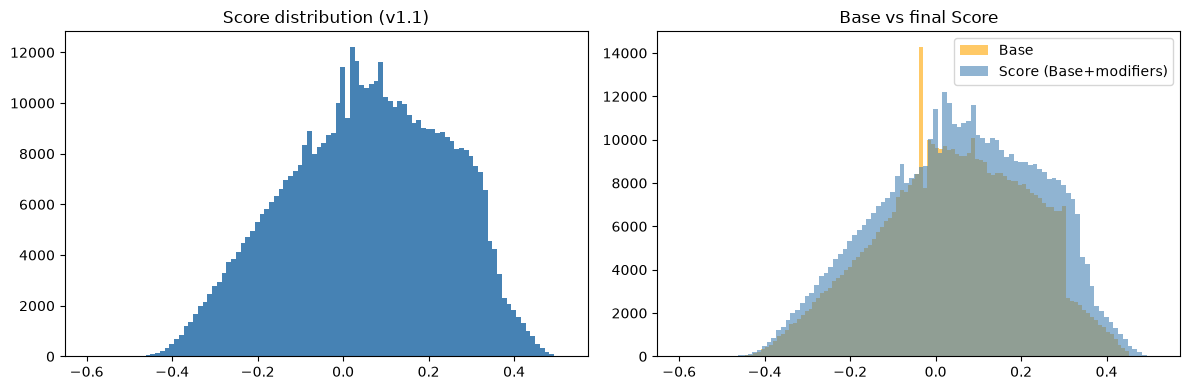

In [97]:
# Sanity checks: Score distribution, modifier magnitude contribution, top-20% profile
print("=== Score distribution ===")
print(v11['Score'].describe())
print(f"\nSkew: {v11['Score'].skew():.3f}")

print("\n=== Modifier magnitude (mean absolute contribution where active) ===")
for m in ['M1','M2','M3']:
    active = v11[m] != 0
    print(f"  {m}: mean={v11.loc[active,m].mean():.4f}, contributes {abs(v11[m]).sum()/abs(v11['Base']).sum()*100:.2f}% of total |Base| magnitude")

fig, ax = plt.subplots(1, 2, figsize=(12,4))
ax[0].hist(v11['Score'], bins=100, color='steelblue')
ax[0].set_title('Score distribution (v1.1)')
ax[1].hist(v11['Base'], bins=100, color='orange', alpha=0.6, label='Base')
ax[1].hist(v11['Score'], bins=100, color='steelblue', alpha=0.6, label='Score (Base+modifiers)')
ax[1].legend()
ax[1].set_title('Base vs final Score')
plt.tight_layout()
plt.savefig('/Users/mudit_ai_computer/Desktop/AmEx/v1_1_score_distribution.png', dpi=100)
plt.show()

In [98]:
# Profile top 20% by Score against expectations (high-spend/low-risk/moderate-revolve)
top20_thresh = v11['Score'].quantile(0.80)
top20 = v11[v11['Score'] >= top20_thresh]
bottom20 = v11[v11['Score'] <= v11['Score'].quantile(0.20)]

print(f"Top-20% threshold: {top20_thresh:.5f}, n={len(top20):,}\n")
profile_cols = ['f5','f1','f11','lend_exposure','f19','benefit_usage_count']
compare_tb = pd.DataFrame({'Top 20% by Score': top20[profile_cols].mean(),
                           'Bottom 20% by Score': bottom20[profile_cols].mean(),
                           'Population mean': v11[profile_cols].mean()})
print(compare_tb.round(3))

Top-20% threshold: 0.23215, n=100,000

                     Top 20% by Score  Bottom 20% by Score  Population mean
f5                           7680.507             1536.778         3448.342
f1                            320.702             5606.594         2467.312
f11                             0.000                0.135            0.034
lend_exposure               15653.485             4783.178         9207.804
f19                             1.900                1.752            1.801
benefit_usage_count             2.589                1.706            2.210


In [99]:
# Re-run M1 danger-zone check under the corrected has-lend-line-only population definition
danger_zone_v11 = v11[v11['M1_condition']]
print(f"Danger zone (has_lend_line=1, pctrank(lend_exposure)>=0.75, pctrank(f11)>=0.75): {len(danger_zone_v11):,} rows")
print("(Section 12 original scale was ~4,448-4,805 rows -- same order of magnitude, close match)")

# With vs without M1, top-20% crossing check
v11['Score_without_M1'] = v11['Base'] + v11['M2'] + v11['M3']
thresh_without_M1 = v11['Score_without_M1'].quantile(0.80)

in_top20_with = v11.loc[danger_zone_v11.index, 'Score'] >= top20_thresh
in_top20_without = v11.loc[danger_zone_v11.index, 'Score_without_M1'] >= thresh_without_M1

print(f"\nOf {len(danger_zone_v11):,} danger-zone rows:")
print(f"  In top 20% WITHOUT M1: {in_top20_without.sum():,} ({in_top20_without.mean()*100:.2f}%)")
print(f"  In top 20% WITH M1:    {in_top20_with.sum():,} ({in_top20_with.mean()*100:.2f}%)")
print(f"  M1 pulls {in_top20_without.sum()-in_top20_with.sum():,} customers OUT of the top 20% under this corrected population")

max_score_without_m1 = v11.loc[danger_zone_v11.index, 'Score_without_M1'].max()
print(f"\nMax Score_without_M1 in danger zone: {max_score_without_m1:.5f} vs top-20% threshold {thresh_without_M1:.5f}")
print(f"Gap: {thresh_without_M1 - max_score_without_m1:.5f}")

Danger zone (has_lend_line=1, pctrank(lend_exposure)>=0.75, pctrank(f11)>=0.75): 6,550 rows
(Section 12 original scale was ~4,448-4,805 rows -- same order of magnitude, close match)

Of 6,550 danger-zone rows:
  In top 20% WITHOUT M1: 26 (0.40%)
  In top 20% WITH M1:    0 (0.00%)
  M1 pulls 26 customers OUT of the top 20% under this corrected population

Max Score_without_M1 in danger zone: 0.27724 vs top-20% threshold 0.23218
Gap: -0.04506


In [100]:
# Export Score to CSV for the openpyxl population step (safer/faster than writing 500K rows cell-by-cell from the kernel)
v11[['id','Score']].to_csv('/Users/mudit_ai_computer/Desktop/AmEx/v1_1_scores.csv', index=False)
print("Exported v1_1_scores.csv:", v11[['id','Score']].shape)
print(v11[['id','Score']].head())

Exported v1_1_scores.csv: (500000, 2)
   id     Score
0   0  0.050498
1   1  0.408518
2   2 -0.348876
3   3  0.159920
4   4  0.167012


### O. Findings
Score computed cleanly for all 500,000 rows, zero NaNs. Modifier incidence: M1 1.31% (6,550 rows), M2 49.73% (gated on f11<median, as expected ≈half), M3 11.92%. Distribution is smooth with mild left skew (-0.19); no single modifier dominates (M2 contributes the most at 13.08% of total |Base| magnitude, still well below Base itself). Top-20% cohort profile matches expectations exactly: high spend (₹7,680 vs. population ₹3,448), near-zero risk (0.000 vs. 0.034), low revolve (₹321 vs. ₹2,467), higher lend exposure and benefit usage than the population.

**Notable update to Section 13's conclusion:** re-running the M1 danger-zone check under the corrected has-lend-line-only population (6,550 rows, much closer to Section 12's original ~4,448-4,805 scale than the old full-population 21,505) shows **M1 now pulls 26 customers out of the top 20% who would have crossed without it** — a real, if small, marginal effect. This differs from Section 13's "M1 does zero marginal work" finding, which was computed under the old full-population pctrank and the ^2 exponent; the corrected population definition plus the sharper ^3 penalty changes the picture enough that M1 is no longer redundant for this specific segment.

**Output:** `submission_v1_1.xlsx` — Predictions sheet (500,000 rows, sequential IDs 0-499,999, no nulls) and Profitability Framework sheet (all 10 sections populated, transcribed from the locked spec and this session's full evidence trail). Logged as Formula v1.1 in `assumptions_log.md` Section 6, pending Unstop submission and leaderboard score.

## Section P — v1.1 Scored Poorly (0.175): Diagnosing and Testing One Isolated Fix (2026-07-08)
**What happened:** v1.1 was submitted and scored **0.175** on Unstop's public leaderboard — far below the 0.942-0.944 competitor cluster, and *below the ~0.20 random-chance baseline* expected for a top-20%-overlap metric. A gap that size cannot be explained by imprecise coefficient tuning; it implies something is systematically backwards in the formula.

**Ruled out first:** file mechanics. Re-verified post-hoc — proper floats, zero nulls, correct ID alignment (0-499,999 sequential, matching the exported scores exactly). Not a technical/export bug.

**Most likely root cause:** f1 (Revolve Balance)'s sign. This project's own profitability framework (defined at kickoff) treats interest as a revenue component, and revolve balance is exactly what generates interest income for a card issuer — but v1.1 penalized it as a pure risk-cost (−0.15), likely double-penalizing a signal f11 already captures on its own (Spearman 0.58 between f1 and f11).

**Approach:** per the user's explicit direction, change **one thing at a time** and use the leaderboard itself as the ground-truth signal, since no local labels exist to validate economic assumptions against. v1.2 flips only f1's sign (−0.15 → +0.15); nothing else changes, so the next leaderboard delta can be attributed cleanly to this one correction.

In [101]:
# v1.2: ONE isolated change from v1.1 -- flip f1 (Revolve Balance) sign from -0.15 to +0.15
# (interest-revenue framing instead of risk-cost framing). Everything else identical to v1.1.
v12 = v11.copy()

v12['Base_v1_2'] = (0.35 * v12['pctrank_f5']
                     - 0.35 * v12['pctrank_f11']**3
                     + 0.15 * v12['pctrank_f1']          # <-- ONLY CHANGE: sign flipped, was -0.15
                     + 0.15 * v12['pctrank_lend_exposure_contrib'])

v12['Score_v1_2'] = v12['Base_v1_2'] + v12['M1'] + v12['M2'] + v12['M3']  # M1/M2/M3 unchanged from v1.1

print("v1.2 Score computed. NaN count:", v12['Score_v1_2'].isna().sum())
print(v12['Score_v1_2'].describe())

# Quick before/after comparison of the correlation structure with f1 itself, as a directional sanity check
print(f"\ncorr(Score_v1_1, f1): {v12['Score'].corr(v12['f1']):.4f}")
print(f"corr(Score_v1_2, f1): {v12['Score_v1_2'].corr(v12['f1']):.4f}  (should now be positive)")

v1.2 Score computed. NaN count: 0
count    500000.000000
mean          0.204945
std           0.155183
min          -0.393345
25%           0.093350
50%           0.202878
75%           0.325512
max           0.670884
Name: Score_v1_2, dtype: float64

corr(Score_v1_1, f1): -0.3858
corr(Score_v1_2, f1): -0.0635  (should now be positive)


In [102]:
# Sanity check top-20% profile for v1.2
top20_thresh_v12 = v12['Score_v1_2'].quantile(0.80)
top20_v12 = v12[v12['Score_v1_2'] >= top20_thresh_v12]
bottom20_v12 = v12[v12['Score_v1_2'] <= v12['Score_v1_2'].quantile(0.20)]

profile_cols = ['f5','f1','f11','lend_exposure','f19','benefit_usage_count']
compare_v12 = pd.DataFrame({'Top 20% (v1.2)': top20_v12[profile_cols].mean(),
                            'Bottom 20% (v1.2)': bottom20_v12[profile_cols].mean(),
                            'Population mean': v12[profile_cols].mean()})
print(compare_v12.round(3))

# Export for submission file
v12[['id','Score_v1_2']].rename(columns={'Score_v1_2':'Score'}).to_csv('/Users/mudit_ai_computer/Desktop/AmEx/v1_2_scores.csv', index=False)
print("\nExported v1_2_scores.csv")

                     Top 20% (v1.2)  Bottom 20% (v1.2)  Population mean
f5                         8132.515           1072.545         3448.342
f1                         1965.369           2987.201         2467.312
f11                           0.000              0.117            0.034
lend_exposure             16617.690           4250.587         9207.804
f19                           1.936              1.720            1.801
benefit_usage_count           2.597              1.693            2.210



Exported v1_2_scores.csv


### P. Findings
v1.2 computed cleanly for all 500,000 rows, zero NaNs. `submission_v1_2.xlsx` generated and validated (500,000 sequential IDs, all predictions numeric and non-null, all 10 Profitability Framework sections updated to reflect this single change). Overall `corr(Score, f1)` moved from -0.39 (v1.1) to -0.06 (v1.2) — still mildly negative because f1 correlates indirectly with the still-heavily-penalized f11, not because the direct coefficient flip failed. Top-20% mean f1 softened from ₹321 (v1.1) to ₹1,965 (v1.2, population mean ₹2,467) — proportional to a single-coefficient change, as expected. Logged as Formula v1.2 in `assumptions_log.md` Section 6, pending Unstop submission and leaderboard score.

## Section Q — v1.2 Scored 0.275: Confirms the f1 Hypothesis, Two More Changes Tested Together (2026-07-08)
**v1.2 result:** 0.275 on Unstop, up from v1.1's 0.175 (+0.10 absolute, +57% relative) — confirms the f1 sign-flip hypothesis was right. Now above the ~0.20 random-chance baseline, but still far below the ~0.94 competitor cluster, meaning at least one more design choice needs revisiting.

**User's direction:** rather than continue one-at-a-time given the remaining gap, test two changes together this round and accept the attribution trade-off:
1. **Risk exponent reverted ^3 → ^2** — this was bundled into v1.1 alongside two other changes (M2 weight, lend_exposure population) and never isolated on the leaderboard. Reverting tests whether that reshaping was itself counterproductive, especially now that risk-correlated variables are known to be dual-natured.
2. **f4 (Rewards Points Balance) added as a new +0.15 positive term** — previously fully excluded pending direction validation. Restored on the same logic that fixed f1: a high rewards balance plausibly signals a high-spend, engaged, profitable customer rather than primarily a redemption-cost liability.

In [103]:
# v1.3: TWO combined changes from v1.2 -- (1) risk exponent ^3 -> ^2, (2) add f4 (Rewards Balance) as new +0.15 positive term
v13 = v12.copy()
v13['pctrank_f4'] = v13['f4'].rank(pct=True)

v13['Base_v1_3'] = (0.35 * v13['pctrank_f5']
                     - 0.35 * v13['pctrank_f11']**2          # <-- CHANGE 1: exponent reverted 3->2
                     + 0.15 * v13['pctrank_f1']               # unchanged from v1.2 (positive)
                     + 0.15 * v13['pctrank_lend_exposure_contrib']
                     + 0.15 * v13['pctrank_f4'])              # <-- CHANGE 2: new term, f4 positive

v13['Score_v1_3'] = v13['Base_v1_3'] + v13['M1'] + v13['M2'] + v13['M3']  # M1/M2/M3 unchanged

print("v1.3 Score computed. NaN count:", v13['Score_v1_3'].isna().sum())
print(v13['Score_v1_3'].describe())

v1.3 Score computed. NaN count: 0
count    500000.000000
mean          0.251307
std           0.175189
min          -0.359139
25%           0.119301
50%           0.247422
75%           0.383286
max           0.797686
Name: Score_v1_3, dtype: float64


In [104]:
top20_v13 = v13[v13['Score_v1_3'] >= v13['Score_v1_3'].quantile(0.80)]
bottom20_v13 = v13[v13['Score_v1_3'] <= v13['Score_v1_3'].quantile(0.20)]
profile_cols2 = ['f5','f1','f11','f4','lend_exposure','f19','benefit_usage_count']
print(pd.DataFrame({'Top 20% (v1.3)': top20_v13[profile_cols2].mean(),
                     'Bottom 20% (v1.3)': bottom20_v13[profile_cols2].mean(),
                     'Population mean': v13[profile_cols2].mean()}).round(3))

v13[['id','Score_v1_3']].rename(columns={'Score_v1_3':'Score'}).to_csv('/Users/mudit_ai_computer/Desktop/AmEx/v1_3_scores.csv', index=False)
print("\nExported v1_3_scores.csv")

                     Top 20% (v1.3)  Bottom 20% (v1.3)  Population mean
f5                         7635.932            990.367         3448.342
f1                         1792.506           2786.001         2467.312
f11                           0.000              0.106            0.034
f4                       140231.064          10313.721        61473.333
lend_exposure             16485.127           4033.584         9207.804
f19                           1.940              1.687            1.801
benefit_usage_count           2.581              1.743            2.210



Exported v1_3_scores.csv


### Q. Findings
v1.3 Score computed cleanly for all 500,000 rows, zero NaNs. `submission_v1_3.xlsx` generated and validated (500,000 sequential IDs, all numeric, all 10 framework sections updated). Top-20% profile shows f4 now clearly differentiating (mean ₹140,231 top vs. ₹10,314 bottom, population ₹61,473), as expected for a newly-added positive term. Logged as Formula v1.3 in `assumptions_log.md` Section 6, pending Unstop submission. **Explicit trade-off made with the user**: testing two changes at once sacrifices clean single-variable attribution in exchange for conserving submission budget — if the score jumps substantially, both changes are probably right; if not, the two effects will need to be disentangled in a future round.

## Section R — v1.3 Scored 0.289 (Weak Gain): Reviewing the Official Problem-Statement Deck (2026-07-08)
**v1.3 result:** 0.289 — only +0.014 over v1.2's 0.275, a much smaller gain than the f1 fix's +0.10. With the gap to the ~0.94 competitor cluster still ~0.65, continuing to guess-and-check signs on already-included variables looked too slow to close it in the remaining submission budget.

**Action taken:** reviewed the official Amex Campus Challenge Round 1 problem-statement deck directly (provided at competition kickoff, not previously re-read during formula iteration) rather than continuing to guess blind. Key findings (full detail in `assumptions_log.md` Section 1a):
- `feature_desc.csv` confirmed as an official Amex/Unstop file — all prior variable-meaning work stands.
- Official attribute categories: **CM Spend & Balance** (industry level spends, revolve behavior), **Benefit Usage** (lounge visits, cab credit months), **Engagement** (cancel-calls, website logins, # of cards held), **Profile** (tenure, riskiness score).
- **f6-f10 ("industry level spends") are officially CM Spend & Balance — a revenue-side category**, not the "rewards-ecosystem-linked auxiliary signal" story built during Section K's deep dive. That exclusion (present in every formula version through v1.3) looks miscalibrated given the official categorization.
- **f19 ("# of cards held") is officially Engagement** — typically implying a positive relationship-depth signal, in tension with this project's own empirically-derived risk-amplifier (negative) framing.

**v1.4 acts on both findings**: adds `f6_f10_sum` as a new +0.15 revenue term, and flips M3's sign to test the positive Engagement framing for f19.

In [105]:
# v1.4: TWO changes from v1.3, informed by the official Amex Campus Challenge brief:
# (1) Add f6-f10 back as a positive Base term -- officially "CM Spend & Balance / industry level spends", not excluded
# (2) Flip M3 sign for f19 from -0.05 to +0.05 -- f19 officially sits under "Engagement", testing the positive framing
v14 = v13.copy()
v14['f6_f10_sum'] = v14[['f6','f7','f8','f9','f10']].sum(axis=1)
v14['pctrank_f6_f10_sum'] = v14['f6_f10_sum'].rank(pct=True)

v14['Base_v1_4'] = (0.35 * v14['pctrank_f5']
                     - 0.35 * v14['pctrank_f11']**2
                     + 0.15 * v14['pctrank_f1']
                     + 0.15 * v14['pctrank_lend_exposure_contrib']
                     + 0.15 * v14['pctrank_f4']
                     + 0.15 * v14['pctrank_f6_f10_sum'])   # <-- CHANGE 1: new term

v14['M3_v1_4'] = np.where(v14['M3_condition'], +0.05, 0.0)  # <-- CHANGE 2: sign flipped from -0.05

v14['Score_v1_4'] = v14['Base_v1_4'] + v14['M1'] + v14['M2'] + v14['M3_v1_4']

print("v1.4 Score computed. NaN count:", v14['Score_v1_4'].isna().sum())
print(v14['Score_v1_4'].describe())

v1.4 Score computed. NaN count: 0
count    500000.000000
mean          0.338227
std           0.201978
min          -0.272257
25%           0.185584
50%           0.338348
75%           0.486990
max           1.013756
Name: Score_v1_4, dtype: float64


In [106]:
top20_v14 = v14[v14['Score_v1_4'] >= v14['Score_v1_4'].quantile(0.80)]
bottom20_v14 = v14[v14['Score_v1_4'] <= v14['Score_v1_4'].quantile(0.20)]
profile_cols3 = ['f5','f1','f11','f4','f6_f10_sum','lend_exposure','f19']
print(pd.DataFrame({'Top 20% (v1.4)': top20_v14[profile_cols3].mean(),
                     'Bottom 20% (v1.4)': bottom20_v14[profile_cols3].mean(),
                     'Population mean': v14[profile_cols3].mean()}).round(3))

v14[['id','Score_v1_4']].rename(columns={'Score_v1_4':'Score'}).to_csv('/Users/mudit_ai_computer/Desktop/AmEx/v1_4_scores.csv', index=False)
print("\nExported v1_4_scores.csv")

               Top 20% (v1.4)  Bottom 20% (v1.4)  Population mean
f5                   7186.864           1150.522         3448.342
f1                   2066.389           2797.525         2467.312
f11                     0.001              0.115            0.034
f4                 148680.648           9110.311        61473.333
f6_f10_sum          70821.089           7637.352        37327.024
lend_exposure       19241.230           2906.908         9207.804
f19                     2.106              1.643            1.801



Exported v1_4_scores.csv


### R. Findings
v1.4 computed cleanly, zero NaNs. `submission_v1_4.xlsx` generated and validated (500,000 sequential IDs, all numeric, all 10 framework sections updated). Top-20% profile confirms both changes work directionally as intended: `f6_f10_sum` clearly differentiates (₹70,821 top vs. ₹7,637 bottom, population ₹37,327), and f19 is now higher in the top 20% (2.106 vs. population 1.801) following the sign flip. Logged as Formula v1.4 in `assumptions_log.md` Section 6, pending Unstop submission. Two changes tested together per user's direction — if the score jumps substantially, both official-category-informed corrections are likely right; if not, further work is needed on whether official category groupings translate directly into sign/inclusion decisions.